# Corpus pequeños y caminos alternativos

## Usar modelos pre-entrenados + adaptarlos (RECOMENDADO) 

## 1- Paper 1:  2020 - Analysing Lexical Semantic Change with Contextualised Word Representations https://aclanthology.org/2020.acl-main.365.pdf
    * Código: https://github.com/glnmario/cwr4lsc 
    

En este trabajo, se propone un enfoque basado en el uso para el cambio semántico léxico, donde el contexto oracional modula el significado léxico sobre la marcha (Ludlow, 2014). 

Presenta un método que:
* (1) aprovecha un modelo neuronal del lenguaje preentrenado (BERT; Devlin et al., 2019) para obtener representaciones contextualizadas para cada ocurrencia de una palabra de interés
* (2) agrupa estas representaciones en tipos de uso
* (3) mide el cambio a lo largo del tiempo.

Se considera las siguientes contribuciones:
* Presentan un enfoque no supervisado para el cambio semántico léxico que utiliza representaciones contextualizadas de palabras de última generación.
* Propone varias métricas para medir el cambio semántico con este tipo de representación.
* Crean un nuevo conjunto de datos de evaluación de la simulación humana.
* Demuesta que tanto las representaciones del modelo como los cambios semánticos detectados se correlacionan positivamente con las intuiciones humanas.

Mediante un análisis cualitativo exhaustivo, demuestra que el enfoque propuesto captura fenómenos sincrónicos como los sentidos de las palabras y las funciones sintácticas, el uso literal y metafórico, así como los procesos lingüísticos diacrónicos relacionados con la delimitación y la ampliación del significado a lo largo del tiempo. En general, el estudio demuestra el potencial del uso de representaciones contextualizadas de palabras para modelar y analizar el cambio semántico léxico y abre la puerta a futuros trabajos en esta dirección.


### Modelo de lenguaje

* https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased
* https://github.com/dccuchile/beto
* https://www.youtube.com/watch?v=
* https://bibliotecadigital.exactas.uba.ar/download/tesis/tesis_n7305_Perez.pdf

In [93]:
# --- 1. Librería ---
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import pickle
import sys
import re


from transformers import AutoTokenizer, AutoModel
import torch
from collections import defaultdict
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr

#from collections import Counter
import matplotlib.pyplot as plt
from sklearn import preprocessing
#from sklearn.metrics.pairwise import cosine_similarity

In [94]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
IMAG_DIR = BASE_DIR+'imagenes/'
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)
pd.set_option('display.max_colwidth', None)

In [95]:
RESULTADOS_DIR

'C:/Users/Usuario/iamas_iniciativasleg_salud/src/data/'

In [96]:
BASE_DIR

'C:/Users/Usuario/iamas_iniciativasleg_salud/'

### Cargar Modelo entrenado BETO ---


In [5]:
# --- 1. Cargar BETO ---
# BETO cased (más recomendado para español legislativo)
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()  # Poner modelo en modo evaluación


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(31002, 768, padding_idx=1)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

###  Configuración inicial 

In [97]:
# --- 1. Configuración inicial --- Palabras de la iteración base
periodosComp_lista = [2009, 2014, 2019]  # Períodos quinquenales
long_contexto2 = 5 # Longitud de contexto (palabras alrededor de la palabra objetivo) se tuvo en cuenta lo de word2vec
longitud_secuencia = 128 # Es el límite máximo de tokens que BERT puede procesar en una sola pasada.
frec_minima = 5 # ocurrencia en al menos algunos de los períodos a comparar


### 1. Preparación del Corpus por Período

In [98]:
# Abrir
print("Cargando datos...")
with open(RESULTADOS_DIR + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)
basetexto_df.info()

Cargando datos...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33097 entries, 0 to 33096
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Proyecto.ID             33097 non-null  category
 1   Título                  33097 non-null  category
 2   Título procesado        33097 non-null  object  
 3   Título normalizado      33097 non-null  object  
 4   Cant_token              33097 non-null  int64   
 5   Cant_token_procesados   33097 non-null  int64   
 6   Cant_token_normalizado  33097 non-null  int64   
 7   Proyecto_SALUD          33097 non-null  float64 
 8   Resultado               33097 non-null  category
 9   Periodo                 33097 non-null  float64 
 10  Año                     33097 non-null  int32   
 11  Tokens                  33097 non-null  object  
dtypes: category(3), float64(2), int32(1), int64(3), object(3)
memory usage: 3.9+ MB


In [99]:
# Seleccionando IL de Salud
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)
basetexto_df['Periodo_5anios'] = 2009 # el período parlamentario  127 inicia el 01/03/2009
basetexto_df.loc[(basetexto_df['Periodo']>=132) & (basetexto_df['Periodo']<137), 'Periodo_5anios'] =  2014 # 132 inicia el 01/03/2014
basetexto_df.loc[(basetexto_df['Periodo']>=137), 'Periodo_5anios'] =  2019 # 137 inicia el 01/03/2019 
corpusQuinquenal_df = basetexto_df[['Proyecto.ID', 'Título', 'Título procesado', 'Título normalizado','Periodo_5anios']].copy()
corpusQuinquenal_df['Periodo_5anios'].value_counts() # frecuencia absoluto
display(corpusQuinquenal_df.head(2))

Conj. de datos de proyecto_SALUD con Nan en Período: (2848, 12)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 12)


,Proyecto.ID,Título,Título procesado,Título normalizado,Periodo_5anios
6,HCDN272685,INCLUYASE EN EL CALENDARIO NACIONAL DE VACUNACION CON CARACTER OBLIGATORIO Y GRATUITO LA VACUNA CONTRA EL VIRUS DEL DENGUE. MODIFICACION DE LA LEY 27491.,incluyase en el calendario nacional de vacunacion con caracter obligatorio y gratuito la vacuna contra el virus del dengue modificacion de la ley numero,incluyar calendario nacional vacunacion caracter obligatorio gratuito vacuna virus dengue,2019
12,HCDN272690,INCLUIR EN EL CALENDARIO NACIONAL DE VACUNACION CON CARACTER OBLIGATORIO Y GRATUITO LA VACUNA CONTRA EL VIRUS DEL DENGUE.,incluir en el calendario nacional de vacunacion con caracter obligatorio y gratuito la vacuna contra el virus del dengue,incluir calendario nacional vacunacion caracter obligatorio gratuito vacuna virus dengue,2019


### 2. Listado de palabras por período a comparar
Se consideran únicamente aquellas con al menos 5 ocurrencias en alguno de los dos períodos de cinco años.


In [100]:
def pares_primer_paso(lista_items):
    return [(lista_items[i],lista_items[i+1]) for i in range(len(lista_items)-1)]

In [101]:
pares_periodos = pares_primer_paso(periodosComp_lista) # lista de tuplas en base a los tres períodos a comparar
pares_periodos

[(2009, 2014), (2014, 2019)]

In [102]:
def analizar_intersecciones_con_frecuencia(pares_periodos, frecuencia_minima=5):
    """
    Analiza intersecciones entre pares de períodos con filtro de frecuencia
    """
    resultados_completos = {}
    
    for par in pares_periodos:
        # Cargar y preparar datos
        frecPer1 = pd.read_csv(f"{RESULTADOS_DIR}/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_{par[0]}.csv")
        frecPer2 = pd.read_csv(f"{RESULTADOS_DIR}/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_{par[1]}.csv")
        
        frecPer1.columns = ['palabra', 'frec1', 'porc1']
        frecPer2.columns = ['palabra', 'frec2', 'porc2']
        
        # Aplicar filtro de frecuencia
        #frecPer1_filtrado = frecPer1[frecPer1['frec1'] >= frecuencia_minima]
        #frecPer2_filtrado = frecPer2[frecPer2['frec2'] >= frecuencia_minima]

        # Encontrar intersección
        #palabras_comunes = set(frecPer1_filtrado['palabra']).intersection(set(frecPer2_filtrado['palabra']))
        palabras_comunes = set(frecPer1['palabra']).intersection(set(frecPer1['palabra']))
        
        # Crear DataFrame combinado
        #df_combinado = frecPer1_filtrado[frecPer1_filtrado['palabra'].isin(palabras_comunes)].merge(
        #    frecPer2_filtrado[['palabra', 'frec2', 'porc2']], 
        #    on='palabra'
        #)
        df_combinado = frecPer1[frecPer1['palabra'].isin(palabras_comunes)].merge(
            frecPer2[['palabra', 'frec2', 'porc2']], 
            on='palabra'
        )
        
        # Calcular métricas adicionales
        df_combinado['max_freq_of_any_decade'] = df_combinado[['frec1', 'frec2']].max(axis=1)
        df_combinado['min_freq_of_any_decade'] = df_combinado[['frec1', 'frec2']].min(axis=1)
        df_combinado = df_combinado.loc[df_combinado.max_freq_of_any_decade>= frecuencia_minima]

        df_combinado['freq_ratio'] = df_combinado['frec1'] / df_combinado['frec2']
        
        # Guardar resultados
        archivo_salida = f"{RESULTADOS_DIR}interseccion_con_frec_min5_{par[0]}_{par[1]}.csv"
        df_combinado.to_csv(archivo_salida, index=False)


        # Almacenar resultados
        resultados_completos[par] = { #f"{par[0]}_{par[1]}"
            'dataframe': df_combinado,
            'palabras_comunes': list(df_combinado['palabra'].values),
            'total_palabras': len(df_combinado['palabra'].values),
            'archivo_guardado': archivo_salida
        }
        
        print(f"Intersección {par[0]}-{par[1]}: {len(df_combinado['palabra'].values)} palabras (frecuencia >= {frecuencia_minima})")
        print(f"Archivo guardado: {archivo_salida}")
    
    return resultados_completos



In [103]:
# Ejecutar análisis de lista de palabras comunes por períodos
resultados = analizar_intersecciones_con_frecuencia(pares_periodos, frec_minima)
resultados.keys()

Intersección 2009-2014: 447 palabras (frecuencia >= 5)
Archivo guardado: C:/Users/Usuario/iamas_iniciativasleg_salud/src/data/interseccion_con_frec_min5_2009_2014.csv
Intersección 2014-2019: 486 palabras (frecuencia >= 5)
Archivo guardado: C:/Users/Usuario/iamas_iniciativasleg_salud/src/data/interseccion_con_frec_min5_2014_2019.csv


dict_keys([(2009, 2014), (2014, 2019)])

In [104]:
resultados[(2009, 2014)]['dataframe'].describe()

,frec1,porc1,frec2,porc2,max_freq_of_any_decade,min_freq_of_any_decade,freq_ratio
count,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000
mean,13.069351,0.001660,15.720358,0.001615,17.796421,10.993289,1.195481
std,20.233106,0.002570,25.632013,0.002634,26.043534,19.194834,1.312053
min,1.000000,0.000127,1.000000,0.000103,5.000000,1.000000,0.083333
25%,4.000000,0.000508,5.000000,0.000514,6.500000,3.000000,0.464103
50%,7.000000,0.000889,8.000000,0.000822,9.000000,5.000000,0.750000
75%,13.000000,0.001651,15.000000,0.001541,17.000000,10.000000,1.333333
max,208.000000,0.026423,268.000000,0.027541,268.000000,208.000000,9.000000


In [105]:
resultados[(2014, 2019)]['dataframe'].describe()

,frec1,porc1,frec2,porc2,max_freq_of_any_decade,min_freq_of_any_decade,freq_ratio
count,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000,486.000000
mean,14.676955,0.001508,15.397119,0.001509,18.144033,11.930041,1.567197
std,24.834806,0.002552,28.686300,0.002812,29.248312,23.772271,1.867456
min,1.000000,0.000103,1.000000,0.000098,5.000000,1.000000,0.052632
25%,5.000000,0.000514,5.000000,0.000490,6.000000,3.000000,0.588904
50%,8.000000,0.000822,7.000000,0.000686,9.000000,5.000000,1.000000
75%,15.000000,0.001541,14.000000,0.001372,18.000000,10.000000,1.666667
max,268.000000,0.027541,360.000000,0.035284,360.000000,268.000000,14.000000


In [106]:
palabras_comunes_all = set(resultados[(2009, 2014)]['palabras_comunes']).intersection(set(resultados[(2014, 2019)]['palabras_comunes']))
print("Palabras comunes en todos los pares de períodos:", len(palabras_comunes_all))


Palabras comunes en todos los pares de períodos: 377


### 3. Enfoque por contextualización


#### 3.1 Generar las "Usage Representations" (Representaciones de Uso)

In [107]:
# --- 3. Función para extraer representaciones contextualizadas ---
def obtener_embedding_contextualizado_mejorado(text, target_word, strategy="all_sum"):
    """
    Versión mejorada con diferentes estrategias de combinación de capas
    """
    try:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
        
        # Encontrar TODOS los tokens que corresponden a la palabra objetivo
        target_indices = []
        for i, token in enumerate(tokens):
            # Manejar tokenización de BERT (##palabra)
            clean_token = token.replace('##', '').lower()
            if target_word.lower() in clean_token:
                target_indices.append(i)
        
        if not target_indices:
            return None
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        
        all_hidden_states = outputs.hidden_states  # 13 capas
        
        # Estrategias diferentes
        if strategy == "last4_mean":
            # Promedio de últimas 4 capas (como intentaba el código original)
            last_four_layers = all_hidden_states[-4:]
            layers_tensor = torch.stack(last_four_layers)  # (4, 1, seq_len, 768)
            target_reps = layers_tensor[:, 0, target_indices[0], :]
            final_rep = target_reps.mean(dim=0)
            
        elif strategy == "all_sum":
            # Suma de todas las capas (como el primer código)
            all_layers = torch.stack(all_hidden_states[1:])  # (12, 1, seq_len, 768)
            target_rep = all_layers[:, 0, target_indices[0], :]  # (12, 768)
            final_rep = target_rep.sum(dim=0)
            
        elif strategy == "last_layer":
            # Solo última capa
            final_rep = all_hidden_states[-1][0, target_indices[0], :]
        
        return final_rep.numpy()
        
    except Exception as e:
        print(f"Error procesando {target_word} en texto: {e}")
        return None

def obtener_embedding_contextualizado(text, target_word):
    """
    Obtiene la representación contextualizada de una palabra objetivo en un texto
    usando el modelo BETO.
    
    Args:
        text (str): Texto completo que contiene la palabra objetivo
        target_word (str): Palabra para la cual obtener la representación
        
    Returns:
        numpy.array: Vector de representación contextualizada o None si no se encuentra
    """
    try:
        # Tokenizar el texto
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512) 
        # Convierte el texto en tensores PyTorch  que el modelo puede procesar tal que trunca automáticamente el texto si excede max_length, Textos más largos se truncarán a 512 tokens (512 longitud máxima)
        
        # Obtener la posición del token objetivo
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
        target_indices = [i for i, token in enumerate(tokens) 
                         if target_word in token.lower()]
        
        if not target_indices:
            return None
        
        # Obtener representaciones del modelo
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            #outputs = model(**inputs)
        
        # Usar la última capa (capas [-4:] como en el paper original)
        last_four_layers = outputs.last_hidden_state[-4:]
        target_representation = last_four_layers[:, target_indices[0], :].mean(dim=0)
        
        return target_representation.numpy()
        
    except Exception as e:
        print(f"Error procesando texto: {e}")
        return None



def create_default_value():
    return defaultdict(list)

# --- 4. Función para procesar el corpus por período ---
def generar_corpus_por_periodo(df, palabras, periodos, long_sec=2):
    """
    Procesa el corpus y extrae representaciones para cada palabra objetivo por período
    
    Args:
        df (DataFrame): DataFrame con columnas 'Título normalizado' y 'Periodo_5anios'
        palabras (list): Lista de palabras objetivo
        periodos (list): Lista de períodos a analizar
        long_sec (int): Ventana de tokens alrededor de la palabra objetivo
        
    Returns:
        dict: Diccionario con Usage Matrices por palabra y período
    """
    usage_matrices = defaultdict(create_default_value)
    
    for periodo in periodos:
        print(f"Procesando período: {periodo}")
        
        # Filtrar datos por período
        period_data = df[df['Periodo_5anios'] == periodo]
        
        for _, row in period_data.iterrows():
            title = row['Título normalizado']
            
            for palabra in palabras:
                # Buscar la palabra objetivo en el título
                if re.search(r'\b' + re.escape(palabra) + r'\b', title, re.IGNORECASE):
                    
                    # Obtener contexto alrededor de la palabra objetivo
                    words = title.split()
                    try:
                        target_idx = words.index(palabra)
                        start_idx = max(0, target_idx - long_sec)
                        end_idx = min(len(words), target_idx + long_sec + 1)
                        context = ' '.join(words[start_idx:end_idx])
                    except ValueError:
                        context = title
                    
                    # Obtener representación contextualizada
                    embedding = obtener_embedding_contextualizado_mejorado(context, palabra) # obtener_embedding_contextualizado(context, palabra)
                    
                    if embedding is not None:
                        usage_matrices[palabra][periodo].append({
                            'embedding': embedding,
                            'contexto': context,
                            'proyecto_id': row['Proyecto.ID']
                        })
    
    return usage_matrices

Chequeando código: Construcción de vectores 

In [17]:
#  Check embeding
text = "Hola mundo"
inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
print(inputs['input_ids'])  # Ver los tokens numéricos
print(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0]))  # Ver tokens como texto
# CLS Siempre en primera posición

tensor([[   4, 1894, 1863,    5]])
['[CLS]', 'Hola', 'mundo', '[SEP]']


In [18]:
# Contexto de código
periodo = 2009        
long_contexto = 2 # Longitud de contexto (palabras alrededor de la palabra objetivo) se tuvo en cuenta lo de word2vec

# sequence_length: longitud deseada para la secuencia de salida
palabras = ['transcurso']
print(f"Procesando período: {periodo}")
# Filtrar datos por período
period_data = corpusQuinquenal_df[corpusQuinquenal_df['Periodo_5anios'] == periodo]
# -2 ya que los tokens [CLS] y [SEP] se agregarán más adelante; /2 ya que es una ventana unilateral
#windows_size = 
for _, row in period_data.iterrows():
    title = row['Título normalizado']
    for palabra in palabras:
    # Buscar la palabra objetivo en el título
        if re.search(r'\b' + re.escape(palabra) + r'\b', title, re.IGNORECASE):
                
            print('\n'+title)
            # Obtener contexto alrededor de la palabra objetivo
            words = title.split()
            try:
                target_idx = words.index(palabra)
                start_idx = max(0, target_idx - long_contexto)
                end_idx = min(len(words), target_idx + long_contexto + 1)
                context = ' '.join(words[start_idx:end_idx])
                print(target_idx,start_idx,end_idx,context)
            except ValueError:
                context = title
                    
             
# Obtener representación contextualizada
# embedding = obtener_embedding_contextualizado_mejorado(context, palabra) # obtener_embedding_contextualizado(context, palabra)
    

Procesando período: 2009

pediculosis implementar campana lucha transcurso ano lectivo 
4 2 7 campana lucha transcurso ano lectivo

pediculosis implementar campana lucha transcurso ano lectivo 
4 2 7 campana lucha transcurso ano lectivo

pediculosis implementar campana lucha transcurso ano lectivo
4 2 7 campana lucha transcurso ano lectivo


In [19]:
# Viendo otro código
title = 'pediculosis implementar campana lucha transcurso ano lectivo' 
words = title.split()
target_position = words.index(palabra)
print(words)
print('target_position',target_position)
sequence_length = 5
# -2 as [CLS] and [SEP] tokens will be added later; /2 as it's a one-sided window
window_size = sequence_length #int((sequence_length - 2) / 2)
print('window_size',window_size)
context_start = max([0, target_position - window_size])
padding_offset = max([0, window_size - target_position])
padding_offset += max([0, target_position + window_size - len(words)])
context_ids = words[context_start:target_position + window_size]
context_ids += padding_offset * [0]

new_target_position = target_position - context_start
print(new_target_position)
print(context_ids)


['pediculosis', 'implementar', 'campana', 'lucha', 'transcurso', 'ano', 'lectivo']
target_position 4
window_size 5
4
['pediculosis', 'implementar', 'campana', 'lucha', 'transcurso', 'ano', 'lectivo', 0, 0, 0]


In [20]:
# Controlando embedding
title = 'pediculosis implementar campana lucha transcurso ano lectivo' 
inputs = tokenizer(title, return_tensors="pt", truncation=True, max_length=512)
print(inputs)
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
target_word = 'transcurso'
# Encontrar TODOS los tokens que corresponden a la palabra objetivo
target_indices = []
for i, token in enumerate(tokens):
    # Manejar tokenización de BERT (##palabra)
    clean_token = token.replace('##', '').lower()
    print(clean_token)
    if target_word.lower() in clean_token:
        target_indices.append(i)
print("target_indices",target_indices)
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)
    all_hidden_states = outputs.hidden_states  # 13 capas forma de acceder a hidden_states
    print(len(all_hidden_states))
    print(len(all_hidden_states[1:]))
    # Suma de todas las capas (como el primer código)
    all_layers = torch.stack(all_hidden_states[1:])  # (12, 1, seq_len, 768) # seq_len =  Selección de capas excluye la 0
    print(all_layers.shape)
    target_rep = all_layers[:, 0, target_indices[0], :]  # (12, 768)
    final_rep = target_rep.sum(dim=0)
    print(final_rep.numpy())


{'input_ids': tensor([[    4, 15621, 19646, 23944, 21735,  3816, 15511,  4501,  4771,  1436,
             5]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
[cls]
pedi
culosis
implementar
campana
lucha
transcurso
ano
lec
tivo
[sep]
target_indices [6]
13
12
torch.Size([12, 1, 11, 768])
[ 1.36369693e+00 -2.60727048e+00  8.03208065e+00  6.80015755e+00
  2.12610364e+00  2.45652795e+00 -2.94326234e+00 -3.54399204e+00
 -4.43891335e+00  2.01793694e+00  2.27001238e+00  3.05515981e+00
 -3.44017982e+00 -3.63673449e-01 -1.19198763e+00  3.35154676e+00
  1.75196815e+00 -4.32976627e+00 -2.37547064e+00  8.62920761e+00
  1.04231768e+01  3.66505694e+00  4.08482838e+00  6.79935122e+00
  2.98739982e+00 -6.67291451e+00 -8.91513526e-01  3.93182111e+00
 -2.08600903e+00  1.29089928e+00 -6.13289261e+00  8.88135314e-01
 -6.92734957e+00  8.97702980e+00 -5.61951208e+00 -2.96097660e+00
  7.83450317e+00  1.25270548e+01  5.49782658e+00

#### 3.2 Agrupar Usos en "Usage Types" (Tipos de Uso)
* Aplicar un algoritmo de clustering (como K-Means) a esta matriz para agrupar usos similares.
* Cada cluster resultante es un "usage type": un grupo de usos que comparten un significado similar. Por ejemplo, para "dispositivo", un cluster podría agrupar usos relacionados con "dispositivos médicos" y otro con "dispositivos electrónicos".
* Determinar el número de clusters (K) automáticamente usando el silhouette score (como hacen en el paper), probando entre K=2 y K=10 clusters.


In [26]:
# --- 5. Función para clustering y obtención de Usage Types ---


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

def obtener_distrib_cluster(labels, k):
    """Calcula la distribución de clusters normalizada"""

    distribution = np.zeros(k)
    for label in labels:
        distribution[label] += 1
    return distribution / len(labels)

def calcular_distribucion_periodo(target_word,indices,all_labels,best_k):
    # Calcular distribuciones por período
    distr_periodo = {}
    if indices:
        # Obtener labels solo para este período
        period_labels = all_labels[indices]
        # Calcular distribución de clusters para este período
        distribution = obtener_distrib_cluster(period_labels, best_k)
        distr_periodo = {
                        'distribucion': distribution,
                        'ocurrencia': len(indices),
                        'indices': indices  # Para referencia
                    }
    return distr_periodo


def create_default_value2():
    return defaultdict(dict)

def obtener_mejor_cluster(matrices, k_rango=range(2, 20)):
    """
    Agrupa las representaciones en Usage Types usando K-Means para cada palabra
    (no por período). Luego calcula distribuciones por período.
    
    Args:
        matrices (dict): Diccionario con Usage Matrices
        k_rangO (range): Rango de valores de k a probar
        
    Returns:
        dict: Resultados del clustering por palabra con distribuciones por período
    """
    clustering_results = defaultdict(create_default_value2)
    
    for target_word, period_data in matrices.items():
        print(f"Procesando clustering para palabra: {target_word}")
        
        # Recolectar TODOS los embeddings de la palabra (todos los períodos)
        all_embeddings = []
        all_usages = []
        period_indices = []  # Para trackear a qué período pertenece cada embedding
        decade_to_indices = defaultdict(list)  # Mapeo década -> índices
        
        for decade, usages in period_data.items():
            for i, usage in enumerate(usages):
                all_embeddings.append(usage['embedding'])
                all_usages.append(usage)
                global_idx = len(all_embeddings) - 1
                period_indices.append(decade)
                decade_to_indices[decade].append(global_idx)
        
        #if len(all_embeddings) < 10:  # Mínimo de usos para clustering
        #    print(f"  Saltando '{target_word}': muy pocos usos ({len(all_embeddings)})")
        #    continue
        
        # Convertir a array numpy
        all_embeddings = np.array(all_embeddings)
        #embeddings_scaled = scaler.fit_transform(all_embeddings)
    
        # estandarizar la matriz de uso eliminando la media y escalando a la varianza unitaria
        Uw = preprocessing.StandardScaler().fit_transform(all_embeddings)
    
        
        # Encontrar k óptimo usando silhouette score (para TODOS los usos de la palabra)
        best_k = 2
        best_score = -1
        best_kmeans = None
        
        for k in k_rango:
            if k >= len(Uw):
                continue
            
            #print('k',k)    
            kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
            labels = kmeans.fit_predict(Uw) #(embeddings_scaled) 
            
            #print(len(set(labels)))
            if len(set(labels)) > 1:  # Silhouette requiere al menos 2 clusters
                score = silhouette_score(Uw, labels) #(embeddings_scaled, labels) 
                if score > best_score:
                    best_score = score
                    best_k = k
                    best_kmeans = kmeans
        
        # Si no se encontró k óptimo, usar k=2 por defecto
        #if best_kmeans is None:
        #    best_k = 2
        #    best_kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
        #    best_kmeans.fit(all_embeddings)
        #    best_score = silhouette_score(all_embeddings, best_kmeans.labels_)
        
        if best_kmeans is not None:
            # Obtener labels para todos los usos
            all_labels = best_kmeans.labels_
            
            # Almacenar resultados del clustering global para la palabra
            clustering_results[target_word]['global'] = {
                'embeddings': all_embeddings,
                'embeddings_scaled': Uw, # embeddings_scaled
                'etiquetas_k': all_labels,
                'centroides': best_kmeans.cluster_centers_,
                'usos': all_usages,
                'k': best_k,
                'silhouette_score': best_score,
                'indice_periodo': period_indices,  # Para trackear períodos
                'periodo_con_indices':decade_to_indices # Para obtener indice x periodo
            }
    
    
            # Calcular distribuciones por período
            for decade in period_data.keys():
                if decade in decade_to_indices:
                    clustering_results[target_word][decade] = calcular_distribucion_periodo(target_word,decade_to_indices[decade],all_labels,best_k)

    
    return clustering_results


#### 3.3. Analizar el Cambio Semántico entre Períodos
Comparar los "usage types" entre períodos. El paper propone tres métricas, en donde Jensen-Shannon Divergence y Average Pairwise Distance (APD) obtienen mejores resultados:

* Jensen-Shannon Divergence (JSD): Mide cómo cambia la distribución de los "usage types" de un período a otro.

Por ejemplo: Si en P1 (2009-2014) el 90% de los usos de "dispositivo" son médicos y el 10% electrónicos, pero en P2 (2014-2019) la distribución es 50%-50%, la JSD capturará este cambio significativo en el significado predominante.

* Average Pairwise Distance (APD): Mide la distancia promedio entre todos los usos de un período y todos los usos de otro.

Es útil si no quieres depender de la calidad del clustering.


* Calcular JSD o APD entre Pares Consecutivos: JSD(P1, P2), JSD(P2, P3)

* Palabras con alta JSD o APD entre períodos son candidatas a haber sufrido cambio semántico.

In [22]:
# --- 6. Métricas de cambio semántico (ACTUALIZADO) ---  

# --- FUNCIÓN APD MEJORADA ---
from scipy.spatial.distance import cdist

def calculate_apd_improved(embeddings1, embeddings2, metrics=('cosine', 'canberra', 'euclidean')):
    """
    Calcula Average Pairwise Distance entre dos conjuntos de embeddings
    usando múltiples métricas, adaptado de la función original
    
    Args:
        embeddings1: Array de embeddings del período 1
        embeddings2: Array de embeddings del período 2
        metrics: Lista de métricas a calcular
        
    Returns:
        dict: Diccionario con APD para cada métrica
    """
    distances = {}
    
    for metric in metrics:
        try:
            # Calcular matriz de distancias
            dist_matrix = cdist(embeddings1, embeddings2, metric=metric)
            # Calcular promedio de todas las distancias
            avg_distance = np.mean(dist_matrix)
            distances[metric] = avg_distance
        except Exception as e:
            print(f"Error calculando métrica {metric}: {e}")
            distances[metric] = np.nan
    
    return distances

#Coseno	Dirección	0-1	0 (igual dirección)
#Euclidiana	Distancia absoluta	0-∞	0 (iguales)
#Canberra	Distancia relativa	0-∞	0 (iguales)
def avg_pairwise_distance_timeseries(usages_data, metrics=('cosine', 'canberra', 'euclidean'), interval_labels=None):
    """
    Adaptación de la función original para calcular APD entre períodos
    :param usages_data: Diccionario con embeddings organizados por período
    :param metrics: Lista de métricas de distancia
    :param interval_labels: Períodos específicos a considerar
    :return: Diccionario con distancias APD entre períodos contiguos
    """
    # Organizar embeddings por período
    by_time = {}
    for decade, data in usages_data.items():
        if interval_labels and decade not in interval_labels:
            continue
        if 'embeddings' in data and len(data['embeddings']) > 0:
            by_time[decade] = data['embeddings']
    
    if not by_time:
        return {}
    
    # Ordenar períodos cronológicamente
    sorted_decades = sorted(by_time.keys())
    distances = {metric: [] for metric in metrics}
    decade_pairs = []
    
    # Calcular distancias entre períodos contiguos
    for i in range(len(sorted_decades) - 1):
        t1 = sorted_decades[i]
        t2 = sorted_decades[i + 1]
        decade_pairs.append(f"{t1}-{t2}")
        
        embeddings1 = by_time[t1]
        embeddings2 = by_time[t2]
        
        for metric in metrics:
            try:
                dist_matrix = cdist(embeddings1, embeddings2, metric=metric)
                avg_distance = np.mean(dist_matrix) # np.mean(cdist(A, B)) = 1/(len(A)*len(B)) * ∑∑ d(a_i, b_j)
                distances[metric].append(avg_distance)
            except Exception as e:
                print(f"Error calculando {metric} entre {t1} y {t2}: {e}")
                distances[metric].append(np.nan)
    
    # Convertir a arrays numpy
    distances = {metric: np.array(dists) for metric, dists in distances.items()}
    
    return distances, decade_pairs



def calcular_apd(embeddings1, embeddings2):
    """Calcula Average Pairwise Distance entre dos conjuntos de embeddings"""
    distances = []
    for emb1 in embeddings1:
        for emb2 in embeddings2:
            # Distancia coseno
            distance = 1 - np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
            distances.append(distance)
    return np.mean(distances) if distances else 0

def calcular_metricas_cambioSemantico(clustering, periodos):
    """
    Calcula métricas de cambio semántico entre períodos basado en las distribuciones
    
    Args:
        clustering (dict): Resultados del clustering con distribuciones por período
        periodos (list): Lista de períodos ordenados
        
    Returns:
        dict: Métricas de cambio por palabra y par de períodos
    """
    change_metrics = {}
    
    for target_word, data in clustering.items():
        if 'global' not in data:
            continue
            
        change_metrics[target_word] = {}
        k = data['global']['k']

        # Preparar datos para APD mejorado
        temp_data = {}
        for periodo in periodos:
            if periodo in data:
                temp_data[periodo] = {
                    'embeddings': data['global']['embeddings'][data[periodo]['indices']],
                    'ocurrencia': data[periodo]['ocurrencia']
                }
        # Calcular APD mejorado entre períodos contiguos
        apd_results, decade_pairs = avg_pairwise_distance_timeseries(
            temp_data, 
            metrics=('cosine', 'canberra', 'euclidean'),
            interval_labels= periodos
        )
        
        
        # Calcular métricas para cada par de períodos consecutivos
        for i in range(len(periodos) - 1):
            period1, period2 = periodos[i], periodos[i + 1]
                      
            if period1 in data and period2 in data:
                # Obtener distribuciones de clusters para cada período
                dist1 = data[period1]['distribucion']
                dist2 = data[period2]['distribucion']
                
                # Calcular Jensen-Shannon Divergence
                js_divergence = jensenshannon(dist1, dist2)**2
                
                # Calcular Average Pairwise Distance (APD) entre embeddings de los períodos
                # Obtener embeddings de cada período
                #period1_indices = data[period1]['indices']
                #period2_indices = data[period2]['indices']
                
                #embeddings1 = data['global']['embeddings'][period1_indices]
                #embeddings2 = data['global']['embeddings'][period2_indices]
                
                #apd = calcular_apd(embeddings1, embeddings2)
                # Obtener APD para todas las métricas
                apd_metrics = {}
                for metric in ('cosine', 'canberra', 'euclidean'):
                    if metric in apd_results and i < len(apd_results[metric]):
                        apd_metrics[metric] = apd_results[metric][i]
                    else:
                        apd_metrics[metric] = np.nan
                
                change_metrics[target_word][f"{period1}-{period2}"] = {
                    'JS divergence': js_divergence,
                    'APD': apd_metrics, # apd,
                    'cluster_distribucion_1': dist1,
                    'cluster_distribucion_2': dist2,
                    'cantidad_1': data[period1]['ocurrencia'],
                    'cantidad_2': data[period2]['ocurrencia']
                }
    
    return change_metrics


def calcular_metricas_cambioSemantico_par(clustering, periodos):
    """
    Calcula métricas de cambio semántico entre períodos basado en las distribuciones
    
    Args:
        clustering (dict): Resultados del clustering con distribuciones por período
        periodos (list): Lista de períodos ordenados
        
    Returns:
        dict: Métricas de cambio por palabra y par de períodos
    """
    change_metrics = {}
    
    for target_word, data in clustering.items():
        if 'global' not in data:
            continue
            
        change_metrics[target_word] = {}
        k = data['global']['k']

        # Preparar datos para APD mejorado
        temp_data = {}
        for periodo in periodos:
            if periodo in data:
                temp_data[periodo] = {
                    'embeddings': data['global']['embeddings'][data[periodo]['indices']],
                    'ocurrencia': data[periodo]['ocurrencia']
                }
        # Calcular APD mejorado entre períodos contiguos
        apd_results, decade_pairs = avg_pairwise_distance_timeseries(
            temp_data, 
            metrics=('cosine', 'canberra', 'euclidean'),
            interval_labels= periodos
        )
        
        
        # Calcular métricas para cada par de períodos consecutivos
        for i in range(len(periodos) - 1):
            period1, period2 = periodos[i], periodos[i + 1]
                      
            if period1 in data and period2 in data:
                # Obtener distribuciones de clusters para cada período
                dist1 = data[period1]['distribucion']
                dist2 = data[period2]['distribucion']
                
                # Calcular Jensen-Shannon Divergence
                js_divergence = jensenshannon(dist1, dist2)**2
                
                # Calcular Average Pairwise Distance (APD) entre embeddings de los períodos
                # Obtener embeddings de cada período
                #period1_indices = data[period1]['indices']
                #period2_indices = data[period2]['indices']
                
                #embeddings1 = data['global']['embeddings'][period1_indices]
                #embeddings2 = data['global']['embeddings'][period2_indices]
                
                #apd = calcular_apd(embeddings1, embeddings2)
                # Obtener APD para todas las métricas
                apd_metrics = {}
                for metric in ('cosine', 'canberra', 'euclidean'):
                    if metric in apd_results and i < len(apd_results[metric]):
                        apd_metrics[metric] = apd_results[metric][i]
                    else:
                        apd_metrics[metric] = np.nan
                
                change_metrics[target_word] = {
                    'JS divergence': js_divergence,
                    'APD': apd_metrics, # apd,
                    'cluster_distribucion_1': dist1,
                    'cluster_distribucion_2': dist2,
                    'cantidad_1': data[period1]['ocurrencia'],
                    'cantidad_2': data[period2]['ocurrencia']
                }
    
    return change_metrics





In [23]:
# metricas_dic
# Función para aplanar el diccionario anidado
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, np.ndarray):
            # Convertir arrays a string para mejor visualización
            items.append((new_key, str(v.tolist())))
        else:
            items.append((new_key, v))
    return dict(items)



In [24]:
def aplicar_enfoqueContextual(corpus_df,long_context,result):
    enfContexto_resultado = {}
    
    for par_periodo in result.keys():
        
        # Lista de palabras
        palabrasEtiqueta_list = result[par_periodo]['palabras_comunes']
        # Periodo a seleccionar
        periodo_lista = [par_periodo[0], par_periodo[1]]
        
        # Generar las "Usage Representations" (Representaciones de Uso)
        print("Procesando corpus y extrayendo representaciones...")
        matrices_usos = generar_corpus_por_periodo(corpus_df, palabrasEtiqueta_list, periodo_lista,long_context)

        # Agrupar Usos en "Usage Types" (Tipos de Uso)
        print("Realizando clustering en Usage Types...")
        clustering_resultados = obtener_mejor_cluster(matrices_usos)
    
        print("Calculando métricas de cambio semántico...")
        metricas_dic = calcular_metricas_cambioSemantico(clustering_resultados, periodo_lista)
    
        enfContexto_resultado[par_periodo] = {
            'matrices_usos' : matrices_usos,
            'clustering_resultados' :  clustering_resultados,
            'metricas_dic': metricas_dic
        }
        
    return enfContexto_resultado

In [25]:
# Chequeando
#transcurso
par_periodo = (2009,2014)
palabrasEtiqueta_list = ['transcurso']
# Periodo a seleccionar
periodo_lista = [par_periodo[0], par_periodo[1]]
# Generar las "Usage Representations" (Representaciones de Uso)
print("Procesando corpus y extrayendo representaciones...")
matrices_usos = generar_corpus_por_periodo(corpusQuinquenal_df, palabrasEtiqueta_list, periodo_lista,long_contexto)
# Agrupar Usos en "Usage Types" (Tipos de Uso)
print("Realizando clustering en Usage Types...")
clustering_resultados = obtener_mejor_cluster(matrices_usos)
  
print("Calculando métricas de cambio semántico...")
metricas_dic = calcular_metricas_cambioSemantico(clustering_resultados, periodo_lista)
    

        

Procesando corpus y extrayendo representaciones...
Procesando período: 2009
Procesando período: 2014
Realizando clustering en Usage Types...
Procesando clustering para palabra: transcurso


C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (5). Possibly due to dup

Calculando métricas de cambio semántico...


C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [26]:
len(matrices_usos['transcurso'][2009]) + len(matrices_usos['transcurso'][2014]) 

8

In [27]:
clustering_resultados.keys()

dict_keys([])

In [28]:
metricas_dic

{}

In [29]:
# Aplicar enfoque contextual a pares de periodos
enfContexto_resultado = aplicar_enfoqueContextual(corpusQuinquenal_df,long_contexto,resultados)

# Para todos las palabras
# Lista de palabras
print("... TODOS LOS PERIODOS ...")
palabrasEtiqueta_list = list(palabras_comunes_all)
# Generar las "Usage Representations" (Representaciones de Uso)
print("Procesando corpus y extrayendo representaciones...")
matrices_usos = generar_corpus_por_periodo(corpusQuinquenal_df, palabrasEtiqueta_list, periodosComp_lista,long_contexto)
# Agrupar Usos en "Usage Types" (Tipos de Uso)
print("Realizando clustering en Usage Types...")
clustering_resultados = obtener_mejor_cluster(matrices_usos)
print("Calculando métricas de cambio semántico...")
metricas_dic = calcular_metricas_cambioSemantico(clustering_resultados, periodosComp_lista)

enfContexto_resultado[(2009,2019)] = {
        'matrices_usos' : matrices_usos,
        'clustering_resultados' :  clustering_resultados,
        'metricas_dic': metricas_dic
}
# GUARDAR OBJETO
with open(RESULTADOS_DIR+"archivos_out/enfoqueContextual_resultados.pkl", 'wb') as file: 
    pickle.dump(enfContexto_resultado,file)
    

Procesando corpus y extrayendo representaciones...
Procesando período: 2009
Procesando período: 2014
Realizando clustering en Usage Types...
Procesando clustering para palabra: ochenta


C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (13) found smaller than n_clusters (14). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (13) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Procesando clustering para palabra: san
Procesando clustering para palabra: ciento


C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (15) found smaller than n_clusters (16). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (15) found smaller than n_clusters (17). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Procesando clustering para palabra: departamento
Procesando clustering para palabra: afectado
Procesando clustering para palabra: plazo
Procesando clustering para palabra: desastre
Procesando clustering para palabra: zona
Procesando clustering para palabra: provincia
Procesando clustering para palabra: emergencia
Procesando clustering para palabra: declarar
Procesando clustering para palabra: social
Procesando clustering para palabra: materia
Procesando clustering para palabra: primaria


...

Procesando clustering para palabra: legal


C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (12). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (13). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Procesando clustering para palabra: mama
Procesando clustering para palabra: precio
Procesando clustering para palabra: principio
Procesando clustering para palabra: poblacion
Procesando clustering para palabra: banco


C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (18). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\sklearn\base.py:1363: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (19). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Calculando métricas de cambio semántico...


### 4. Interpretar Cualitativa (Lo Más Valioso)
La gran ventaja de este método es la interpretabilidad. Para las palabras con mayor cambio (alta JSD):

* Inspeccionar los clusters de cada período. ¿Qué "usage types" existían en P1 y cuáles emergieron en P2 o P3?
* Leer los ejemplos de cada cluster. Para un cluster dado, mira los proyectos de ley más cercanos al centroide 
(los más representativos) para entender qué significa ese "usage type".
* Identificar el cambio:
    * Ampliación (Broadening): ¿Apareció un "usage type" nuevo en un período posterior? 
    * Restricción (Narrowing): ¿Desapareció o se redujo mucho un "usage type" que antes era común?
    * Cambio de Sentido: ¿El "usage type" principal cambió de significado?

In [23]:
import pandas as pd
import numpy as np

def guardar_clusters_por_periodo(change_metrics, clustering_results, decades, nombre_archivo="clusters_por_periodo.csv"):
    """
    Guarda un CSV con columnas: palabra, numero_cluster, periodo_2009, periodo_2014, periodo_2019, ejemplos
    Donde cada fila representa un cluster de una palabra con su distribución en cada período
    """
    
    records = []
    
    for palabra in clustering_results.keys():
        # Verificar si existe clustering global
        if 'global' not in clustering_results[palabra]:
            continue
        if len(clustering_results[palabra]['global'])==0:
            continue
            
        global_data = clustering_results[palabra]['global']
        num_clusters = global_data['k']
        
        # Para cada cluster, crear un registro
        for cluster_id in range(num_clusters):
            record = {
                'palabra': palabra,
                'numero_cluster': cluster_id
            }
            
            # Agregar distribución para cada período
            for decade in decades:
                if decade in clustering_results[palabra]:
                    dist = clustering_results[palabra][decade]['distribucion']
                    if cluster_id < len(dist):
                        record[f'periodo_{decade}'] = dist[cluster_id]
                    else:
                        record[f'periodo_{decade}'] = 0.0
                else:
                    record[f'periodo_{decade}'] = 0.0
            
            # Obtener ejemplos concatenados para este cluster
            ejemplos = obtener_ejemplos_concatenados(global_data, cluster_id)
            record['ejemplos'] = ejemplos
            
            records.append(record)
    
    # Crear DataFrame
    df = pd.DataFrame(records)
    
    # Reordenar columnas
    column_order = ['palabra', 'numero_cluster']
    # Agregar columnas de períodos en orden
    for decade in sorted(decades):
        column_order.append(f'periodo_{decade}')
    column_order.append('ejemplos')
    
    df = df[column_order]
    
    # Guardar a CSV
    df.to_csv(RESULTADOS_DIR+"/archivos_out/EMBEDDING_" +nombre_archivo, index=False, encoding='utf-8')
    
    print(f"CSV guardado exitosamente en: {nombre_archivo}")
    print(f"Dimensiones del DataFrame: {df.shape}")
    print(f"Estructura de columnas: {', '.join(df.columns)}")
    
    # Mostrar preview
    print("\nPreview del DataFrame:")
    print(df.head())
    
    return df

def obtener_ejemplos_concatenados(global_data, cluster_id, max_ejemplos=5, max_longitud=500):
    """
    Obtiene ejemplos concatenados para un cluster específico
    """
    ejemplos = []
    
    try:
        # Encontrar todos los usos que pertenecen a este cluster
        cluster_indices = np.where(global_data['etiquetas_k'] == cluster_id)[0]
        
        # Limitar el número de ejemplos
        cluster_indices = cluster_indices[:max_ejemplos]
        
        for idx in cluster_indices:
            if idx < len(global_data['usos']):
                uso = global_data['usos'][idx]
                contexto = uso.get('contexto', '')
                periodo = uso.get('period', 'desconocido')
                
                # Formatear ejemplo: "(periodo): contexto"
                ejemplo = f"({periodo}): {contexto}"
                ejemplos.append(ejemplo)
    
    except Exception as e:
        print(f"Error obteniendo ejemplos para cluster {cluster_id}: {e}")
        return "Error al obtener ejemplos"
    
    # Concatenar ejemplos con separador
    ejemplos_concatenados = " | ".join(ejemplos)
    
    # Limitar longitud total
    if len(ejemplos_concatenados) > max_longitud:
        ejemplos_concatenados = ejemplos_concatenados[:max_longitud] + "..."
    
    return ejemplos_concatenados if ejemplos_concatenados else "Sin ejemplos disponibles"

# Función mejorada que integra con tu análisis existente
def analisis_resultados_completo(change_metrics, clustering_results, decades):
    """
    Función completa que realiza el análisis y guarda el CSV solicitado
    """
    print("\n=== RESULTADOS DEL ANÁLISIS DE CAMBIO SEMÁNTICO ===")
    
    # Identificar palabras con mayor cambio (tu código original)
    max_change_words = []
    for word, metrics in change_metrics.items():
        period_changes = []
        for period_pair, values in metrics.items():
            period_changes.append(values['JS divergence'])
        
        if period_changes:
            avg_jsd = np.mean(period_changes)
            max_change_words.append((word, avg_jsd))
    
    # Ordenar por cambio semántico (JSD)
    max_change_words.sort(key=lambda x: x[1], reverse=True)
    
    print("\nPalabras con mayor cambio semántico (JSD promedio entre períodos):")
    for word, avg_jsd in max_change_words[:10]:  # Mostrar top 10
        print(f"{word}: JSD promedio = {avg_jsd:.3f}")
        
        # Mostrar detalles por par de períodos
        for period_pair, values in change_metrics[word].items():
            print(f"  {period_pair}: JSD={values['JS divergence']:.3f}, "
                  f"muestras={values['cantidad_1']}→{values['cantidad_2']}")
    
    # Análisis cualitativo para palabras con mayor cambio
    print("\n=== ANÁLISIS CUALITATIVO ===")
    for word, avg_jsd in max_change_words[:5]:  # Solo top 5 para no saturar
        print(f"\nAnálisis para '{word}':")
        print(f"  Clusters globales: {clustering_results[word]['global']['k']} "
              f"(silhouette: {clustering_results[word]['global']['silhouette_score']:.3f})")
        
        # Mostrar distribución por período
        for decade in decades:
            if decade in clustering_results[word]:
                dist = clustering_results[word][decade]['distribucion']
                print(f"  Período {decade}: {clustering_results[word][decade]['ocurrencia']} usos")
                print(f"    Distribución: {[f'{p:.2f}' for p in dist]}")
    
    # Guardar el CSV con la estructura solicitada
    print("\n=== GUARDANDO DATAFRAME A CSV ===")
    df = guardar_clusters_por_periodo(change_metrics, clustering_results, decades)
    
    return df, max_change_words

# Ejemplo de uso:
# df_final, palabras_cambio = analisis_resultados_completo(change_metrics, clustering_results, decades)

# Función mejorada que integra con tu análisis existente
def analisis_cualitativo_maxPalabra(change_metrics, clustering_results, max_change_words, decades,nombre_archivo = '_Clustering.csv'):
    """
    Función completa que realiza el análisis y guarda el CSV solicitado
    """
    print("\n=== RESULTADOS DEL ANÁLISIS DE CAMBIO SEMÁNTICO ===")
    
    # Análisis cualitativo para palabras con mayor cambio
    print("\n=== ANÁLISIS CUALITATIVO ===")
    for word in max_change_words:  # Solo top 20 para no saturar
        if (word in clustering_results.keys()) & (len(clustering_results[word]['global']) > 0):
            print(f"\nAnálisis para '{word}':")
            print(f"  Clusters globales: {clustering_results[word]['global']['k']} "
                  f"(silhouette: {clustering_results[word]['global']['silhouette_score']:.3f})")
            
            # Mostrar distribución por período
            for decade in decades:
                if decade in clustering_results[word]:
                    dist = clustering_results[word][decade]['distribucion']
                    print(f"  Período {decade}: {clustering_results[word][decade]['ocurrencia']} usos")
                    print(f"    Distribución: {[f'{p:.2f}' for p in dist]}")
        
    # Guardar el CSV con la estructura solicitada
    print("\n=== GUARDANDO DATAFRAME A CSV ===")
        
    df = guardar_clusters_por_periodo(change_metrics, clustering_results, decades, nombre_archivo)
    




In [31]:
#clustering_results['reanimacion']
if 'reanimacion' in clustering_resultados.keys():
    print('reanimacion')

In [32]:
if len(clustering_resultados['reanimacion']['global']) == 0 :  # This evaluates to True if the defaultdict is empty
    print("The defaultdict is empty.")
else:
    print("The defaultdict is not empty.")

The defaultdict is empty.


In [33]:
def guardar_resultados(metricas_dic, file_nombre):
    registros = []    
    for palabra, periodos in metricas_dic.items():
        for periodo, metricas in periodos.items():
            flat_metricas = flatten_dict(metricas)
            registro = {'palabra': palabra, 'periodo': periodo}
            registro.update(flat_metricas)
            registros.append(registro)
    
    # Crear DataFrame
    df = pd.DataFrame(registros)
   
    # Reordenar columnas para mejor presentación
    #column_order = ['palabra', 'periodo'] + [col for col in df.columns if col not in ['palabra', 'periodo']]
    #print(column_order)
    #df = df[column_order]
    
    df = df.sort_values('JS divergence', ascending=False)
    
    print("Top 20 palabras con mayor JS divergente")
    print(f"\nDimensiones del DataFrame: {df.shape}")
    display(df.head(20))
    df.to_csv(RESULTADOS_DIR+'/archivos_out/'+file_nombre+'.csv', index=False)
    return list(df.head(20)['palabra'].values)

In [34]:
for par_periodo, resultado_ec in enfContexto_resultado.items():
    print(par_periodo)
    metricas_dic = resultado_ec['metricas_dic']
    clustering_resultados = resultado_ec['clustering_resultados']
    per = str(par_periodo[0])+'_'+str(par_periodo[1])
    max_cambio_palabra = guardar_resultados(metricas_dic, 'EMBEDDINGCONTEX_'+per)
   
    # Identificar palabras con mayor cambio (tu código original)
    if(par_periodo==(2009,2019)):
        max_change_words = []
        for word, metrics in metricas_dic.items():
            period_changes = []
            for period_pair, values in metrics.items():
                period_changes.append(values['JS divergence'])
            
            if period_changes:
                avg_jsd = np.mean(period_changes)
                max_change_words.append((word, avg_jsd))
        
        # Ordenar por cambio semántico (JSD)
        max_change_words.sort(key=lambda x: x[1], reverse=True)
        print("\nPalabras con mayor cambio semántico (JSD promedio entre períodos):")
        max_cambio_palabra = []
        for word, avg_jsd in max_change_words[:20]:  # Mostrar top 10
            max_cambio_palabra.append(word)
            print(f"{word}: JSD promedio = {avg_jsd:.3f}")
            
    resultado_ec['top20_palabrasCambio'] = max_cambio_palabra

# GUARDAR OBJETO
with open(RESULTADOS_DIR+"archivos_out/enfoqueContextual_resultados.pkl", 'wb') as file: 
    pickle.dump(enfContexto_resultado,file)
    


(2009, 2014)
Top 20 palabras con mayor JS divergente

Dimensiones del DataFrame: (270, 10)


,palabra,periodo,JS divergence,APD_cosine,APD_canberra,APD_euclidean,cluster_distribucion_1,cluster_distribucion_2,cantidad_1,cantidad_2
242,virus,2009-2014,0.693147,0.118080,336.759887,125.974595,"[0.1, 0.2, 0.2, 0.0, 0.0, 0.2, 0.0, 0.0, 0.1, 0.1, 0.1]","[0.0, 0.0, 0.0, 0.2, 0.2, 0.0, 0.4, 0.2, 0.0, 0.0, 0.0]",10,5
222,recurso,2009-2014,0.693147,0.120307,354.586469,125.645982,"[0.2857142857142857, 0.14285714285714285, 0.2857142857142857, 0.0, 0.2857142857142857]","[0.0, 0.0, 0.0, 1.0, 0.0]",7,2
260,publica,2009-2014,0.693147,0.187057,381.439220,158.141677,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.18181818181818182, 0.09090909090909091, 0.0, 0.18181818181818182, 0.18181818181818182, 0.09090909090909091, 0.18181818181818182, 0.09090909090909091]",1,11
135,marzo,2009-2014,0.693147,0.120451,336.766223,122.040984,"[0.0, 0.0, 0.3333333333333333, 0.0, 0.6666666666666666, 0.0, 0.0]","[0.16666666666666666, 0.3333333333333333, 0.0, 0.16666666666666666, 0.0, 0.16666666666666666, 0.16666666666666666]",3,6
140,correspondiente,2009-2014,0.693147,0.057618,275.365880,86.798612,"[0.6, 0.0, 0.2, 0.2]","[0.0, 1.0, 0.0, 0.0]",5,2
194,comunitario,2009-2014,0.693147,0.158808,377.640936,142.877241,"[0.16666666666666666, 0.0, 0.3333333333333333, 0.0, 0.0, 0.3333333333333333, 0.16666666666666666]","[0.0, 0.3333333333333333, 0.0, 0.3333333333333333, 0.3333333333333333, 0.0, 0.0]",6,3
171,respuesta,2009-2014,0.693147,0.140191,369.975058,135.248712,"[0.0, 0.0, 1.0]","[0.6, 0.4, 0.0]",1,5
255,ganancia,2009-2014,0.693147,0.137988,395.165666,132.134008,"[1.0, 0.0]","[0.0, 1.0]",4,1
153,trasplante,2009-2014,0.693147,0.164411,407.214292,143.907690,"[0.14285714285714285, 0.8571428571428571, 0.0]","[0.0, 0.0, 1.0]",7,1
149,consejo,2009-2014,0.693147,0.103030,320.539774,111.489143,"[0.2, 0.0, 0.4, 0.0, 0.0, 0.2, 0.2]","[0.0, 0.5, 0.0, 0.25, 0.25, 0.0, 0.0]",5,4


(2014, 2019)
Top 20 palabras con mayor JS divergente

Dimensiones del DataFrame: (285, 10)


,palabra,periodo,JS divergence,APD_cosine,APD_canberra,APD_euclidean,cluster_distribucion_1,cluster_distribucion_2,cantidad_1,cantidad_2
221,central,2014-2019,0.693147,0.146030,375.068031,139.222498,"[0.0, 0.6666666666666666, 0.0, 0.0, 0.3333333333333333]","[0.2857142857142857, 0.0, 0.42857142857142855, 0.2857142857142857, 0.0]",3,7
220,comida,2014-2019,0.693147,0.095117,330.112171,111.185675,"[0.14285714285714285, 0.0, 0.42857142857142855, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.0]","[0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.5]",7,2
218,general,2014-2019,0.693147,0.146187,362.640187,140.408518,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]","[0.5, 0.1, 0.0, 0.1, 0.1, 0.1, 0.1]",3,10
18,protector,2014-2019,0.693147,0.096971,312.931349,110.934636,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[0.2, 0.3, 0.2, 0.1, 0.1, 0.0, 0.1]",1,10
194,perjudicial,2014-2019,0.693147,0.076814,311.144622,98.139342,"[0.2, 0.4, 0.2, 0.2, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.3333333333333333, 0.6666666666666666]",5,3
190,contenido,2014-2019,0.693147,0.135880,335.923647,131.022066,"[0.3333333333333333, 0.3333333333333333, 0.2222222222222222, 0.1111111111111111, 0.0]","[0.0, 0.0, 0.0, 0.0, 1.0]",9,1
216,activo,2014-2019,0.693147,0.120390,328.117963,121.258106,"[0.2, 0.2, 0.4, 0.0, 0.2]","[0.0, 0.0, 0.0, 1.0, 0.0]",5,1
214,sustancia,2014-2019,0.693147,0.116913,350.833745,124.792389,"[0.2857142857142857, 0.5714285714285714, 0.0, 0.0, 0.14285714285714285, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.4444444444444444, 0.2222222222222222, 0.0, 0.1111111111111111, 0.1111111111111111, 0.1111111111111111]",7,9
102,materia,2014-2019,0.693147,0.129062,353.130322,129.658635,"[0.3333333333333333, 0.0, 0.16666666666666666, 0.0, 0.0, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666]","[0.0, 0.25, 0.0, 0.5, 0.25, 0.0, 0.0, 0.0]",6,4
107,seguimiento,2014-2019,0.693147,0.124610,361.956181,127.235741,"[0.2, 0.1, 0.0, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1]","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",10,1


(2009, 2019)
Top 20 palabras con mayor JS divergente

Dimensiones del DataFrame: (472, 10)


,palabra,periodo,JS divergence,APD_cosine,APD_canberra,APD_euclidean,cluster_distribucion_1,cluster_distribucion_2,cantidad_1,cantidad_2
353,comunitario,2014-2019,0.693147,0.165342,383.764309,146.777862,"[0.0, 0.0, 0.0, 0.0, 0.3333333333333333, 0.3333333333333333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3333333333333333]","[0.0, 0.0, 0.2857142857142857, 0.14285714285714285, 0.0, 0.0, 0.14285714285714285, 0.14285714285714285, 0.0, 0.14285714285714285, 0.0, 0.14285714285714285, 0.0]",3,7
295,accidente,2014-2019,0.693147,0.139213,350.651712,128.634448,"[0.14285714285714285, 0.0, 0.14285714285714285, 0.2857142857142857, 0.0, 0.14285714285714285, 0.0, 0.0, 0.14285714285714285, 0.14285714285714285]","[0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0]",7,4
302,ciudad,2009-2014,0.693147,0.086011,328.631869,105.552905,"[0.125, 0.0, 0.0, 0.25, 0.25, 0.0, 0.0, 0.25, 0.125, 0.0, 0.0, 0.0]","[0.0, 0.2857142857142857, 0.14285714285714285, 0.0, 0.0, 0.14285714285714285, 0.14285714285714285, 0.0, 0.0, 0.0, 0.14285714285714285, 0.14285714285714285]",8,7
166,mes,2009-2014,0.693147,0.165615,368.134330,146.065121,"[0.16666666666666666, 0.25, 0.08333333333333333, 0.16666666666666666, 0.0, 0.0, 0.08333333333333333, 0.0, 0.0, 0.0, 0.0, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.2857142857142857, 0.14285714285714285, 0.0, 0.14285714285714285, 0.2857142857142857, 0.0, 0.0, 0.0, 0.0, 0.0, 0.14285714285714285, 0.0]",12,7
452,certificado,2009-2014,0.693147,0.107260,323.481474,113.917862,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.5]","[0.14285714285714285, 0.0, 0.0, 0.0, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.2857142857142857, 0.0, 0.0, 0.14285714285714285, 0.0]",2,7
275,consumidor,2014-2019,0.693147,0.150424,376.388817,140.079370,"[0.0, 0.0, 0.3333333333333333, 0.3333333333333333, 0.0, 0.0, 0.3333333333333333, 0.0, 0.0, 0.0]","[0.2857142857142857, 0.42857142857142855, 0.0, 0.0, 0.14285714285714285, 0.0, 0.0, 0.0, 0.14285714285714285, 0.0]",3,7
72,personal,2009-2014,0.693147,0.132143,357.413133,132.536527,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.18181818181818182, 0.09090909090909091, 0.2727272727272727, 0.09090909090909091, 0.18181818181818182, 0.0, 0.09090909090909091, 0.0, 0.09090909090909091, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",2,11
177,leyenda,2014-2019,0.693147,0.141673,390.764363,134.141105,"[0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.25, 0.08333333333333333, 0.08333333333333333, 0.16666666666666666, 0.0, 0.0, 0.08333333333333333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.08333333333333333, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3333333333333333, 0.3333333333333333, 0.0, 0.0, 0.3333333333333333, 0.0, 0.0]",12,3
434,receta,2009-2014,0.693147,0.115312,352.448027,122.355851,"[0.0, 0.0, 0.0, 0.3333333333333333, 0.3333333333333333, 0.0, 0.3333333333333333, 0.0, 0.0, 0.0, 0.0]","[0.5, 0.0, 0.2, 0.0, 0.0, 0.1, 0.0, 0.0, 0.1, 0.0, 0.1]",3,10
144,responsable,2009-2014,0.693147,0.138158,357.797098,132.762852,"[0.3333333333333333, 0.3333333333333333, 0.0, 0.0, 0.3333333333333333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.2857142857142857, 0.14285714285714285, 0.0, 0.0, 0.0, 0.14285714285714285, 0.0, 0.0, 0.14285714285714285, 0.0, 0.0, 0.14285714285714285, 0.14285714285714285]",6,7



Palabras con mayor cambio semántico (JSD promedio entre períodos):
comunitario: JSD promedio = 0.693
parto: JSD promedio = 0.693
noviembre: JSD promedio = 0.693
tipo: JSD promedio = 0.642
certificado: JSD promedio = 0.640
legal: JSD promedio = 0.635
seguimiento: JSD promedio = 0.630
octubre: JSD promedio = 0.625
sodio: JSD promedio = 0.616
consentimiento: JSD promedio = 0.615
responsable: JSD promedio = 0.614
contener: JSD promedio = 0.612
farmacia: JSD promedio = 0.603
virus: JSD promedio = 0.603
violencia: JSD promedio = 0.601
comida: JSD promedio = 0.599
ingreso: JSD promedio = 0.598
semana: JSD promedio = 0.594
mes: JSD promedio = 0.591
departamento: JSD promedio = 0.590


#### VISUALIZAR

In [76]:
# --- VISUALIZACIÓN DEL CLUSTERING ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

def visualize_clustering_results(clustering_results, change_metrics, target_words, decades):
    """
    Visualiza los resultados del clustering y cambio semántico
    Basado en: https://github.com/glnmario/cwr4lsc/blob/master/clustering.py
    """
    
    # Configuración de estilo
    plt.style.use('seaborn-v0_8')
    sns.set_palette(sns.color_palette("husl", 20))

    
    # 1. Visualización de distribución de clusters por período (para cada palabra)
    print("Generando visualizaciones de distribución temporal...")
    for word in target_words:
        if word not in clustering_results or 'global' not in clustering_results[word]:
            continue
            
        fig = plot_temporal_distribution(word, clustering_results[word], decades)
        display(fig)
        fig.savefig(IMAG_DIR+f'distribucion_temporal_{word}.png', dpi=300, bbox_inches='tight')
        plt.close(fig)
    
    # 2. Visualización de embeddings con t-SNE (para palabras seleccionadas)
    print("Generando visualizaciones t-SNE...")
    top_words = sorted([(w, np.mean([m['JS divergence'] for m in change_metrics[w].values()])) 
                       for w in change_metrics.keys()], 
                      key=lambda x: x[1], reverse=True)[:3]
    
    for word, _ in top_words:
        if word in clustering_results:
            plot_tsne_embeddings(word, clustering_results[word])
    
    # 3. Heatmap de similitud entre períodos
    print("Generando heatmaps de cambio semántico...")
    plot_semantic_change_heatmap(change_metrics, decades)
    
    # 4. Visualización interactiva con Plotly
    print("Generando visualizaciones interactivas...")
    plot_interactive_results(clustering_results, change_metrics, top_words)

def plot_temporal_distribution(word, word_data, decades):
    """
    Visualiza la distribución temporal de clusters para una palabra
    Similar a: https://github.com/glnmario/cwr4lsc/blob/master/clustering.py#L123
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Datos para el gráfico
    distributions = []
    counts = []
    periods = []
    
    for decade in decades:
        if decade in word_data:
            distributions.append(word_data[decade]['distribucion'])
            counts.append(word_data[decade]['ocurrencia'])
            periods.append(str(decade))
    
    if not distributions:
        return fig
    
    distributions = np.array(distributions)
    k = len(distributions[0])
    
    # Gráfico de distribución de clusters
    colors = plt.cm.Set3(np.linspace(0, 1, k))
    bottom = np.zeros(len(periods))
    
    for i in range(k):
        ax1.bar(periods, distributions[:, i], bottom=bottom, 
                label=f'Cluster {i}', alpha=0.8, color=colors[i])
        bottom += distributions[:, i]
    
    ax1.set_ylabel('Proporción de clusters')
    ax1.set_title(f'Distribución temporal de clusters - {word.upper()}')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Gráfico de conteo de usos
    ax2.bar(periods, counts, alpha=0.7, color='skyblue')
    ax2.set_ylabel('Número de usos')
    ax2.set_xlabel('Período')
    ax2.set_title(f'Frecuencia de uso por período - {word.upper()}')
    ax2.grid(True, alpha=0.3)
    
    # Añadir valores en las barras
    for i, count in enumerate(counts):
        ax2.text(i, count + max(counts)*0.01, str(count), 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    return fig

def plot_tsne_embeddings(word, word_data):
    """
    Visualización t-SNE de los embeddings coloreados por cluster y período
    Basado en: https://github.com/glnmario/cwr4lsc/blob/master/clustering.py#L89
    """
    if 'global' not in word_data:
        return
    
    global_data = word_data['global']
    embeddings = global_data['embeddings']
    labels = global_data['etiquetas_k']
    period_indices = global_data['periodo_con_indices']
    
    if len(embeddings) < 10:
        return
    
    # Reducción de dimensionalidad con t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
    embeddings_2d = tsne.fit_transform(embeddings)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Colorear por cluster
    unique_clusters = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
    
    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = labels == cluster_id
        ax1.scatter(embeddings_2d[cluster_mask, 0], embeddings_2d[cluster_mask, 1],
                   c=[colors[i]], label=f'Cluster {cluster_id}', alpha=0.7, s=50)
    
    ax1.set_title(f't-SNE - {word.upper()} (Coloreado por Cluster)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Colorear por período
    period_colors = {'2009': 'red', '2014': 'blue', '2019': 'green'}
    
    for decade in period_colors.keys():
        decade_int = int(decade)
        period_mask = [period_indices[i] == decade_int for i in range(len(period_indices))]
        if any(period_mask):
            ax2.scatter(embeddings_2d[period_mask, 0], embeddings_2d[period_mask, 1],
                       c=period_colors[decade], label=f'Período {decade}', alpha=0.7, s=50)
    
    ax2.set_title(f't-SNE - {word.upper()} (Coloreado por Período)')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(IMAG_DIR+f'tsne_{word}.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_semantic_change_heatmap(change_metrics, decades):
    """
    Heatmap de cambio semántico entre períodos para todas las palabras
    Ahora con múltiples métricas APD
    """
    # Preparar datos para el heatmap
    period_pairs = [f"{decades[i]}-{decades[i+1]}" for i in range(len(decades)-1)]
    words = list(change_metrics.keys())
    
    if not words:
        return
    
    # Crear subplots para cada métrica
    metrics = ['JS divergence', 'APD_cosine', 'APD_canberra', 'APD_euclidean']
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for ax_idx, metric in enumerate(metrics):
        # Matriz de cambio semántico
        change_matrix = np.zeros((len(words), len(period_pairs)))
        
        for i, word in enumerate(words):
            for j, period_pair in enumerate(period_pairs):
                if period_pair in change_metrics[word]:
                    if metric == 'JS divergence':
                        change_matrix[i, j] = change_metrics[word][period_pair]['JS divergence']
                    elif metric.startswith('APD_'):
                        apd_metric = metric.split('_')[1]
                        change_matrix[i, j] = change_metrics[word][period_pair]['APD'].get(apd_metric, np.nan)
        
        # Heatmap
        im = axes[ax_idx].imshow(change_matrix, cmap='YlOrRd', aspect='auto')
        
        # Configurar ejes
        axes[ax_idx].set_xticks(range(len(period_pairs)))
        axes[ax_idx].set_yticks(range(len(words)))
        axes[ax_idx].set_xticklabels(period_pairs)
        axes[ax_idx].set_yticklabels(words)
        
        # Rotar labels
        plt.setp(axes[ax_idx].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        
        # Añadir valores en las celdas
        for i in range(len(words)):
            for j in range(len(period_pairs)):
                if not np.isnan(change_matrix[i, j]):
                    text = axes[ax_idx].text(j, i, f'{change_matrix[i, j]:.2f}',
                              ha="center", va="center", color="black", fontsize=8)
        
        axes[ax_idx].set_title(f'Cambio Semántico ({metric})')
        fig.colorbar(im, ax=axes[ax_idx], label=metric)
    
    plt.tight_layout()
    plt.savefig(IMAG_DIR+'heatmap_cambio_semantico_completo_APD_VARIOS.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_semantic_change_heatmap_0(change_metrics, decades):
    """
    Heatmap de cambio semántico entre períodos para todas las palabras
    """
    # Preparar datos para el heatmap
    period_pairs = [f"{decades[i]}-{decades[i+1]}" for i in range(len(decades)-1)]
    words = list(change_metrics.keys())
    
    if not words:
        return
    
    # Matriz de cambio semántico
    change_matrix = np.zeros((len(words), len(period_pairs)))
    
    for i, word in enumerate(words):
        for j, period_pair in enumerate(period_pairs):
            if period_pair in change_metrics[word]:
                change_matrix[i, j] = change_metrics[word][period_pair]['JS divergence']
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Heatmap
    im = ax.imshow(change_matrix, cmap='YlOrRd', aspect='auto')
    
    # Configurar ejes
    ax.set_xticks(range(len(period_pairs)))
    ax.set_yticks(range(len(words)))
    ax.set_xticklabels(period_pairs)
    ax.set_yticklabels(words)
    
    # Rotar labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Añadir valores en las celdas
    for i in range(len(words)):
        for j in range(len(period_pairs)):
            text = ax.text(j, i, f'{change_matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=8)
    
    ax.set_title('Cambio Semántico (JSD) entre Períodos')
    fig.colorbar(im, ax=ax, label='Jensen-Shannon Divergence')
    plt.tight_layout()
    plt.savefig(IMAG_DIR+'heatmap_cambio_semantico.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_interactive_results(clustering_results, change_metrics, top_words):
    """
    Visualizaciones interactivas con Plotly
    """
    # 1. Gráfico interactivo de cambio semántico
    fig = go.Figure()
    
    for word, avg_jsd in top_words:
        periods = []
        jsd_values = []
        
        for period_pair, metrics in change_metrics[word].items():
            periods.append(period_pair)
            jsd_values.append(metrics['JS divergence'])
        
        fig.add_trace(go.Scatter(
            x=periods,
            y=jsd_values,
            mode='lines+markers',
            name=word,
            text=[f'JSD: {val:.3f}' for val in jsd_values],
            hovertemplate='<b>%{x}</b><br>JSD: %{y:.3f}<extra></extra>'
        ))
    
    fig.update_layout(
        title='Cambio Semántico por Período (Top Palabras)',
        xaxis_title='Períodos',
        yaxis_title='Jensen-Shannon Divergence (JSD)',
        hovermode='x unified'
    )
    fig.write_html(IMAG_DIR+'cambio_semantico_interactivo.html')
    
    # 2. Visualización 3D de embeddings para palabras top
    for word, _ in top_words:
        if word in clustering_results and 'global' in clustering_results[word]:
            plot_3d_embeddings(word, clustering_results[word])

def plot_3d_embeddings(word, word_data):
    """
    Visualización 3D interactiva de embeddings
    """
    global_data = word_data['global']
    embeddings = global_data['embeddings']
    labels = global_data['etiquetas_k']
    
    if len(embeddings) < 10:
        return
    
    # Reducción a 3D con PCA
    pca = PCA(n_components=3)
    embeddings_3d = pca.fit_transform(embeddings)
    
    fig = go.Figure()
    
    unique_clusters = np.unique(labels)
    colors = px.colors.qualitative.Set3
    
    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = labels == cluster_id
        cluster_embeddings = embeddings_3d[cluster_mask]
        
        # Obtener ejemplos representativos
        examples = []
        for j in range(min(3, np.sum(cluster_mask))):
            idx = np.where(cluster_mask)[0][j]
            example = global_data['usos'][idx]['contexto'][:50] + '...'
            examples.append(example)
        
        fig.add_trace(go.Scatter3d(
            x=cluster_embeddings[:, 0],
            y=cluster_embeddings[:, 1],
            z=cluster_embeddings[:, 2],
            mode='markers',
            name=f'Cluster {cluster_id}',
            marker=dict(size=4, color=colors[i % len(colors)]),
            text=examples,
            hovertemplate='<b>Cluster %{name}</b><br>%{text}<extra></extra>'
        ))
    
    fig.update_layout(
        title=f'Embeddings 3D - {word.upper()}',
        scene=dict(
            xaxis_title='PCA 1',
            yaxis_title='PCA 2',
            zaxis_title='PCA 3'
        )
    )
    fig.write_html(IMAG_DIR+f'embeddings_3d_{word}.html')

def plot_cluster_evolution(word_data, decades):
    """
    Visualización de la evolución de clusters específicos a través del tiempo
    """
    fig = go.Figure()
    
    k = len(word_data['global']['centroides'])
    colors = px.colors.qualitative.Set3
    
    for cluster_id in range(k):
        cluster_evolution = []
        
        for decade in decades:
            if decade in word_data:
                proportion = word_data[decade]['distribucion'][cluster_id]
                cluster_evolution.append(proportion)
            else:
                cluster_evolution.append(0)
        
        fig.add_trace(go.Scatter(
            x=decades,
            y=cluster_evolution,
            mode='lines+markers',
            name=f'Cluster {cluster_id}',
            line=dict(color=colors[cluster_id % len(colors)]),
            hovertemplate='Año: %{x}<br>Proporción: %{y:.3f}<extra></extra>'
        ))
    
    fig.update_layout(
        title='Evolución de Proporciones de Clusters',
        xaxis_title='Año',
        yaxis_title='Proporción',
        hovermode='x unified'
    )
    return fig



In [36]:
print("Generando visualizaciones...")
for par_periodo, resultado_ec in enfContexto_resultado.items():
    print(enfContexto_resultado.keys())

Generando visualizaciones...
dict_keys([(2009, 2014), (2014, 2019), (2009, 2019)])
dict_keys([(2009, 2014), (2014, 2019), (2009, 2019)])
dict_keys([(2009, 2014), (2014, 2019), (2009, 2019)])


Generando visualizaciones...
(2009, 2014)
['virus', 'recurso', 'publica', 'marzo', 'correspondiente', 'comunitario', 'respuesta', 'ganancia', 'trasplante', 'consejo', 'gimnasio', 'etiqueta', 'inciso', 'parto', 'personal', 'consentimiento', 'noviembre', 'doctor', 'receta', 'premio']
Generando visualizaciones de distribución temporal...


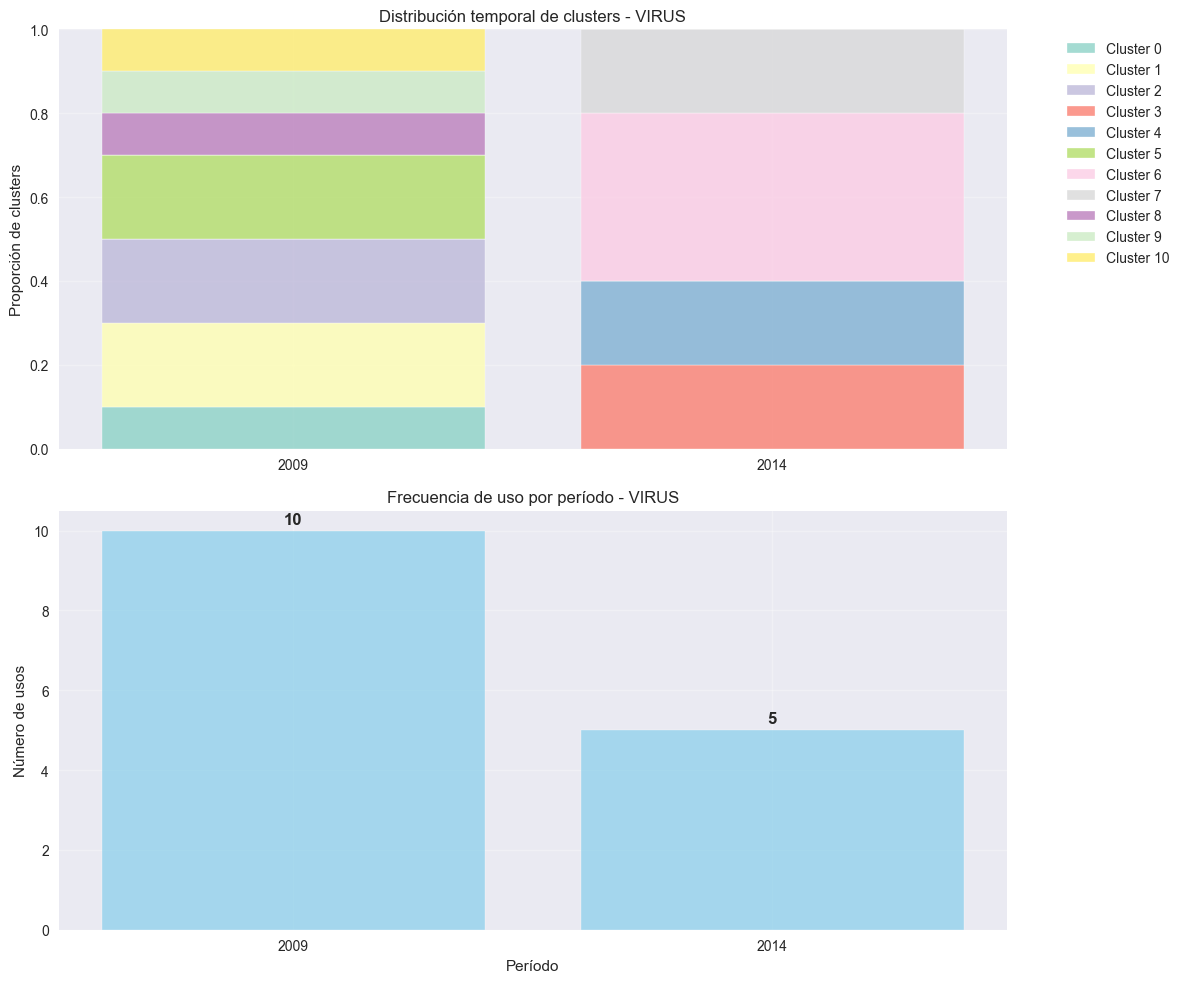

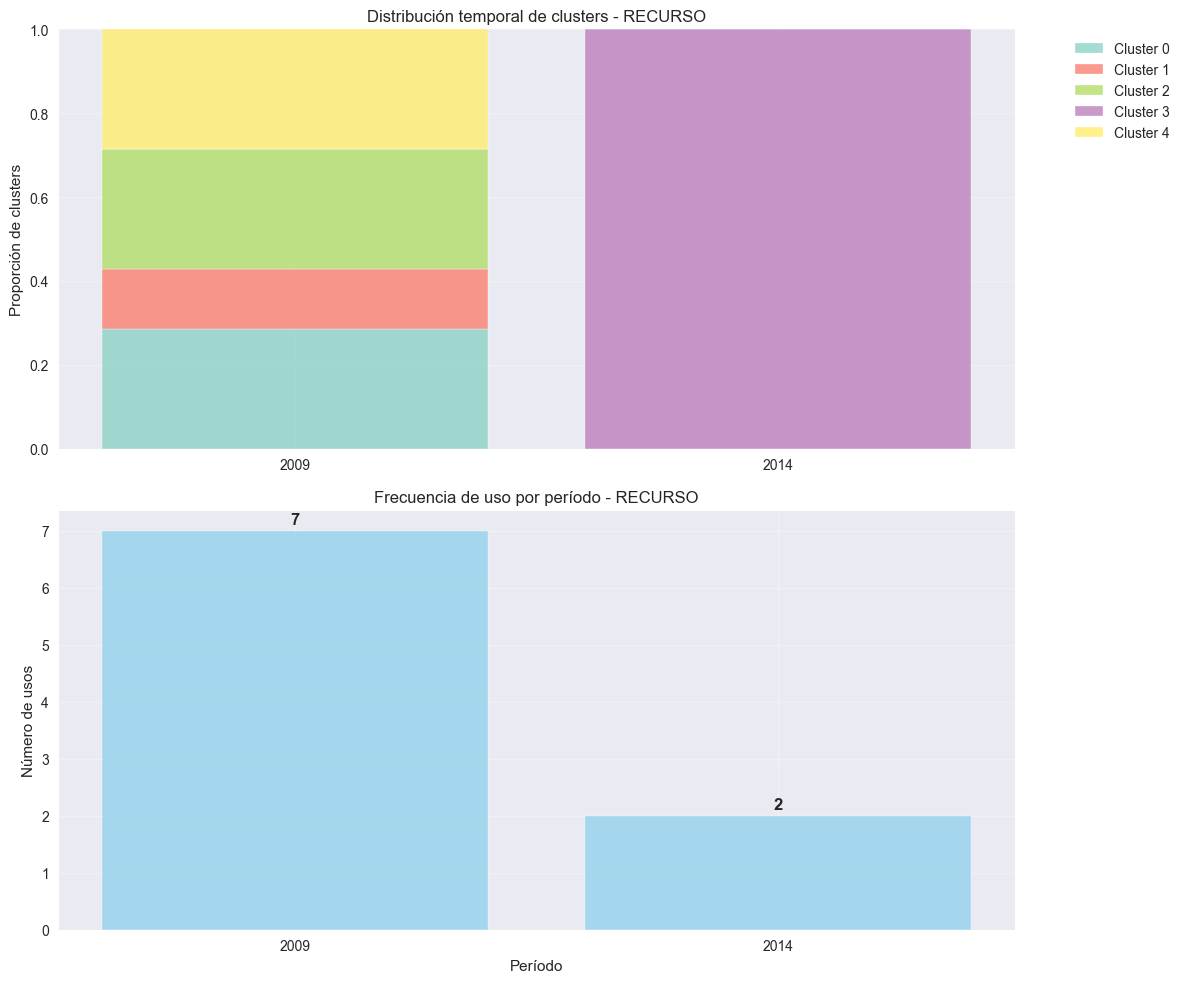

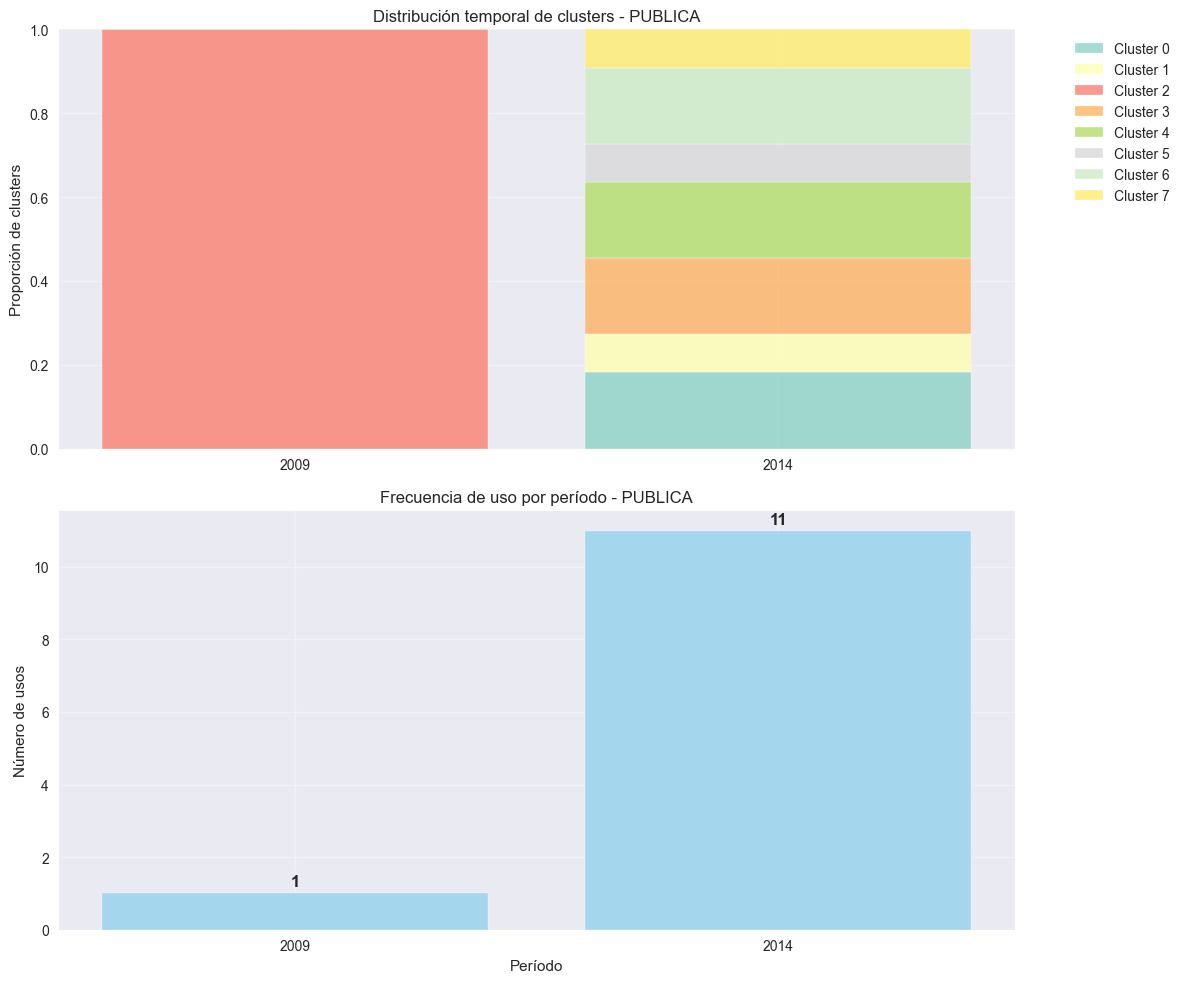

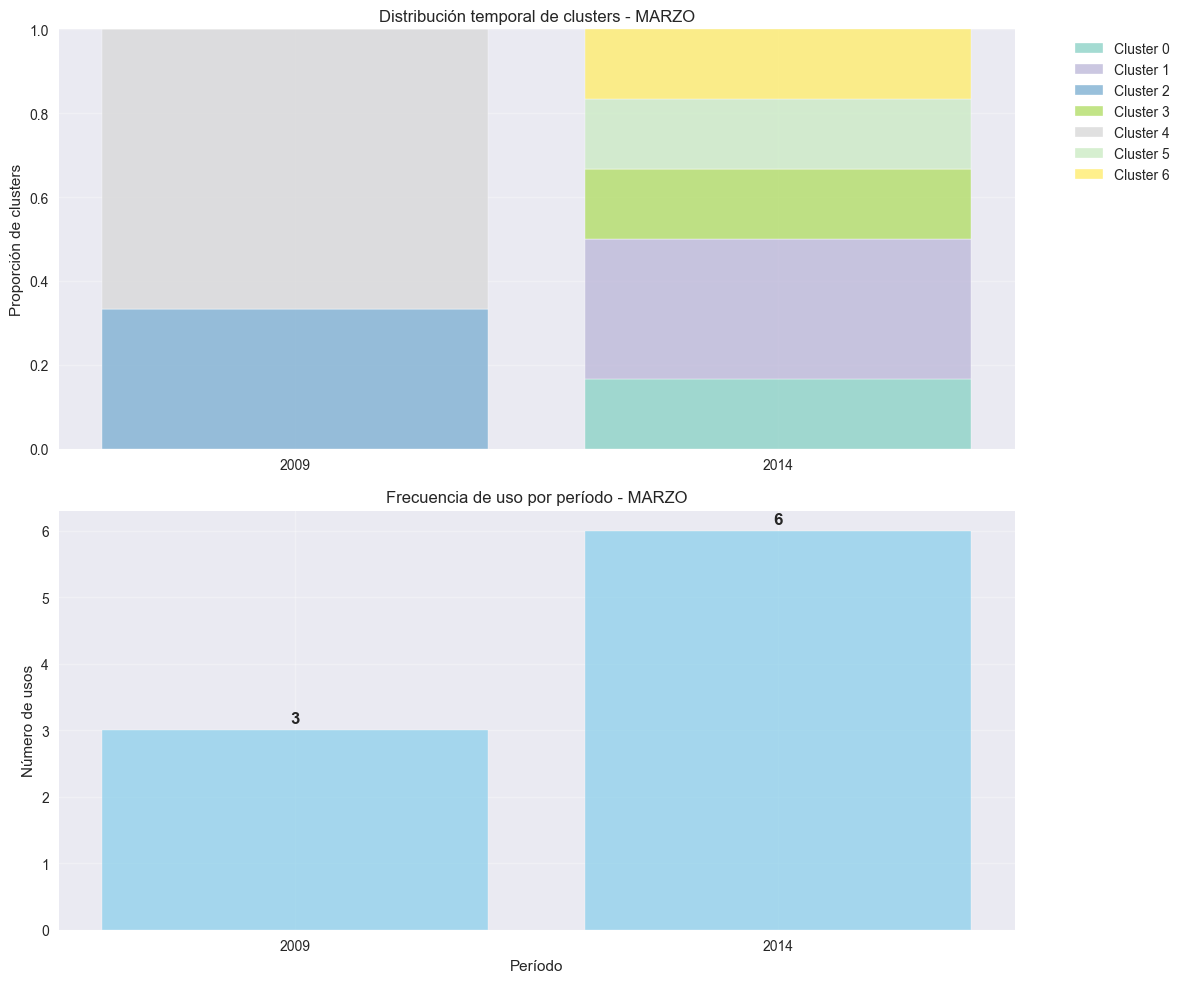

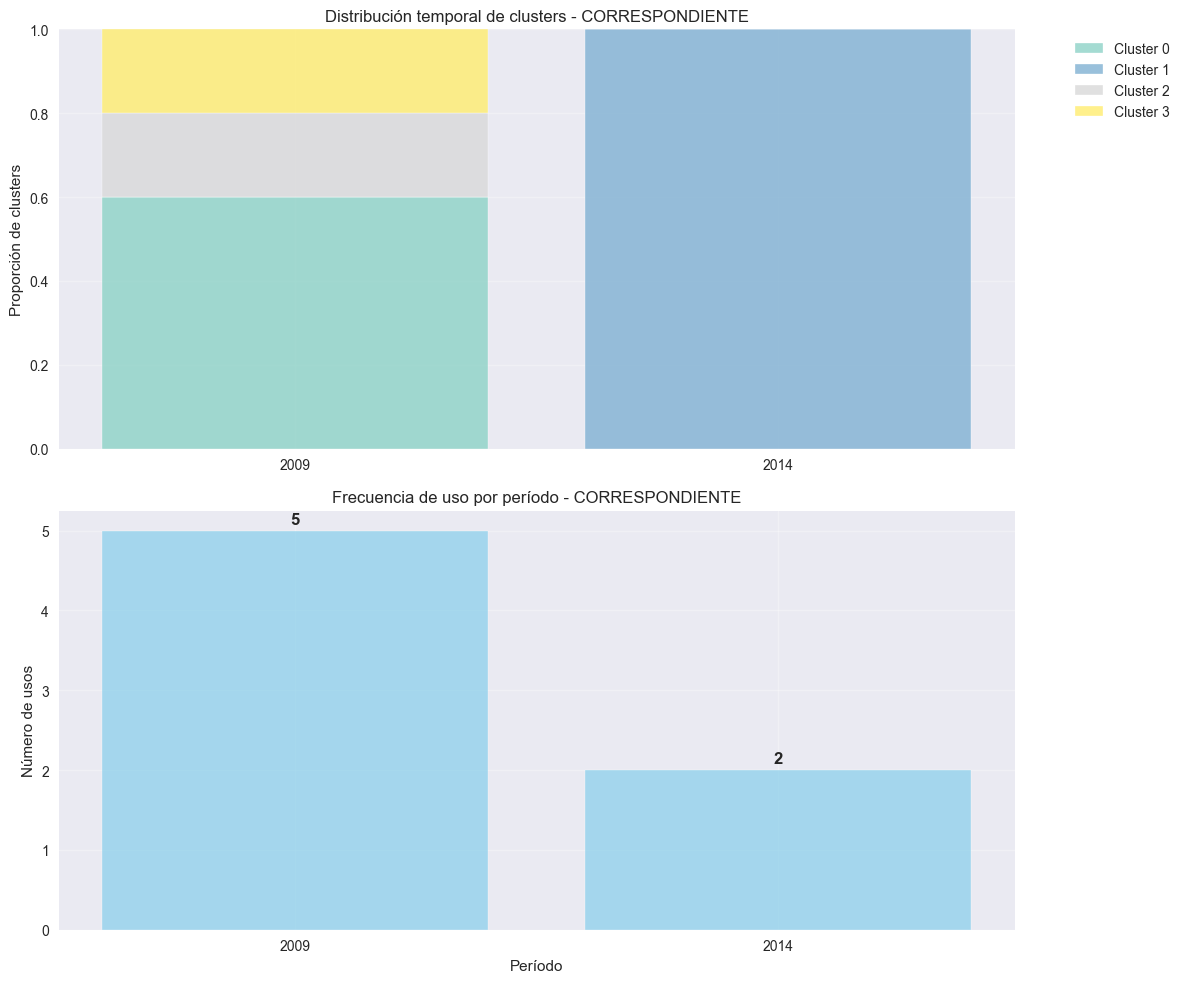

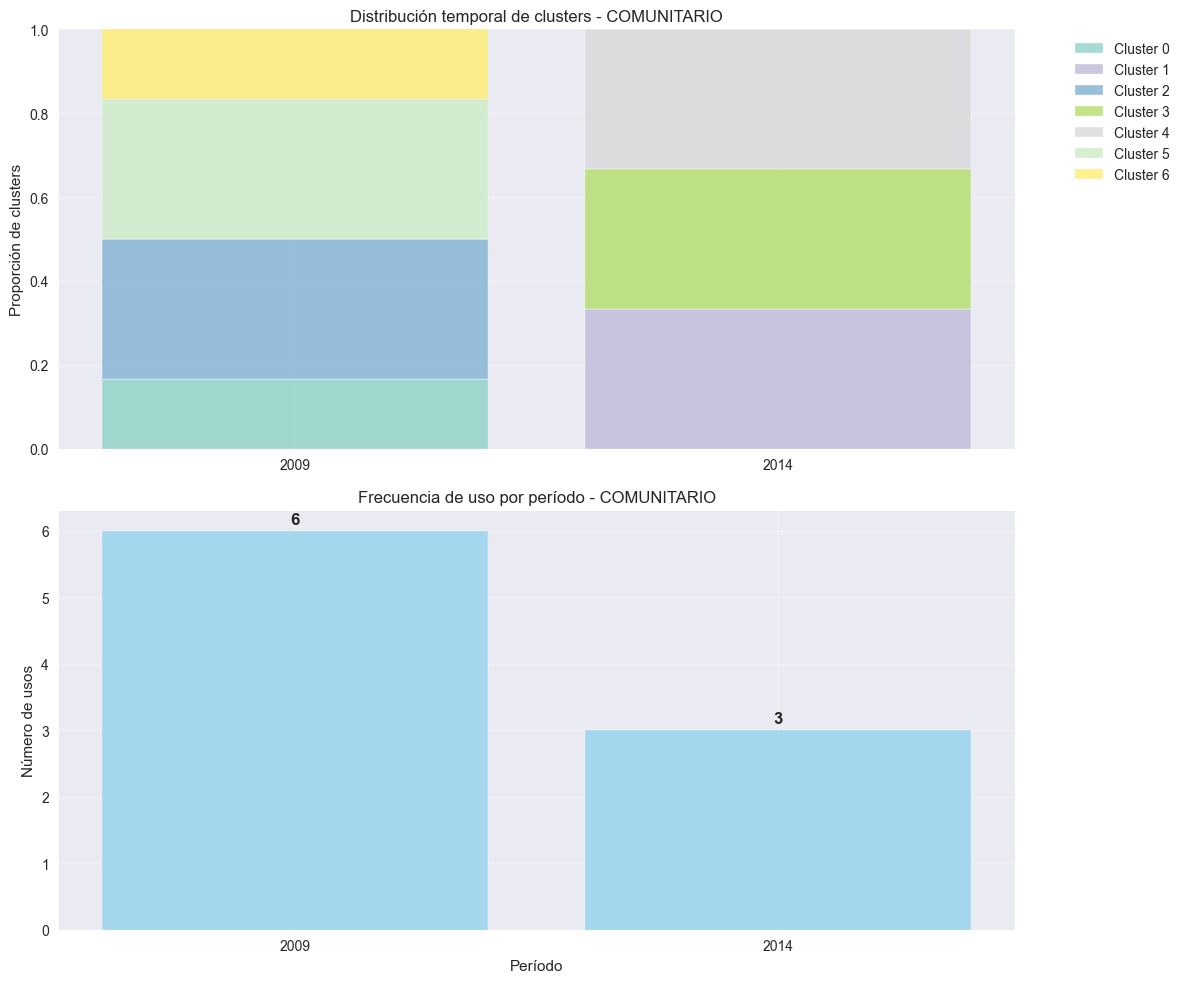

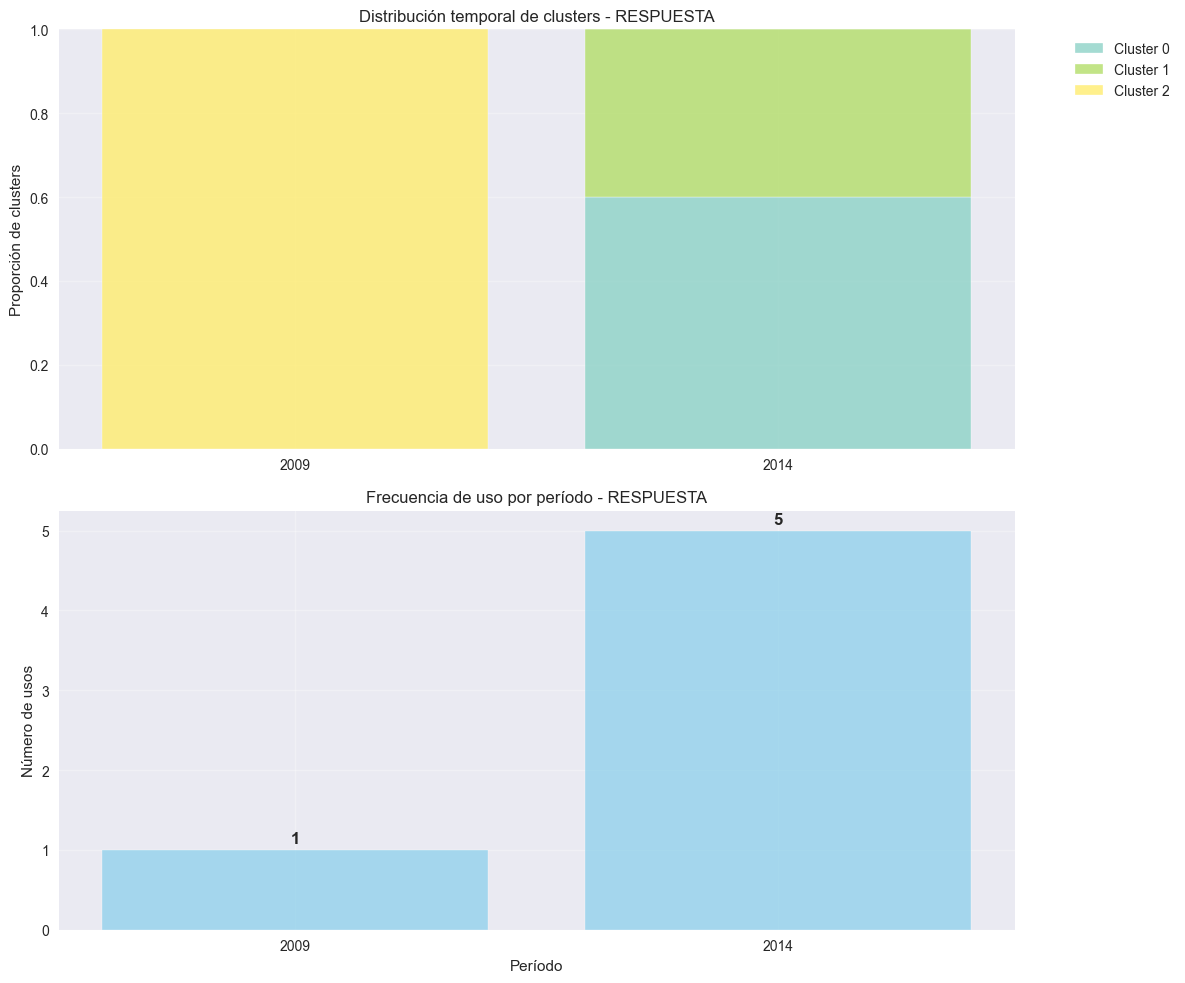

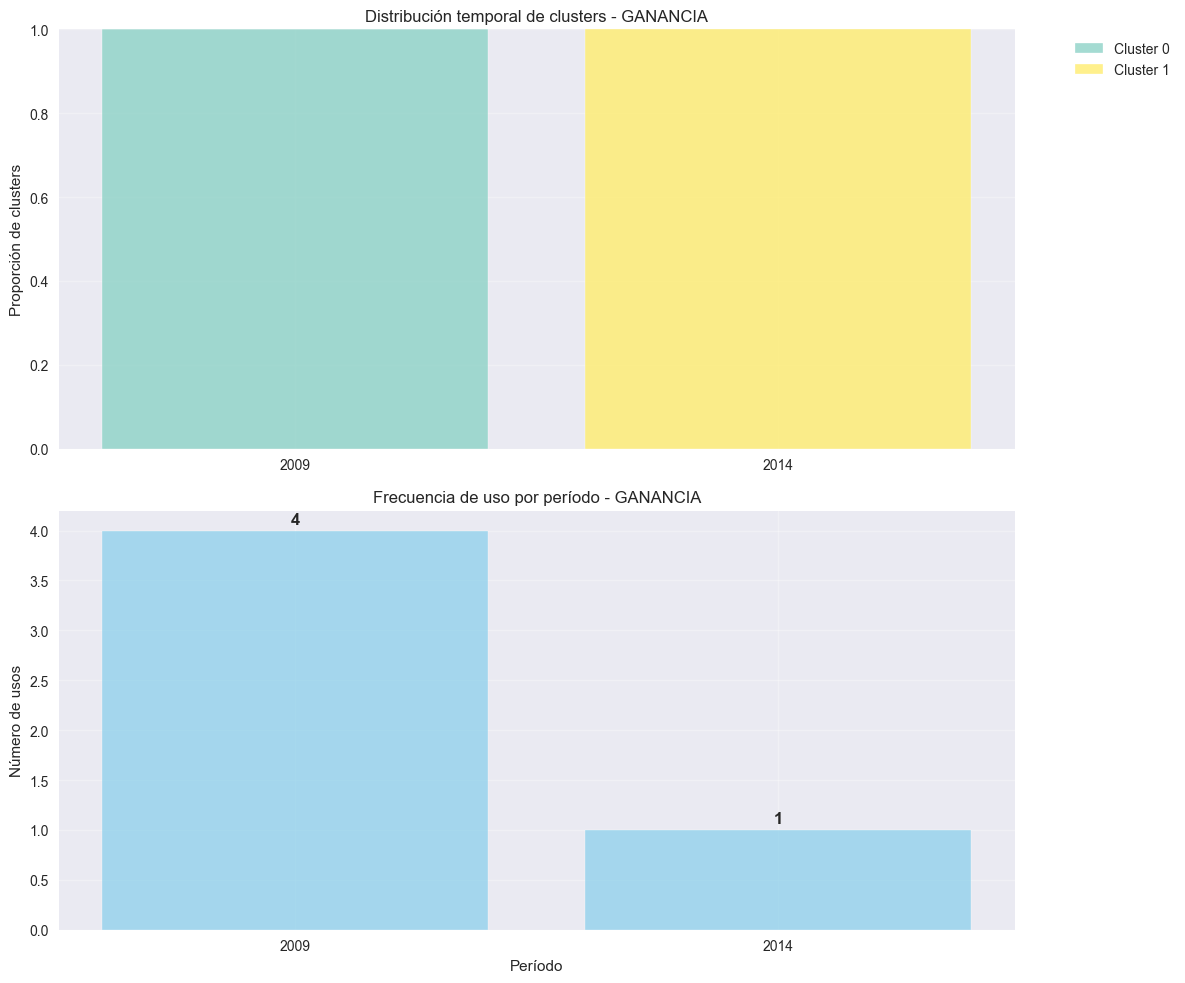

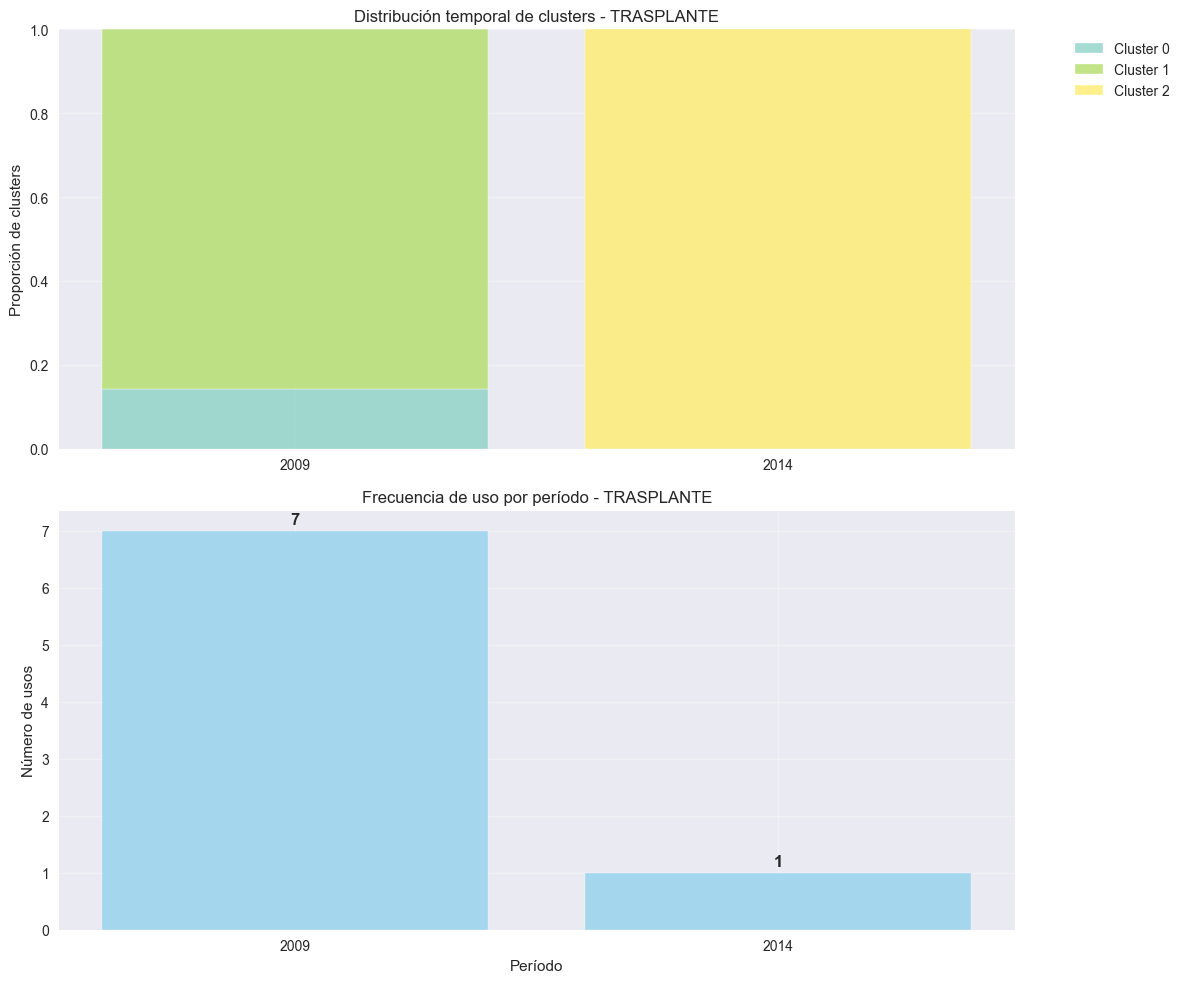

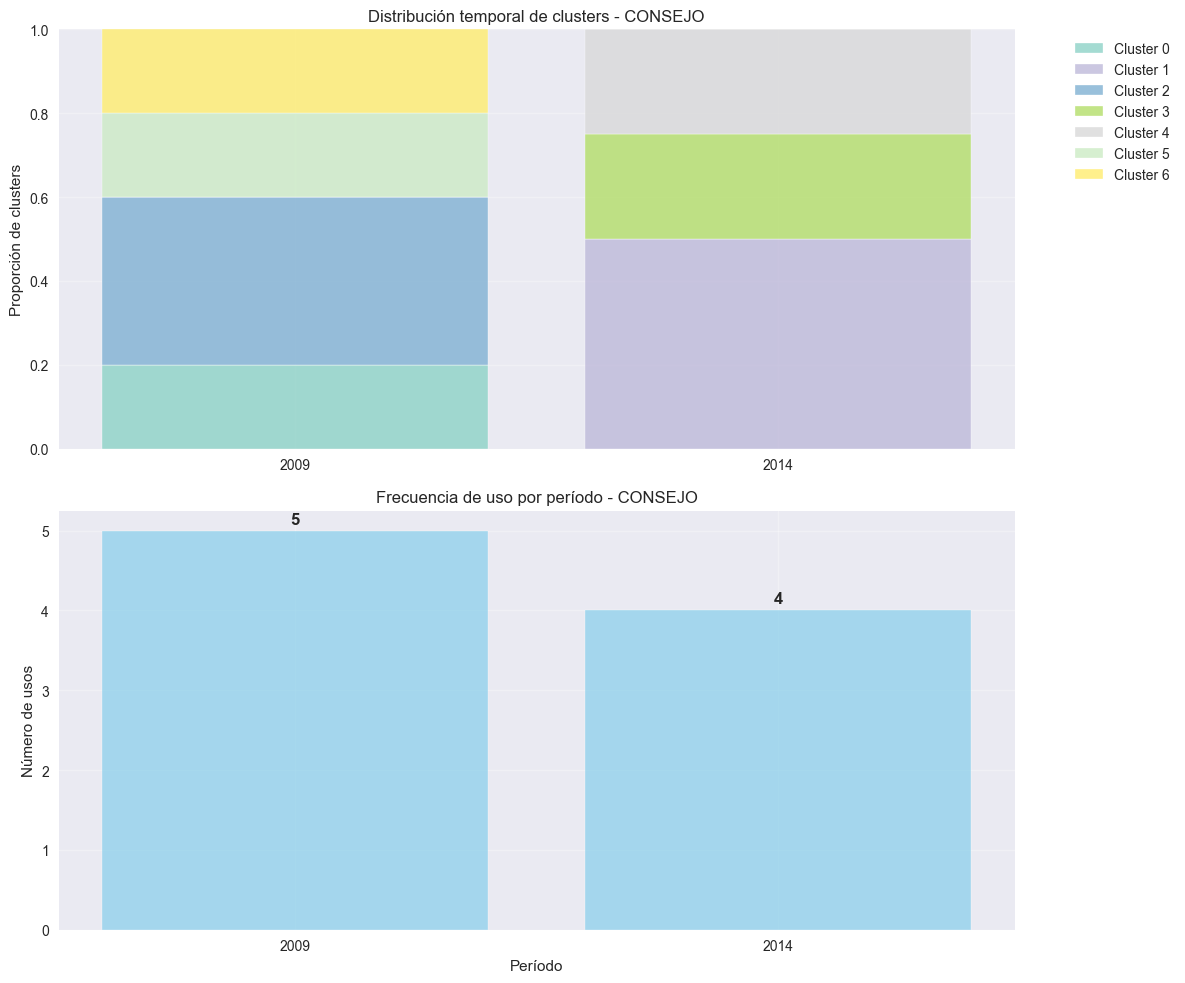

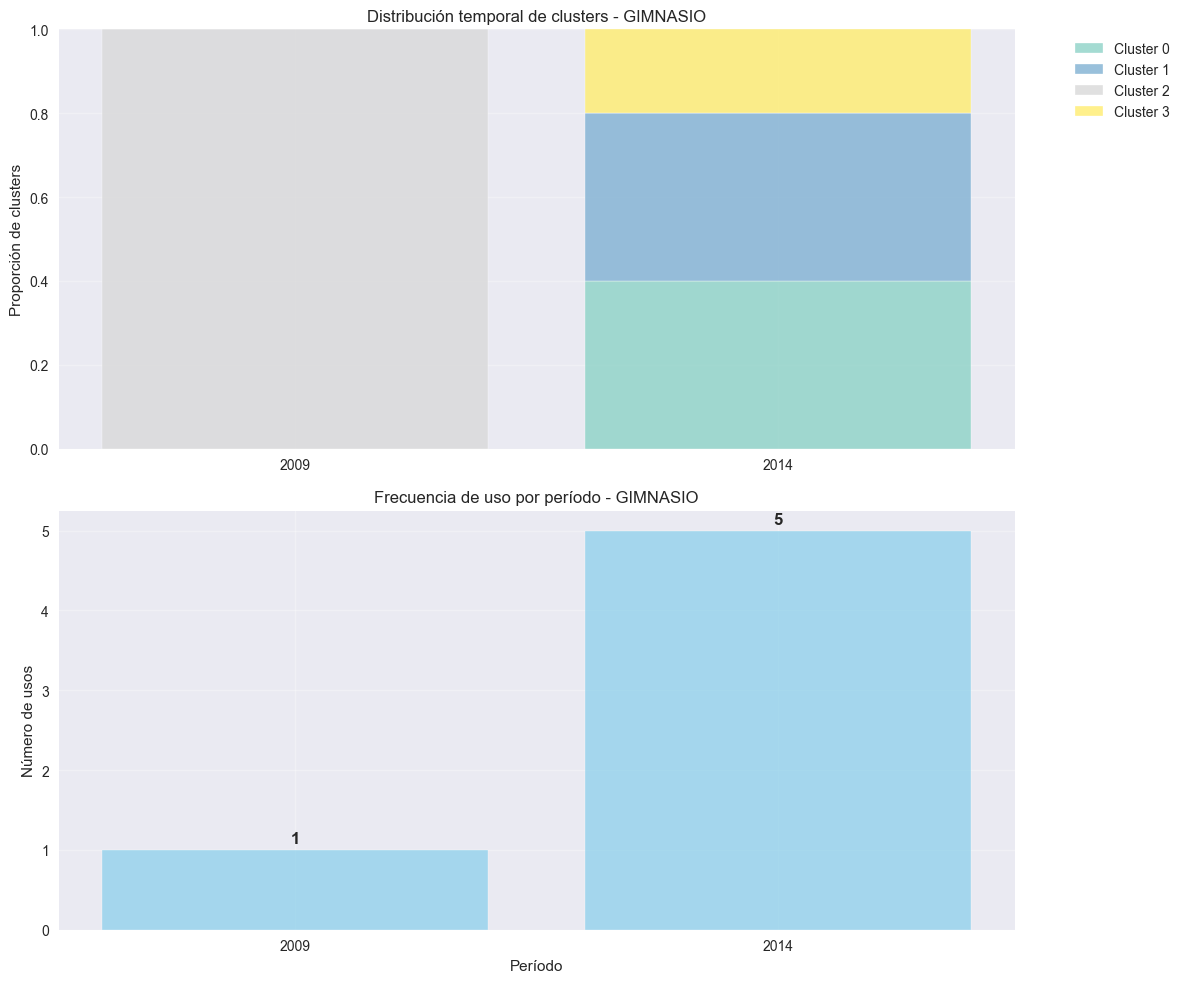

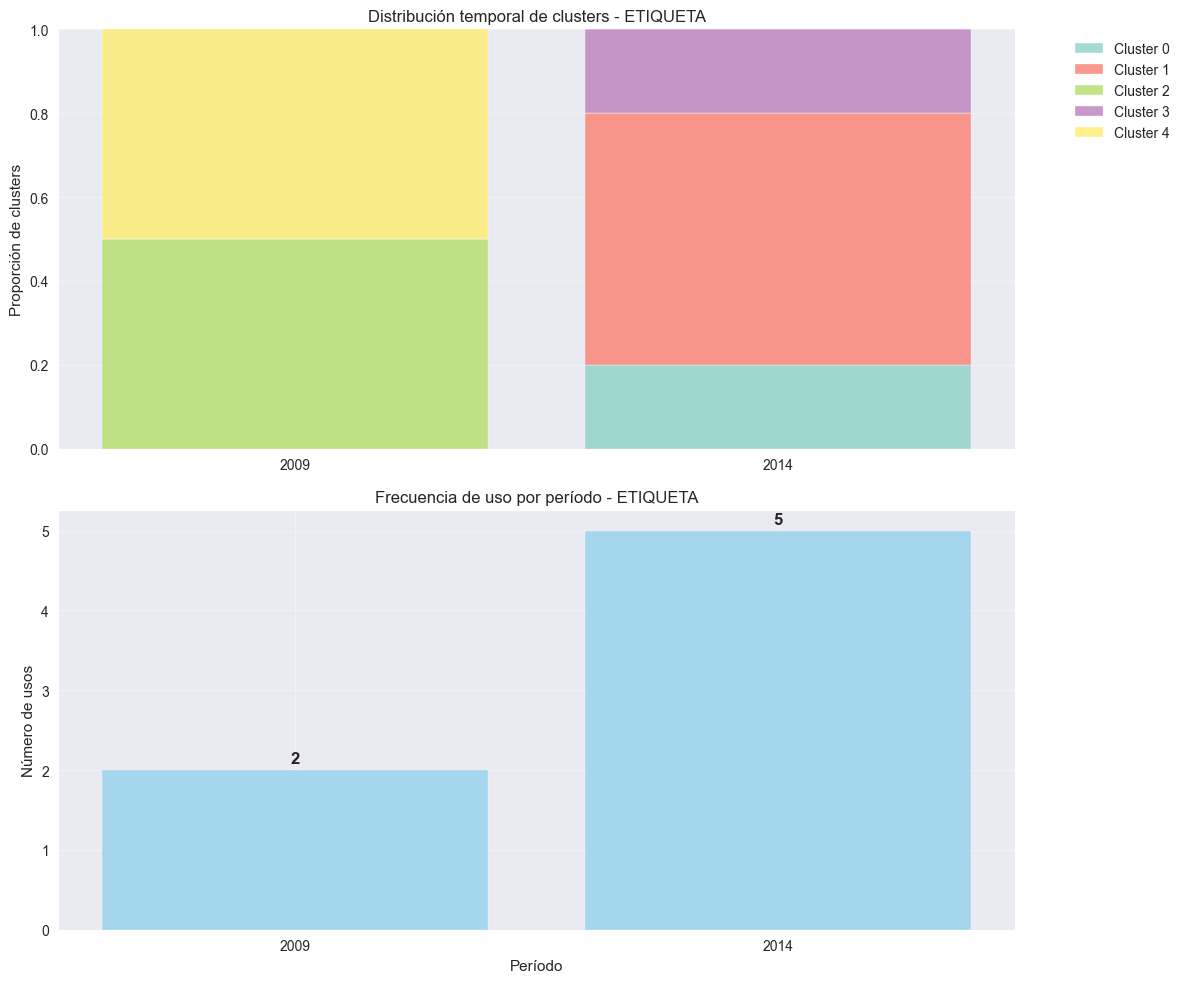

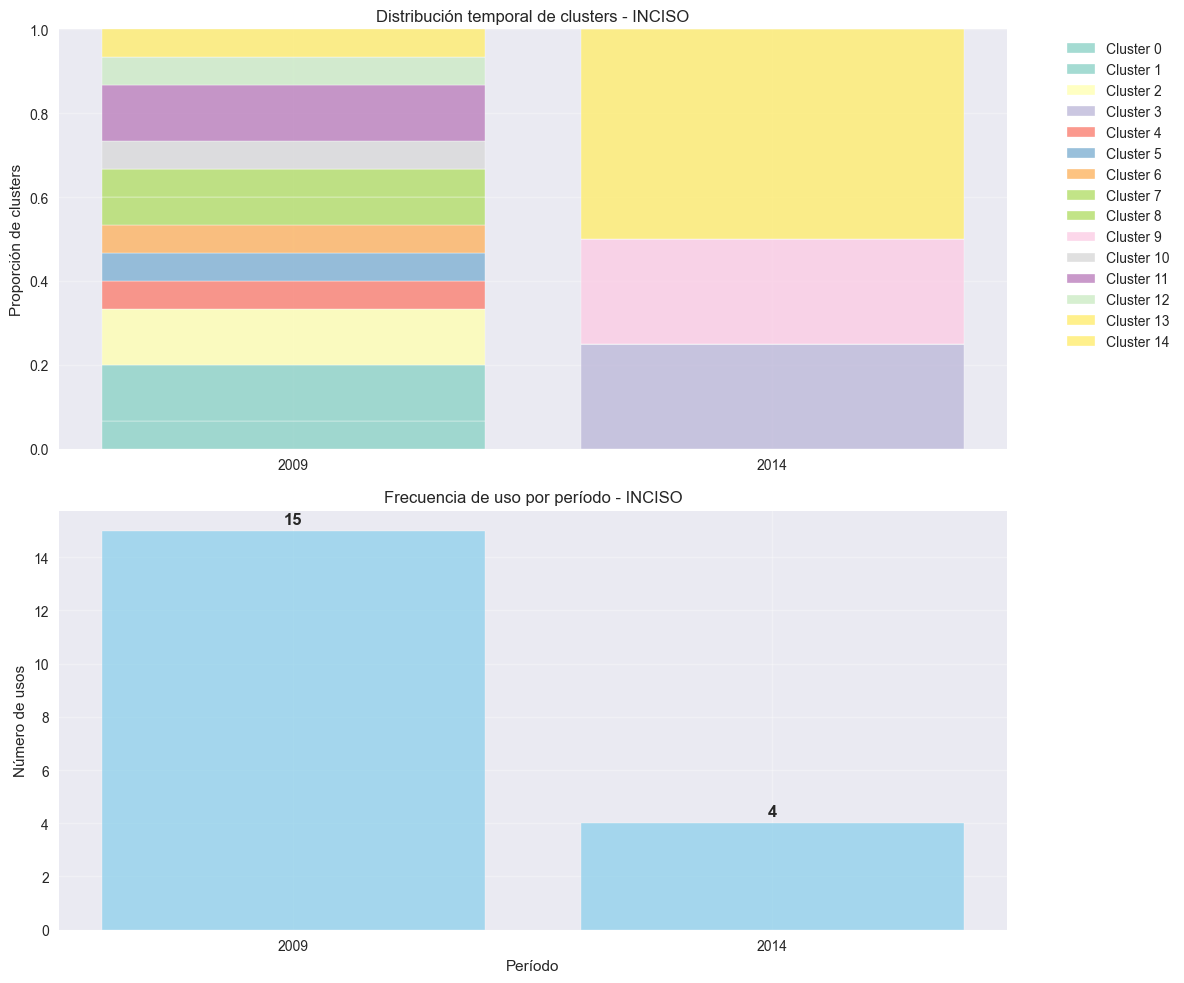

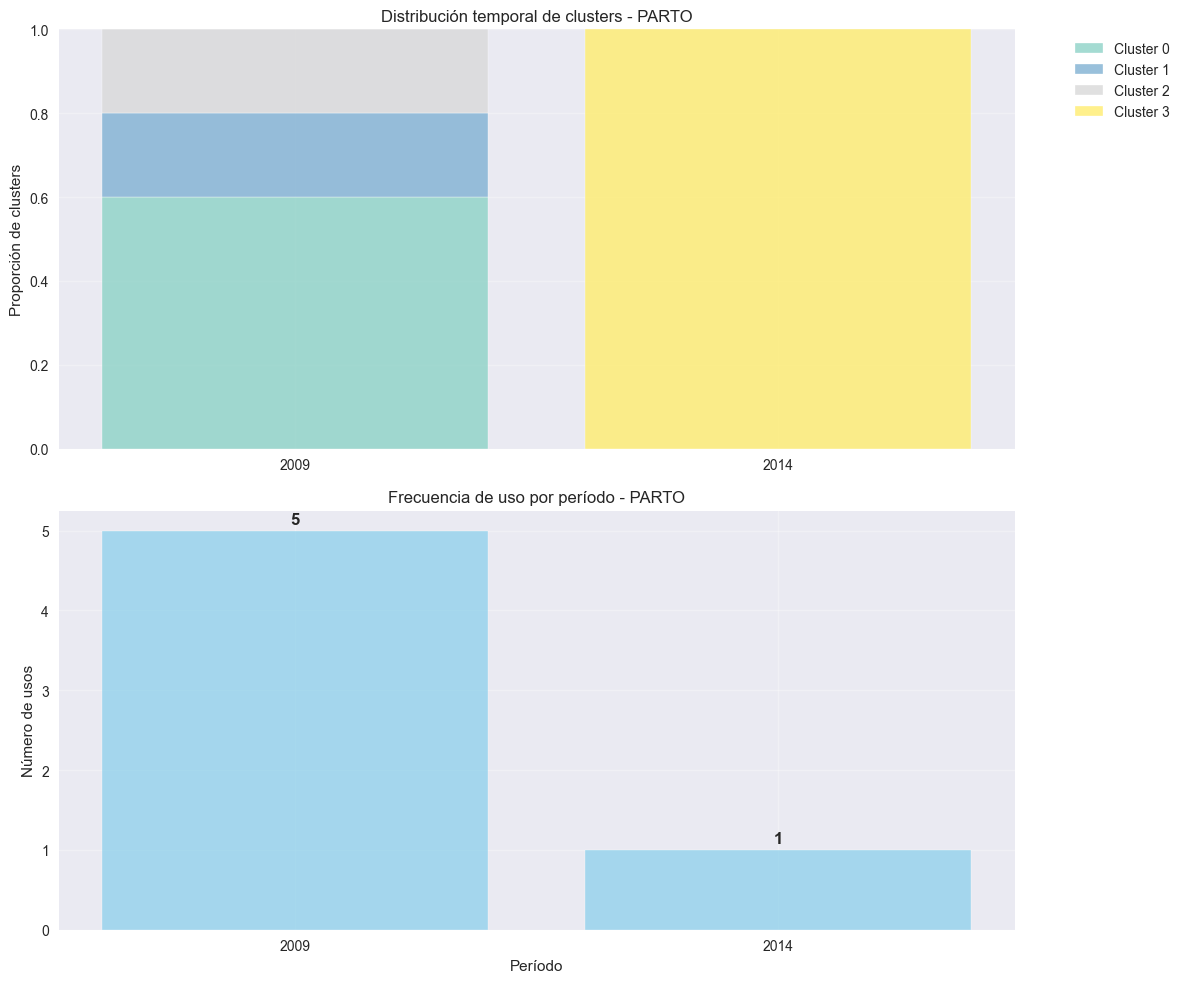

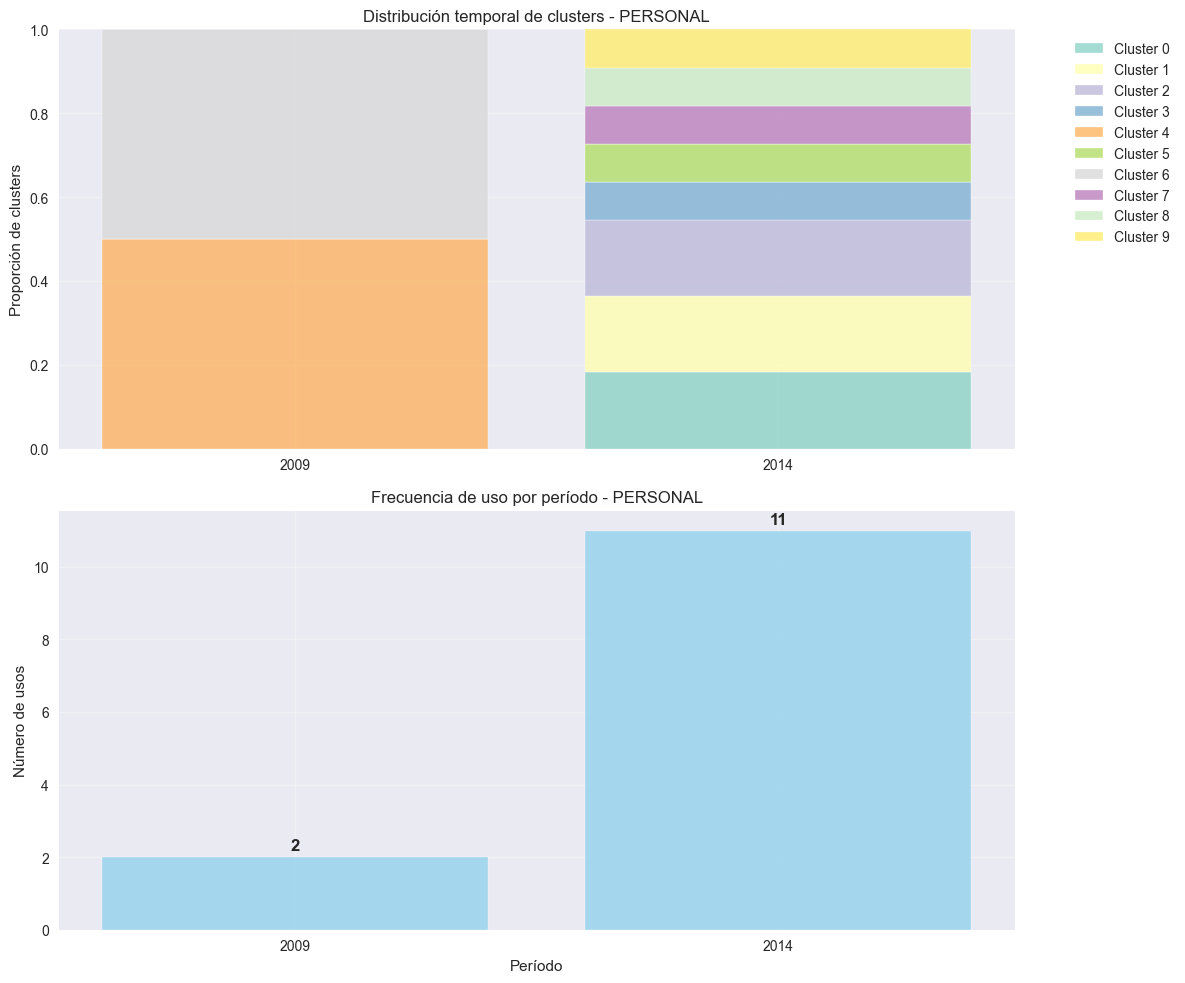

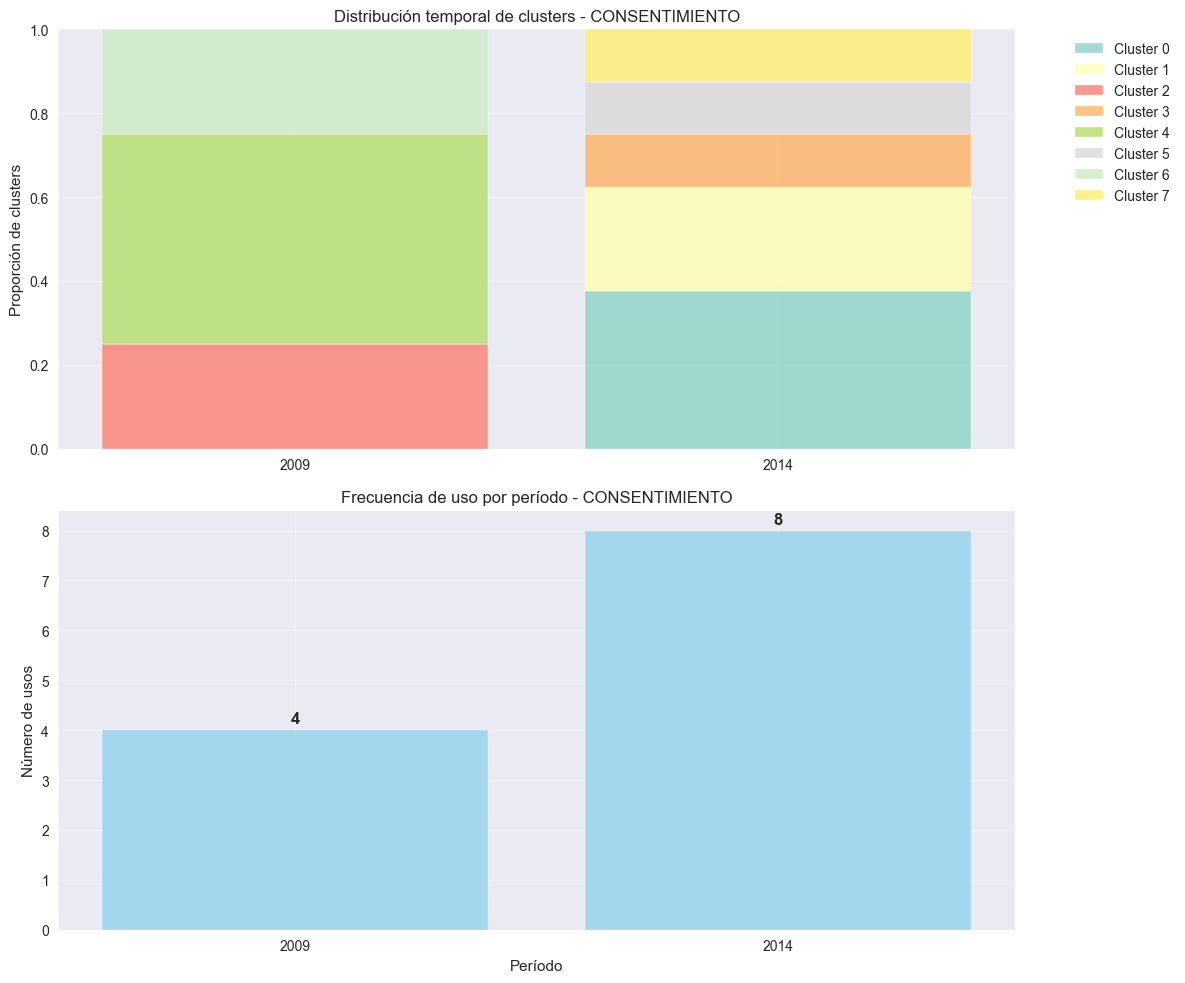

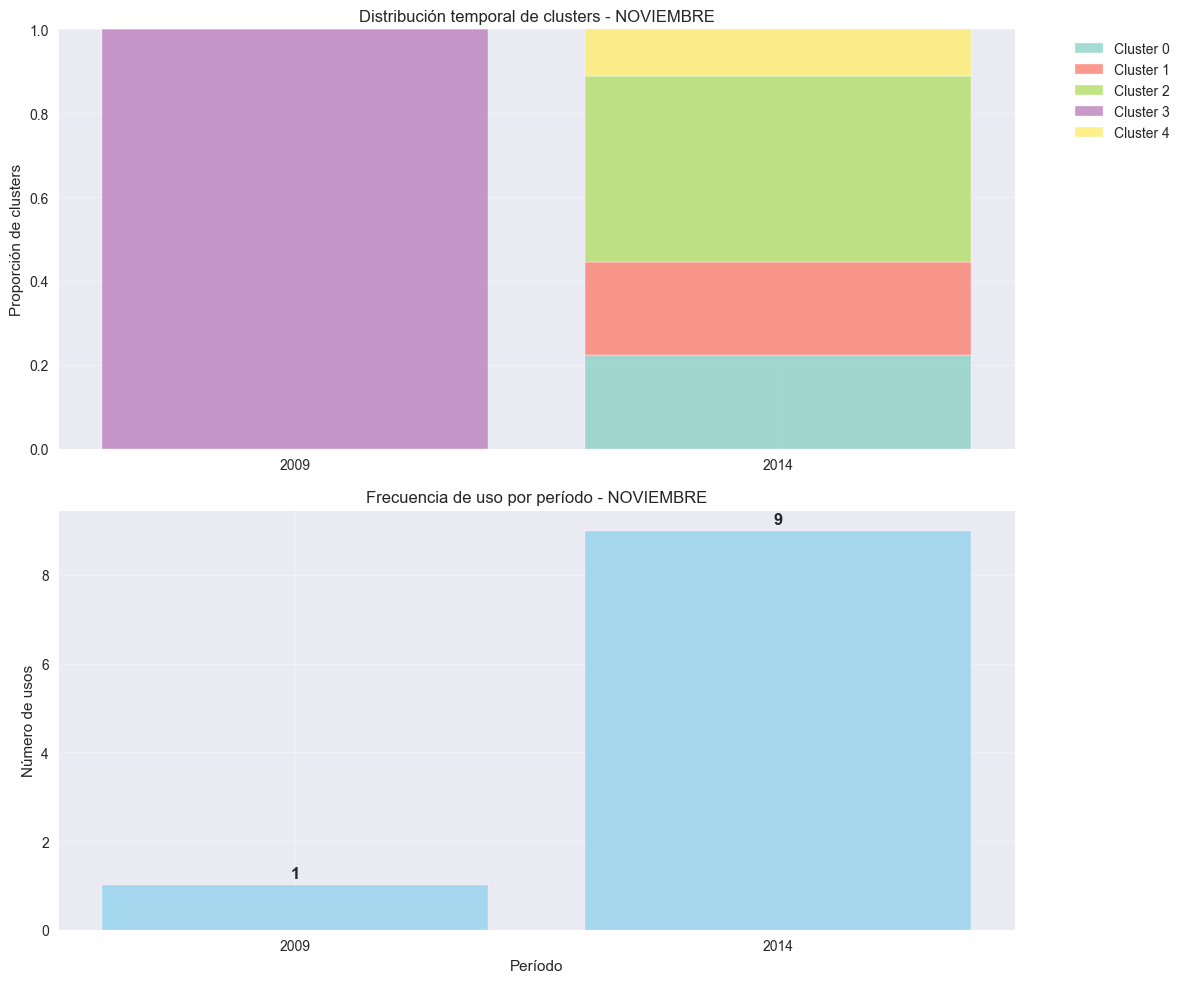

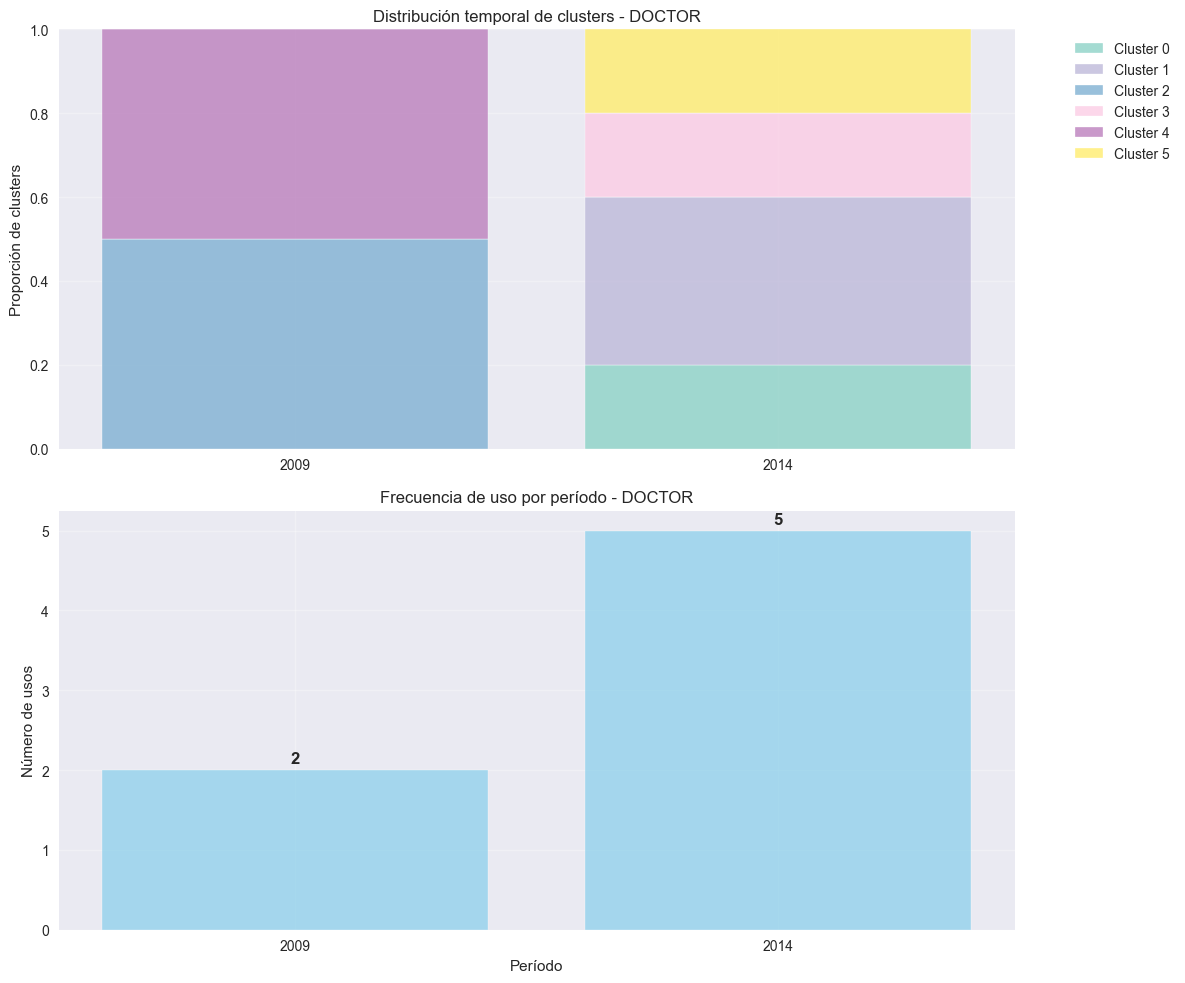

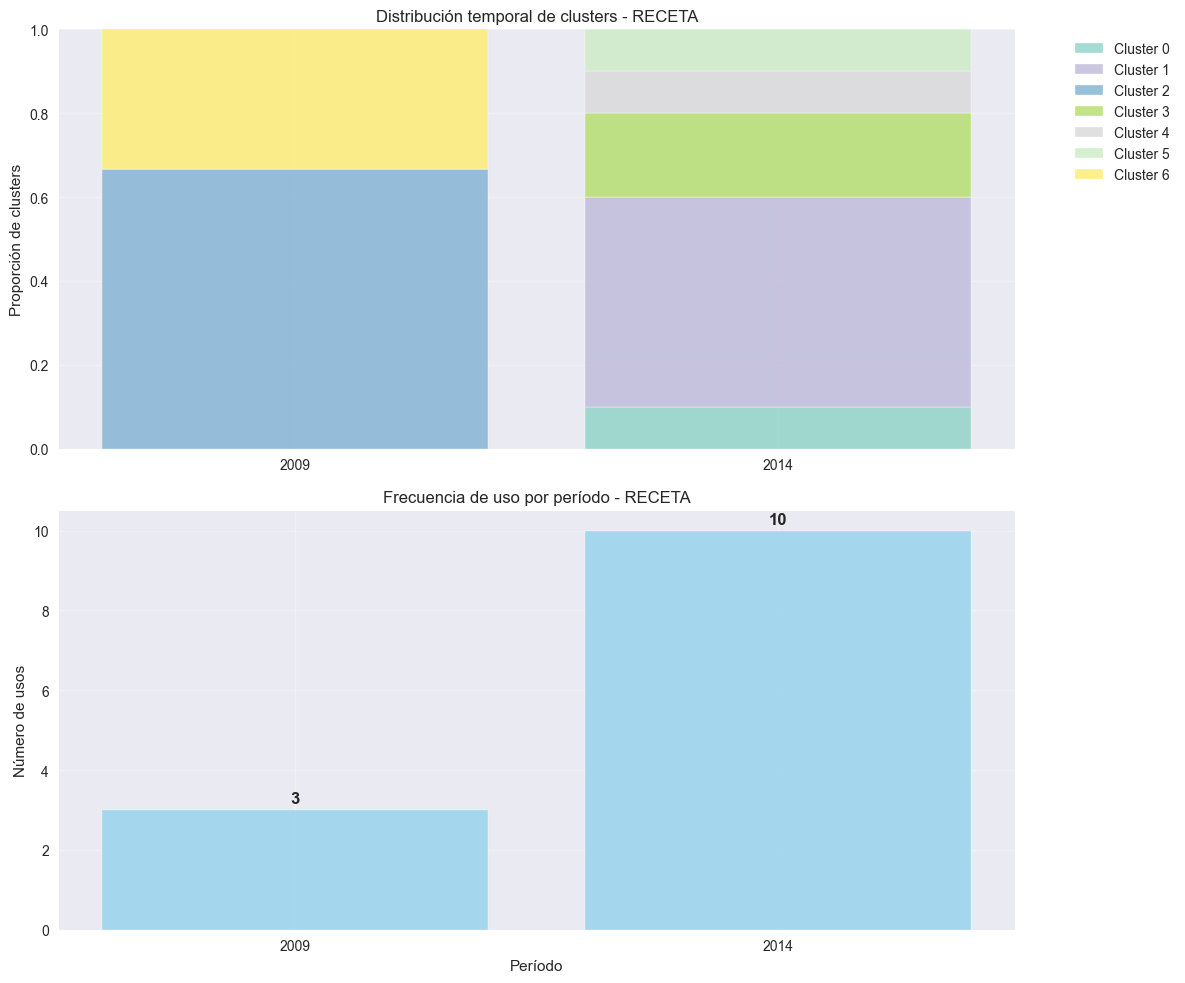

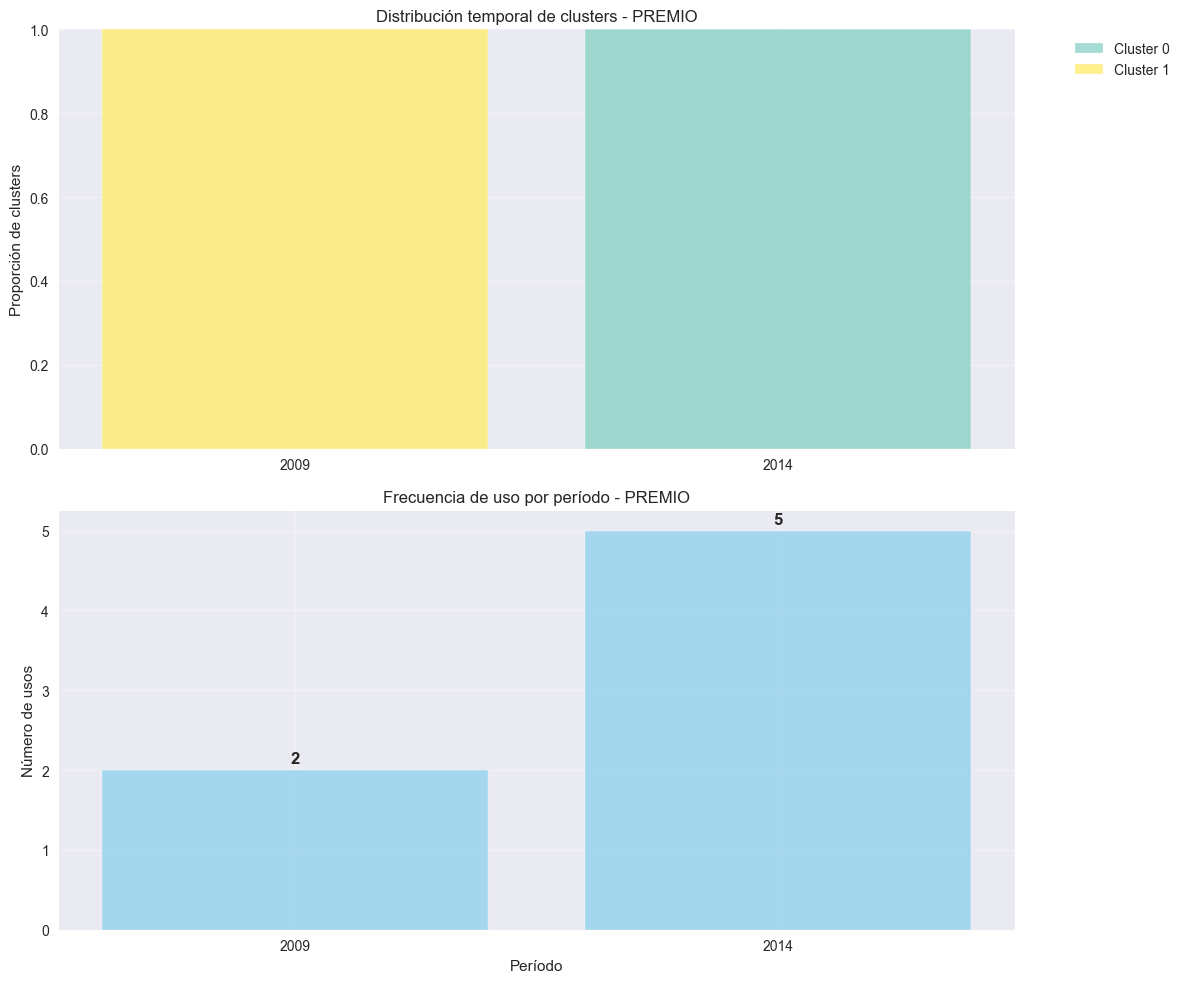

Generando visualizaciones t-SNE...


TypeError: 'float' object is not subscriptable

In [77]:
print("Generando visualizaciones...")
for par_periodo, resultado_ec in enfContexto_resultado.items():
    print(par_periodo)
    palabrasEtiqueta_list =  resultado_ec['top20_palabrasCambio']
    print(palabrasEtiqueta_list)
    if (par_periodo == (2009,2019)):
        
        periodo_lista = periodosComp_lista
    else:
        periodo_lista = [par_periodo[0], par_periodo[1]]
        
    metricas_dic = resultado_ec['metricas_dic']
    clustering_resultados = resultado_ec['clustering_resultados']
    visualize_clustering_results(clustering_resultados, metricas_dic, palabrasEtiqueta_list, periodo_lista)

    # Identificar palabras con mayor cambio (tu código original)


In [38]:
#print("Generando visualizaciones...")
#visualize_clustering_results(clustering_resultados, metricas_dic, palabrasEtiqueta_list, periodo_list)


In [39]:
enfContexto_resultado[(2009, 2014)].keys()

dict_keys(['matrices_usos', 'clustering_resultados', 'metricas_dic', 'top20_palabrasCambio'])

In [40]:
for par_periodo, resultado_ec in enfContexto_resultado.items():
    print(par_periodo)
    max_change_words =  resultado_ec['top20_palabrasCambio']
    metricas_dic = resultado_ec['metricas_dic']
    clustering_resultados = resultado_ec['clustering_resultados']

    if (par_periodo == (2009,2019)):
        periodo_lista = periodosComp_lista
    else:
        periodo_lista = [par_periodo[0], par_periodo[1]]
        

    nombre_archivo = '_Clustering'+str(par_periodo[0])+'_'+str(par_periodo[1])+'.csv'
    analisis_cualitativo_maxPalabra(metricas_dic, clustering_resultados, max_change_words, periodo_lista,nombre_archivo)

  


(2009, 2014)

=== RESULTADOS DEL ANÁLISIS DE CAMBIO SEMÁNTICO ===

=== ANÁLISIS CUALITATIVO ===

Análisis para 'virus':
  Clusters globales: 11 (silhouette: 0.319)
  Período 2009: 10 usos
    Distribución: ['0.10', '0.20', '0.20', '0.00', '0.00', '0.20', '0.00', '0.00', '0.10', '0.10', '0.10']
  Período 2014: 5 usos
    Distribución: ['0.00', '0.00', '0.00', '0.20', '0.20', '0.00', '0.40', '0.20', '0.00', '0.00', '0.00']

Análisis para 'recurso':
  Clusters globales: 5 (silhouette: 0.497)
  Período 2009: 7 usos
    Distribución: ['0.29', '0.14', '0.29', '0.00', '0.29']
  Período 2014: 2 usos
    Distribución: ['0.00', '0.00', '0.00', '1.00', '0.00']

Análisis para 'publica':
  Clusters globales: 8 (silhouette: 0.435)
  Período 2009: 1 usos
    Distribución: ['0.00', '0.00', '1.00', '0.00', '0.00', '0.00', '0.00', '0.00']
  Período 2014: 11 usos
    Distribución: ['0.18', '0.09', '0.00', '0.18', '0.18', '0.09', '0.18', '0.09']

Análisis para 'marzo':
  Clusters globales: 7 (silhouette: 

## Muerte subita

In [115]:
# Palabras asociadas a muerte súbita
ms_palabras = ['muerte_subita' ,'desfibrilador','desfibracion','cardiovascular','cardioasistido','dea','dispositivo', 'muerte','vida','vivir','morir','capacitacion','capacitar','capacita', 'emergencia','supervivencia','reanimacion','prevencion','incidencia','deportivo']


(2009, 2014)


,palabra,periodo,JS divergence,APD_cosine,APD_canberra,APD_euclidean,cluster_distribucion_1,cluster_distribucion_2,cantidad_1,cantidad_2
50,vida,2009-2014,0.544289,0.108706,318.172830,116.040992,"[0.3333333333333333, 0.16666666666666666, 0.0, 0.0, 0.16666666666666666, 0.0, 0.16666666666666666, 0.0, 0.0, 0.16666666666666666]","[0.0, 0.2857142857142857, 0.14285714285714285, 0.14285714285714285, 0.0, 0.14285714285714285, 0.0, 0.14285714285714285, 0.14285714285714285, 0.0]",6,7
62,deportivo,2009-2014,0.512468,0.116423,321.985747,122.206951,"[0.0, 0.0, 0.0, 0.2, 0.2, 0.0, 0.2, 0.0, 0.0, 0.2, 0.2]","[0.09090909090909091, 0.18181818181818182, 0.18181818181818182, 0.09090909090909091, 0.0, 0.18181818181818182, 0.09090909090909091, 0.09090909090909091, 0.09090909090909091, 0.0, 0.0]",5,11
105,muerte,2009-2014,0.424586,0.105645,298.606791,107.593797,"[0.25, 0.125, 0.25, 0.125, 0.0, 0.125, 0.125]","[0.6666666666666666, 0.0, 0.0, 0.0, 0.3333333333333333, 0.0, 0.0]",8,3
222,emergencia,2009-2014,0.208122,0.110248,322.168134,114.312313,"[0.04918032786885246, 0.06557377049180328, 0.04918032786885246, 0.06557377049180328, 0.2786885245901639, 0.11475409836065574, 0.08196721311475409, 0.04918032786885246, 0.06557377049180328, 0.01639344262295082, 0.03278688524590164, 0.0, 0.01639344262295082, 0.01639344262295082, 0.0, 0.01639344262295082, 0.03278688524590164, 0.01639344262295082, 0.03278688524590164]","[0.10416666666666667, 0.041666666666666664, 0.14583333333333334, 0.0625, 0.3333333333333333, 0.0, 0.0, 0.0625, 0.0, 0.041666666666666664, 0.0, 0.08333333333333333, 0.041666666666666664, 0.0, 0.0625, 0.0, 0.020833333333333332, 0.0, 0.0]",61,48


Generando visualizaciones de distribución temporal...


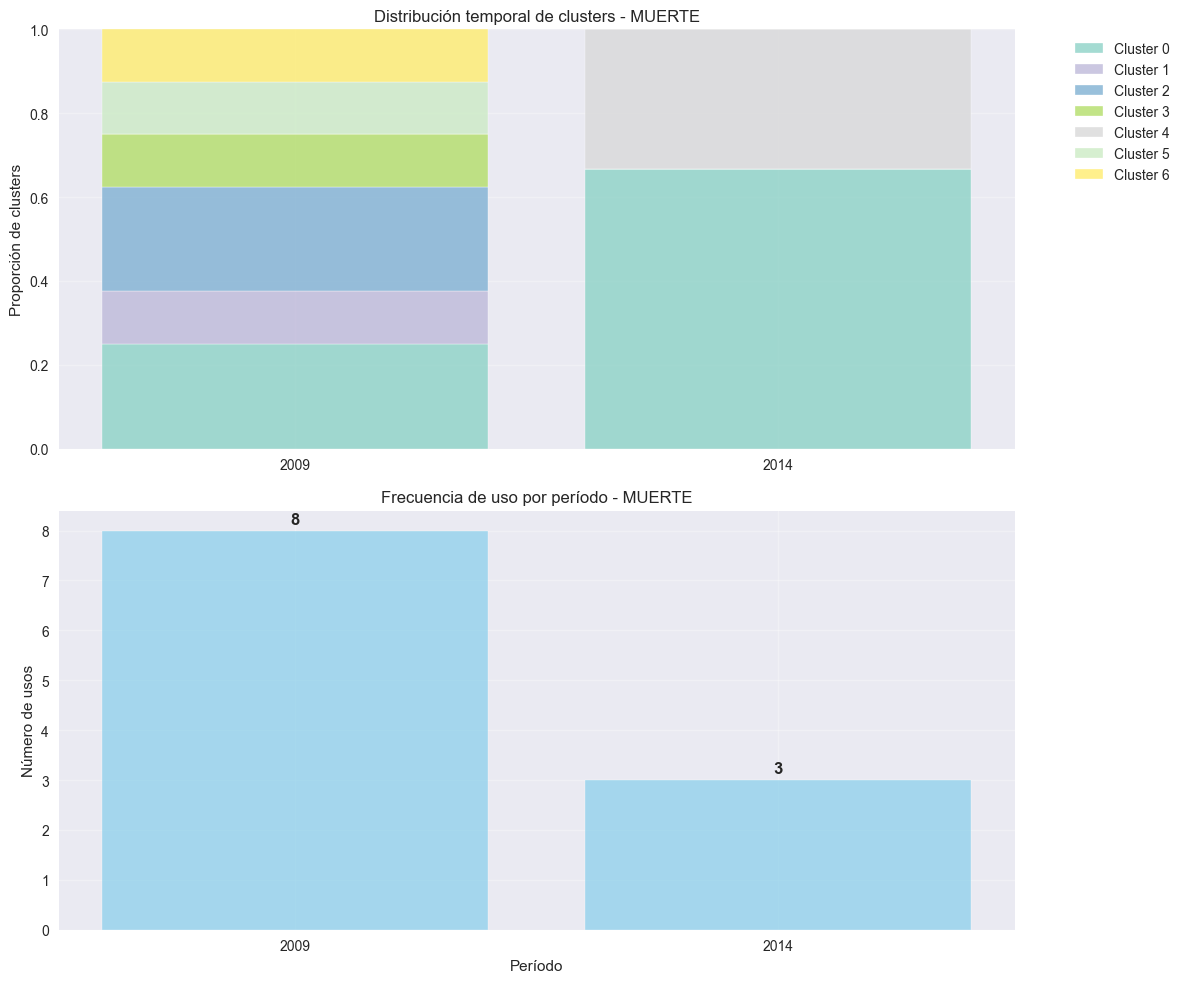

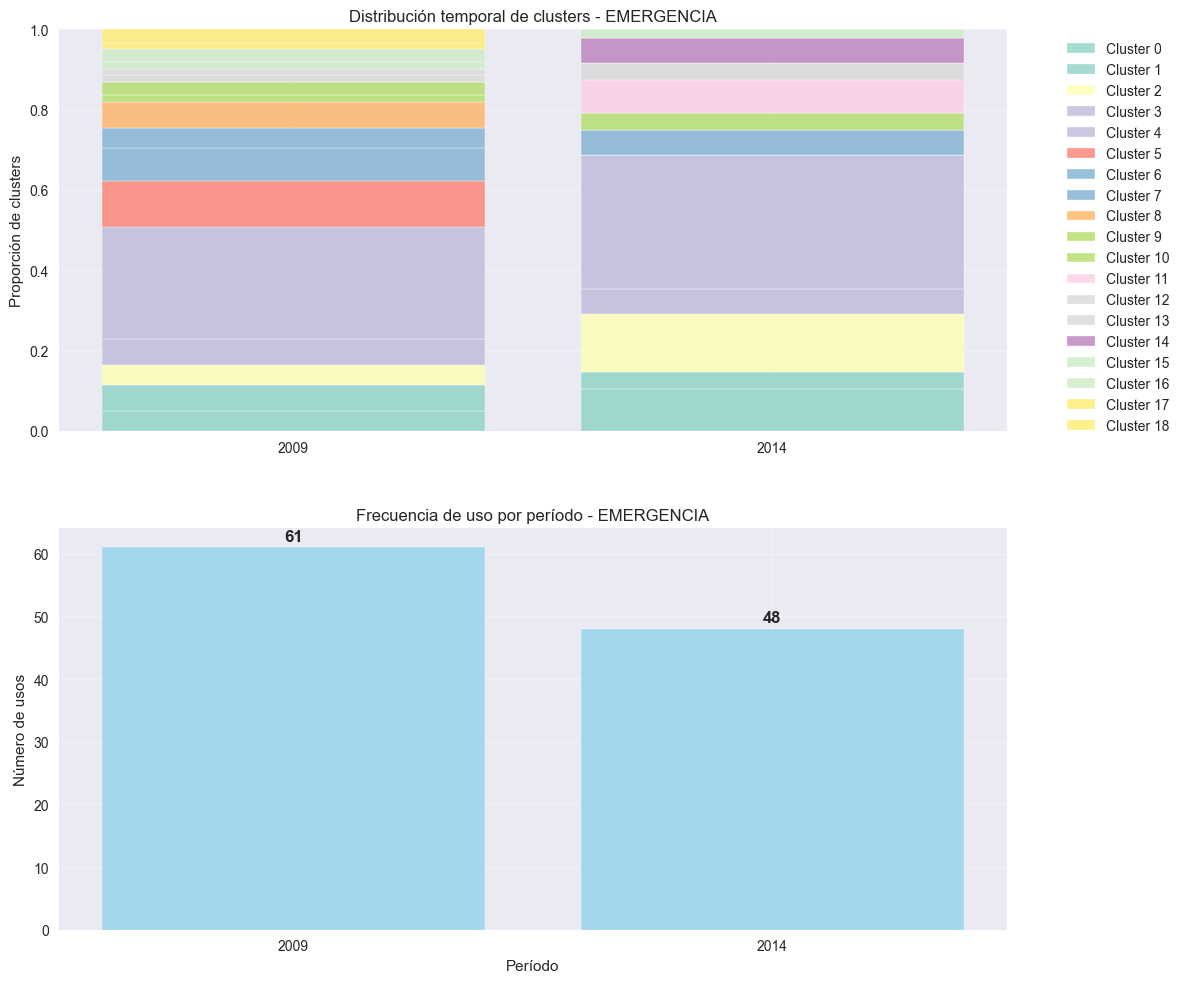

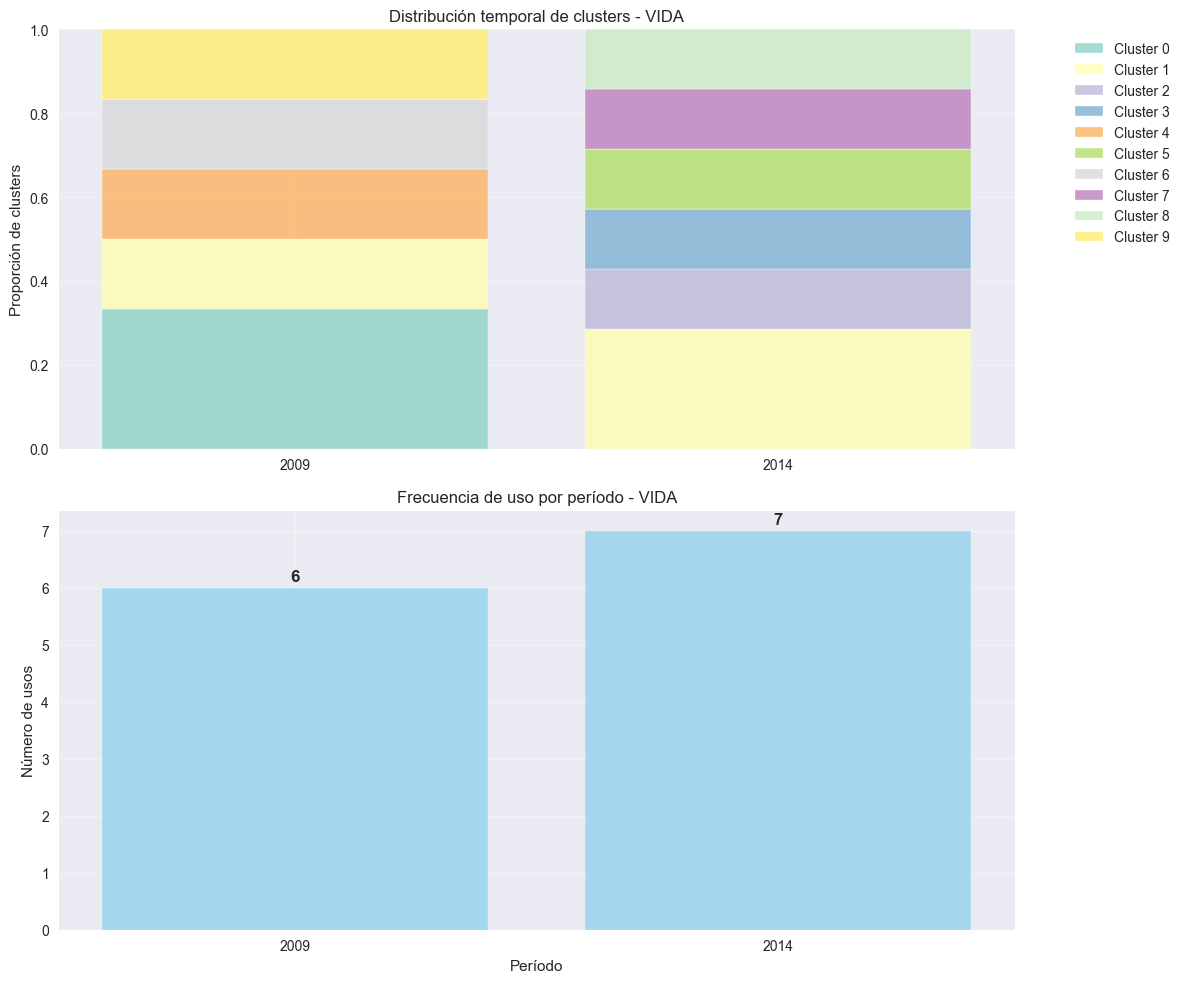

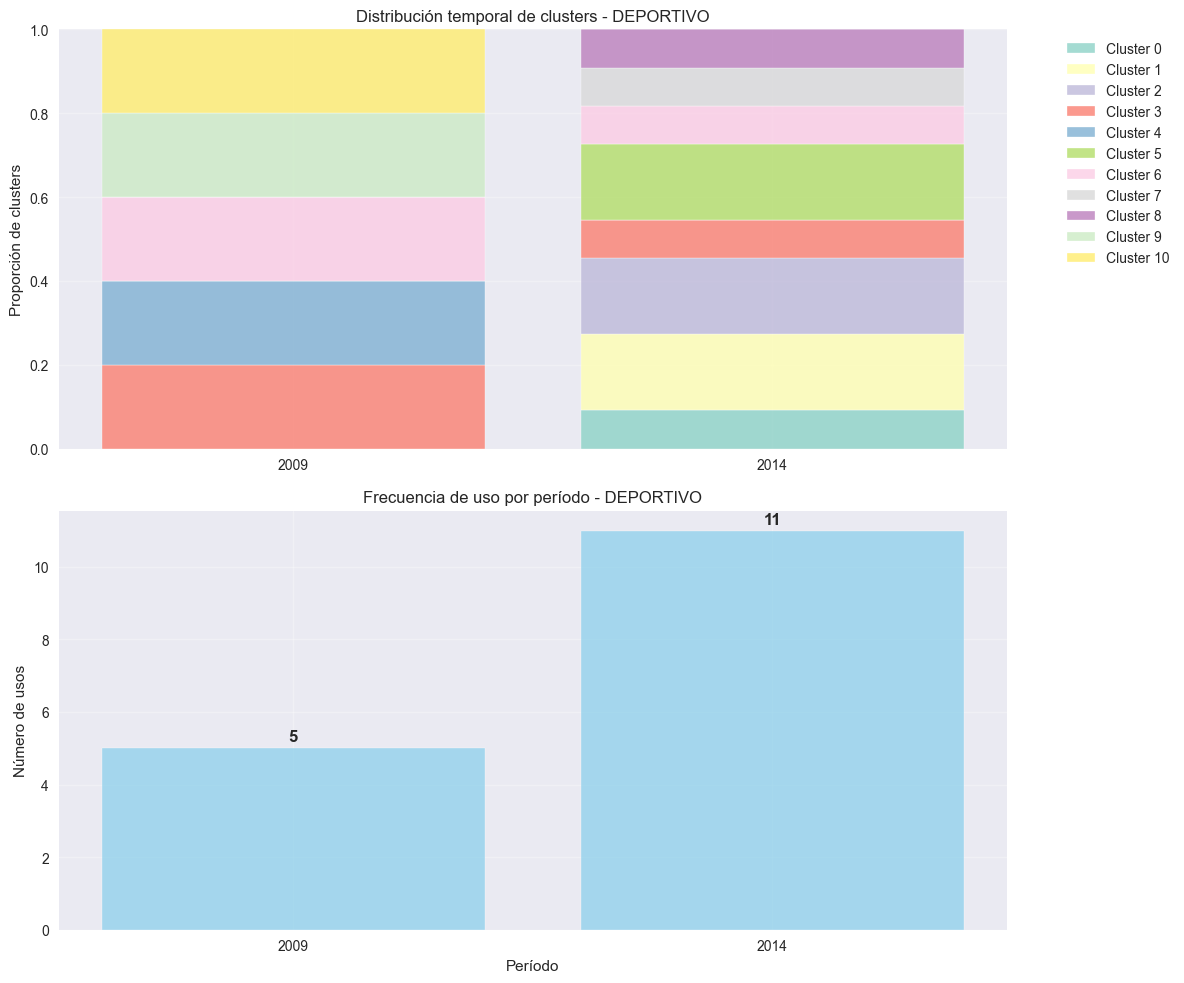

Generando visualizaciones t-SNE...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5600\1240730977.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_5600\1240730977.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


Generando heatmaps de cambio semántico...
Generando visualizaciones interactivas...

=== RESULTADOS DEL ANÁLISIS DE CAMBIO SEMÁNTICO ===

=== ANÁLISIS CUALITATIVO ===

Análisis para 'muerte':
  Clusters globales: 7 (silhouette: 0.545)
  Período 2009: 8 usos
    Distribución: ['0.25', '0.12', '0.25', '0.12', '0.00', '0.12', '0.12']
  Período 2014: 3 usos
    Distribución: ['0.67', '0.00', '0.00', '0.00', '0.33', '0.00', '0.00']

Análisis para 'emergencia':
  Clusters globales: 19 (silhouette: 0.388)
  Período 2009: 61 usos
    Distribución: ['0.05', '0.07', '0.05', '0.07', '0.28', '0.11', '0.08', '0.05', '0.07', '0.02', '0.03', '0.00', '0.02', '0.02', '0.00', '0.02', '0.03', '0.02', '0.03']
  Período 2014: 48 usos
    Distribución: ['0.10', '0.04', '0.15', '0.06', '0.33', '0.00', '0.00', '0.06', '0.00', '0.04', '0.00', '0.08', '0.04', '0.00', '0.06', '0.00', '0.02', '0.00', '0.00']

Análisis para 'vida':
  Clusters globales: 10 (silhouette: 0.385)
  Período 2009: 6 usos
    Distribución

,palabra,periodo,JS divergence,APD_cosine,APD_canberra,APD_euclidean,cluster_distribucion_1,cluster_distribucion_2,cantidad_1,cantidad_2
38,vida,2014-2019,0.621999,0.123955,343.438387,127.370827,"[0.0, 0.0, 0.2857142857142857, 0.0, 0.14285714285714285, 0.14285714285714285, 0.0, 0.0, 0.14285714285714285, 0.0, 0.0, 0.0, 0.0, 0.2857142857142857]","[0.15384615384615385, 0.15384615384615385, 0.0, 0.07692307692307693, 0.0, 0.0, 0.07692307692307693, 0.07692307692307693, 0.07692307692307693, 0.15384615384615385, 0.07692307692307693, 0.07692307692307693, 0.07692307692307693, 0.0]",7,13
83,muerte,2014-2019,0.520500,0.110688,325.443300,115.812278,"[0.0, 0.6666666666666666, 0.0, 0.0, 0.3333333333333333]","[0.125, 0.125, 0.5, 0.25, 0.0]",3,8
94,deportivo,2014-2019,0.501613,0.116715,318.748839,121.464333,"[0.09090909090909091, 0.09090909090909091, 0.18181818181818182, 0.18181818181818182, 0.18181818181818182, 0.09090909090909091, 0.0, 0.09090909090909091, 0.09090909090909091, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.2222222222222222, 0.1111111111111111, 0.0, 0.0, 0.0, 0.1111111111111111, 0.0, 0.0, 0.1111111111111111, 0.1111111111111111, 0.1111111111111111, 0.1111111111111111, 0.1111111111111111]",11,9
166,dispositivo,2014-2019,0.384014,0.146841,389.504489,137.524051,"[0.25, 0.0, 0.5, 0.0, 0.25]","[0.0, 0.4, 0.4, 0.2, 0.0]",4,5
185,emergencia,2014-2019,0.350832,0.118194,345.352700,123.284577,"[0.041666666666666664, 0.041666666666666664, 0.0, 0.125, 0.3333333333333333, 0.10416666666666667, 0.0, 0.0, 0.14583333333333334, 0.0, 0.020833333333333332, 0.0, 0.041666666666666664, 0.10416666666666667, 0.0, 0.0, 0.041666666666666664]","[0.06451612903225806, 0.0967741935483871, 0.08064516129032258, 0.016129032258064516, 0.0, 0.04838709677419355, 0.12903225806451613, 0.06451612903225806, 0.04838709677419355, 0.11290322580645161, 0.03225806451612903, 0.04838709677419355, 0.08064516129032258, 0.12903225806451613, 0.016129032258064516, 0.03225806451612903, 0.0]",48,62


Generando visualizaciones de distribución temporal...


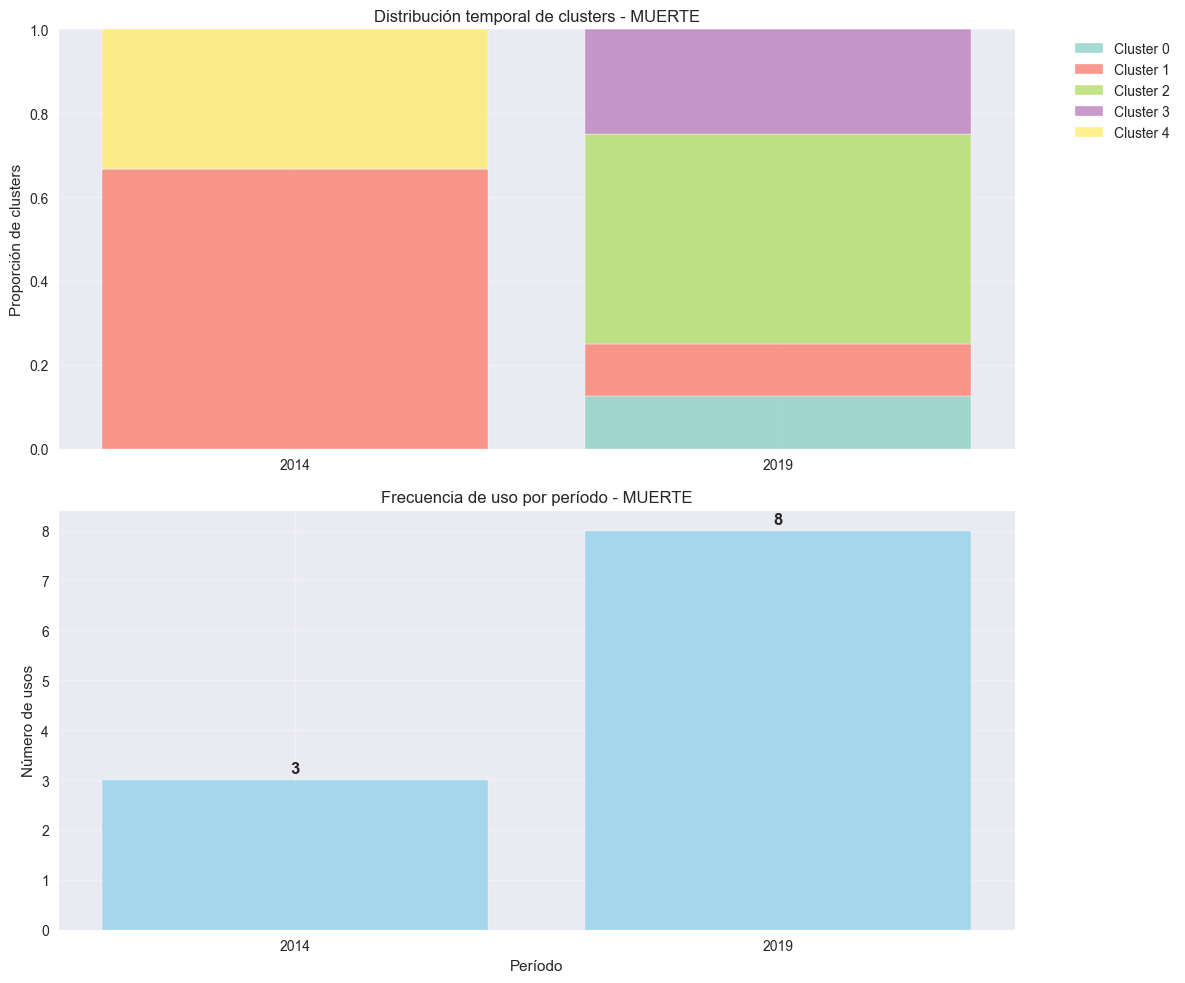

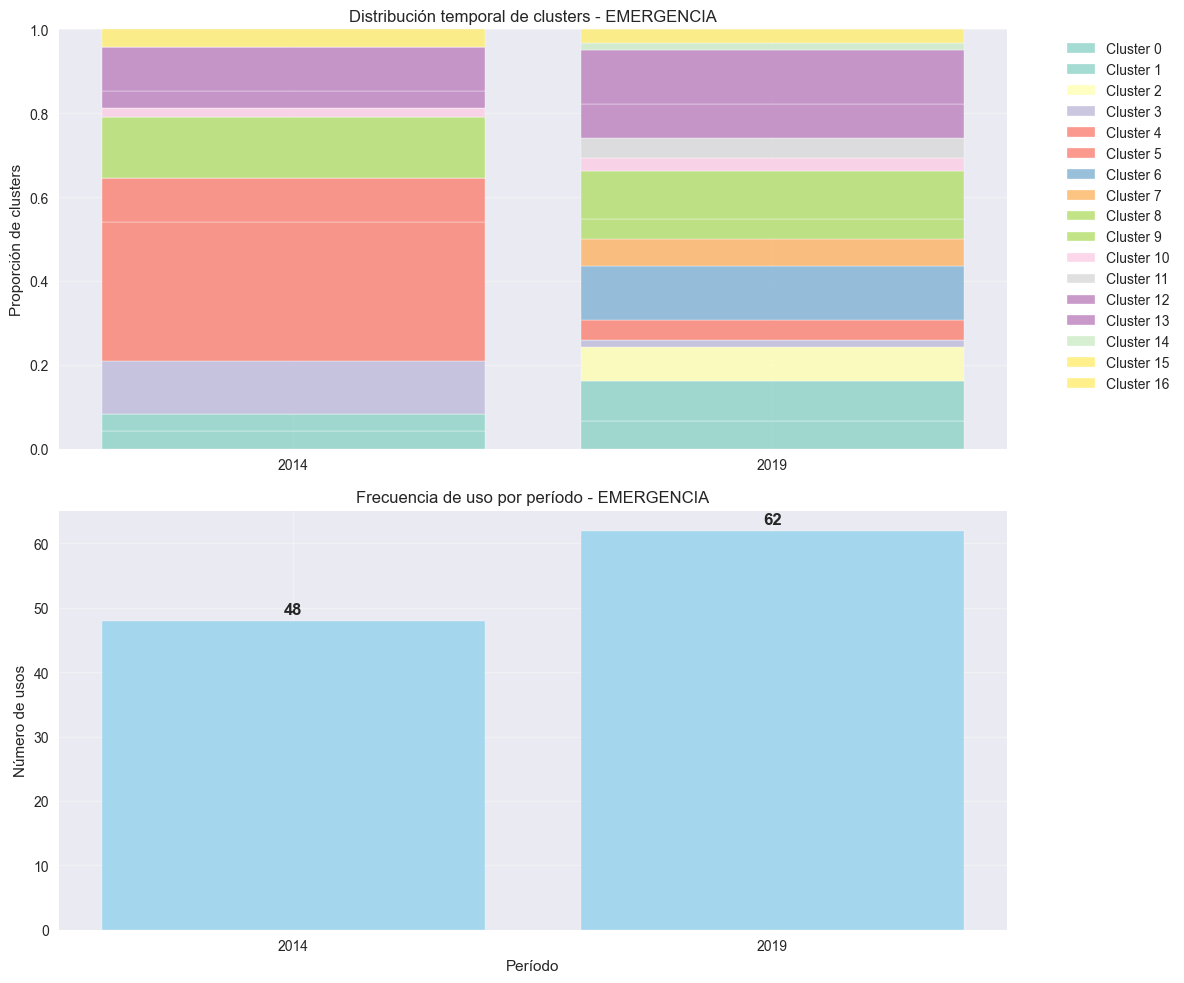

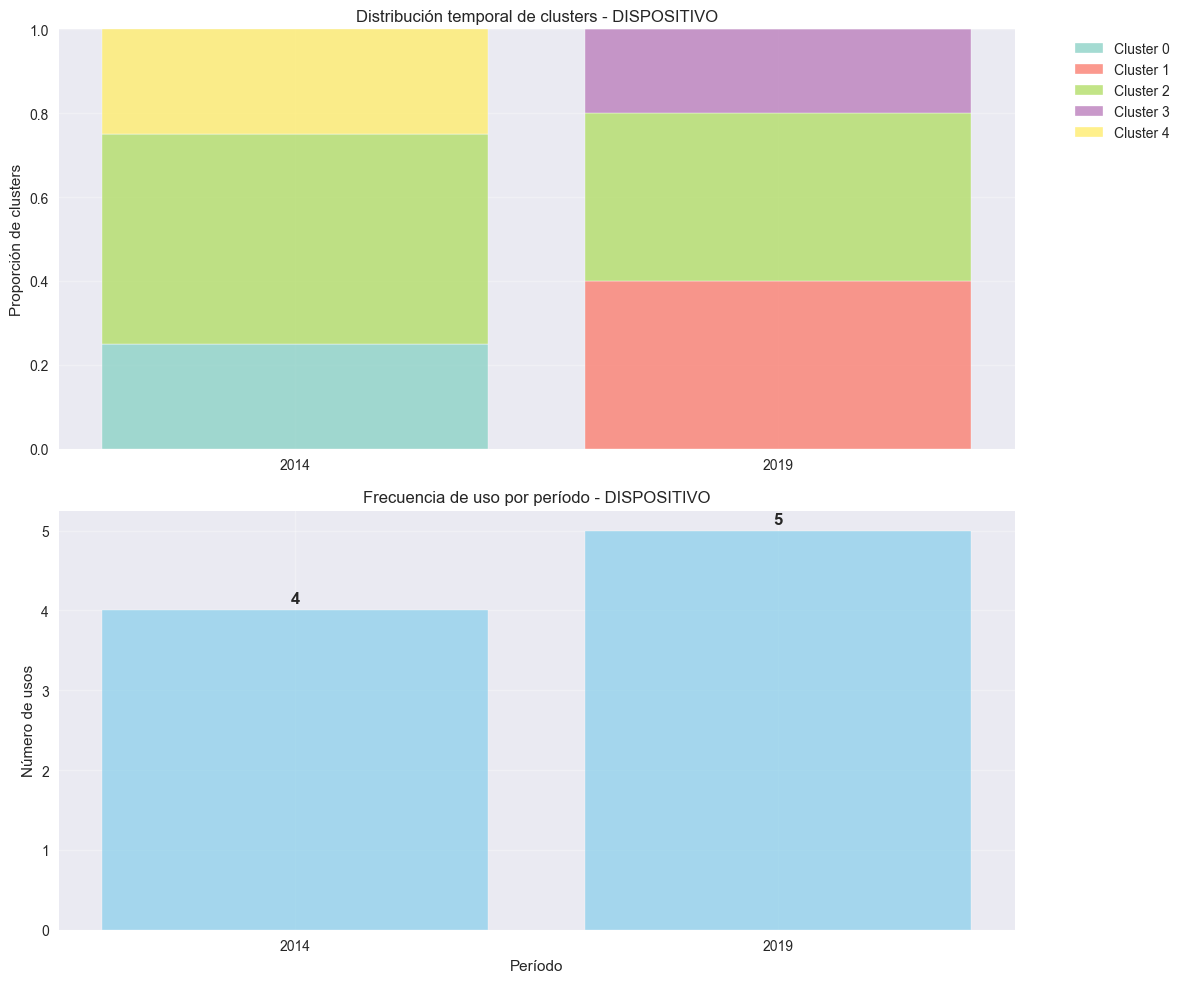

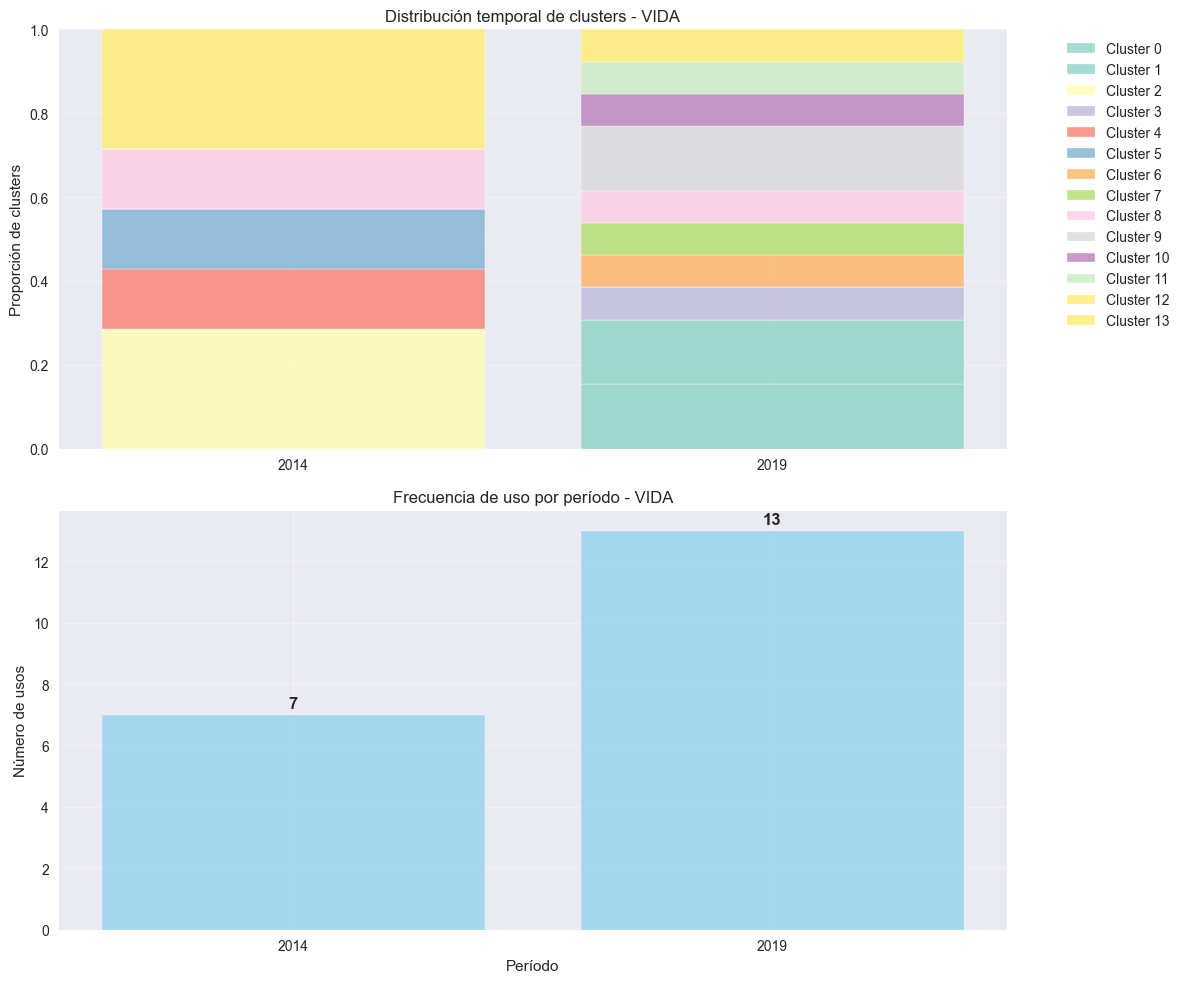

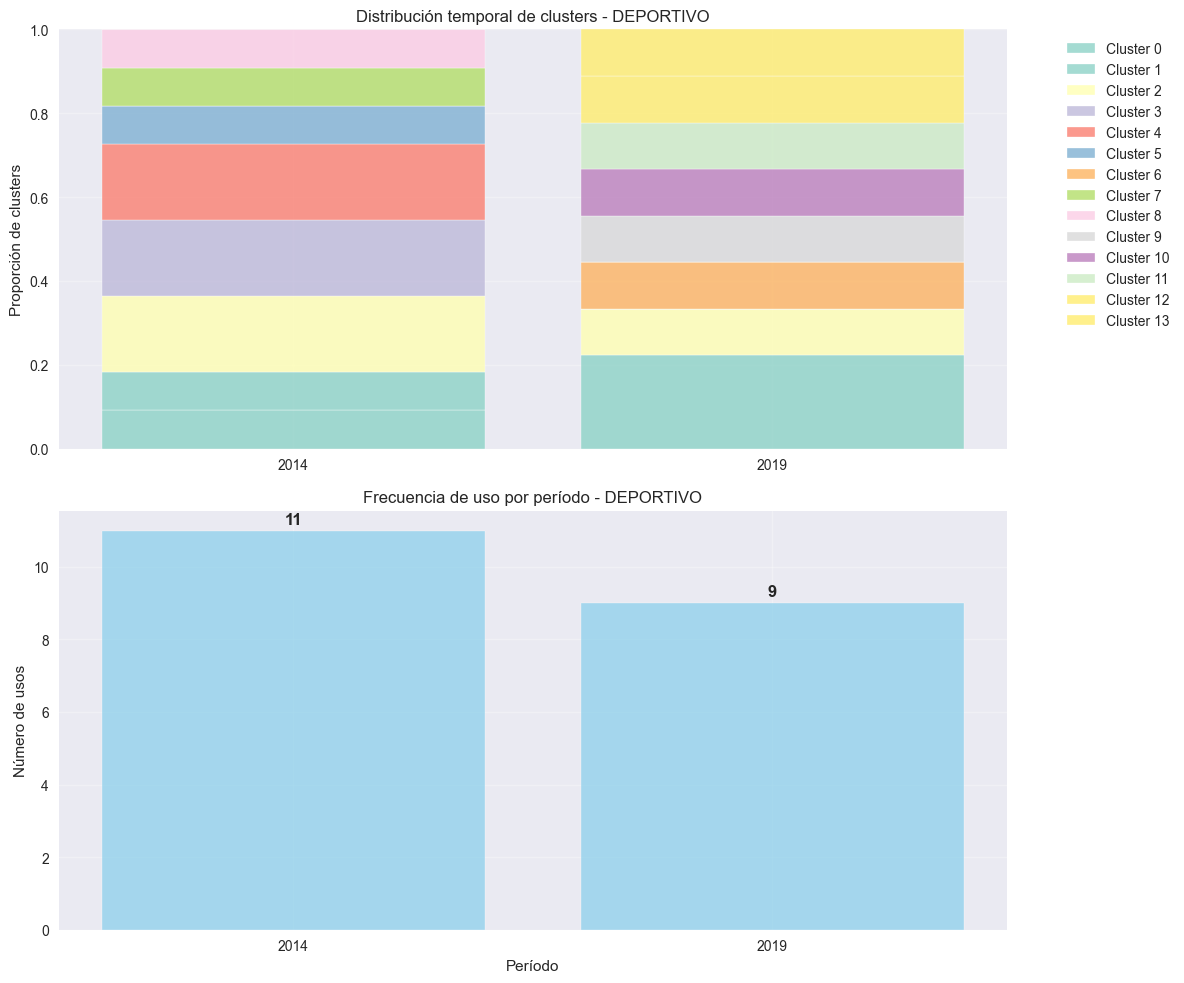

Generando visualizaciones t-SNE...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5600\1240730977.py:149: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_5600\1240730977.py:149: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Generando heatmaps de cambio semántico...
Generando visualizaciones interactivas...

=== RESULTADOS DEL ANÁLISIS DE CAMBIO SEMÁNTICO ===

=== ANÁLISIS CUALITATIVO ===

Análisis para 'muerte':
  Clusters globales: 5 (silhouette: 0.376)
  Período 2014: 3 usos
    Distribución: ['0.00', '0.67', '0.00', '0.00', '0.33']
  Período 2019: 8 usos
    Distribución: ['0.12', '0.12', '0.50', '0.25', '0.00']

Análisis para 'emergencia':
  Clusters globales: 17 (silhouette: 0.268)
  Período 2014: 48 usos
    Distribución: ['0.04', '0.04', '0.00', '0.12', '0.33', '0.10', '0.00', '0.00', '0.15', '0.00', '0.02', '0.00', '0.04', '0.10', '0.00', '0.00', '0.04']
  Período 2019: 62 usos
    Distribución: ['0.06', '0.10', '0.08', '0.02', '0.00', '0.05', '0.13', '0.06', '0.05', '0.11', '0.03', '0.05', '0.08', '0.13', '0.02', '0.03', '0.00']

Análisis para 'dispositivo':
  Clusters globales: 5 (silhouette: 0.232)
  Período 2014: 4 usos
    Distribución: ['0.25', '0.00', '0.50', '0.00', '0.25']
  Período 2019:

,palabra,periodo,JS divergence,APD_cosine,APD_canberra,APD_euclidean,cluster_distribucion_1,cluster_distribucion_2,cantidad_1,cantidad_2
61,vida,2014-2019,0.621999,0.123955,343.438387,127.370827,"[0.2857142857142857, 0.0, 0.14285714285714285, 0.0, 0.14285714285714285, 0.0, 0.14285714285714285, 0.0, 0.0, 0.2857142857142857, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.15384615384615385, 0.07692307692307693, 0.0, 0.0, 0.15384615384615385, 0.0, 0.0, 0.0, 0.0, 0.07692307692307693, 0.15384615384615385, 0.07692307692307693, 0.07692307692307693, 0.07692307692307693, 0.07692307692307693, 0.0, 0.07692307692307693]",7,13
110,vida,2009-2014,0.544289,0.108706,318.172830,116.040992,"[0.0, 0.0, 0.0, 0.3333333333333333, 0.0, 0.0, 0.0, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.16666666666666666, 0.0]","[0.2857142857142857, 0.0, 0.14285714285714285, 0.0, 0.14285714285714285, 0.0, 0.14285714285714285, 0.0, 0.0, 0.2857142857142857, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",6,7
133,muerte,2014-2019,0.520500,0.110688,325.443300,115.812278,"[0.0, 0.6666666666666666, 0.0, 0.0, 0.0, 0.3333333333333333, 0.0, 0.0, 0.0]","[0.0, 0.125, 0.5, 0.0, 0.25, 0.0, 0.0, 0.125, 0.0]",3,8
139,deportivo,2009-2014,0.512468,0.116423,321.985747,122.206951,"[0.0, 0.0, 0.2, 0.2, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.2]","[0.18181818181818182, 0.0, 0.0, 0.09090909090909091, 0.09090909090909091, 0.09090909090909091, 0.18181818181818182, 0.0, 0.18181818181818182, 0.09090909090909091, 0.0, 0.0, 0.09090909090909091, 0.0, 0.0, 0.0]",5,11
155,deportivo,2014-2019,0.501613,0.116715,318.748839,121.464333,"[0.18181818181818182, 0.0, 0.0, 0.09090909090909091, 0.09090909090909091, 0.09090909090909091, 0.18181818181818182, 0.0, 0.18181818181818182, 0.09090909090909091, 0.0, 0.0, 0.09090909090909091, 0.0, 0.0, 0.0]","[0.0, 0.1111111111111111, 0.1111111111111111, 0.0, 0.2222222222222222, 0.0, 0.1111111111111111, 0.1111111111111111, 0.0, 0.0, 0.1111111111111111, 0.1111111111111111, 0.0, 0.0, 0.1111111111111111, 0.0]",11,9
230,muerte,2009-2014,0.424586,0.105645,298.606791,107.593797,"[0.25, 0.25, 0.0, 0.125, 0.0, 0.0, 0.125, 0.125, 0.125]","[0.0, 0.6666666666666666, 0.0, 0.0, 0.0, 0.3333333333333333, 0.0, 0.0, 0.0]",8,3
331,emergencia,2014-2019,0.297942,0.118194,345.352700,123.284577,"[0.020833333333333332, 0.3958333333333333, 0.08333333333333333, 0.020833333333333332, 0.0, 0.0, 0.0625, 0.14583333333333334, 0.020833333333333332, 0.041666666666666664, 0.0, 0.0625, 0.0, 0.0, 0.0625, 0.041666666666666664, 0.0, 0.041666666666666664]","[0.06451612903225806, 0.016129032258064516, 0.06451612903225806, 0.03225806451612903, 0.03225806451612903, 0.0967741935483871, 0.0, 0.04838709677419355, 0.016129032258064516, 0.0, 0.04838709677419355, 0.11290322580645161, 0.03225806451612903, 0.04838709677419355, 0.06451612903225806, 0.1774193548387097, 0.016129032258064516, 0.12903225806451613]",48,62
410,emergencia,2009-2014,0.189952,0.110248,322.168134,114.312313,"[0.0, 0.29508196721311475, 0.01639344262295082, 0.0, 0.18032786885245902, 0.08196721311475409, 0.11475409836065574, 0.04918032786885246, 0.01639344262295082, 0.01639344262295082, 0.03278688524590164, 0.0, 0.0, 0.0, 0.08196721311475409, 0.01639344262295082, 0.03278688524590164, 0.06557377049180328]","[0.020833333333333332, 0.3958333333333333, 0.08333333333333333, 0.020833333333333332, 0.0, 0.0, 0.0625, 0.14583333333333334, 0.020833333333333332, 0.041666666666666664, 0.0, 0.0625, 0.0, 0.0, 0.0625, 0.041666666666666664, 0.0, 0.041666666666666664]",61,48


Generando visualizaciones de distribución temporal...


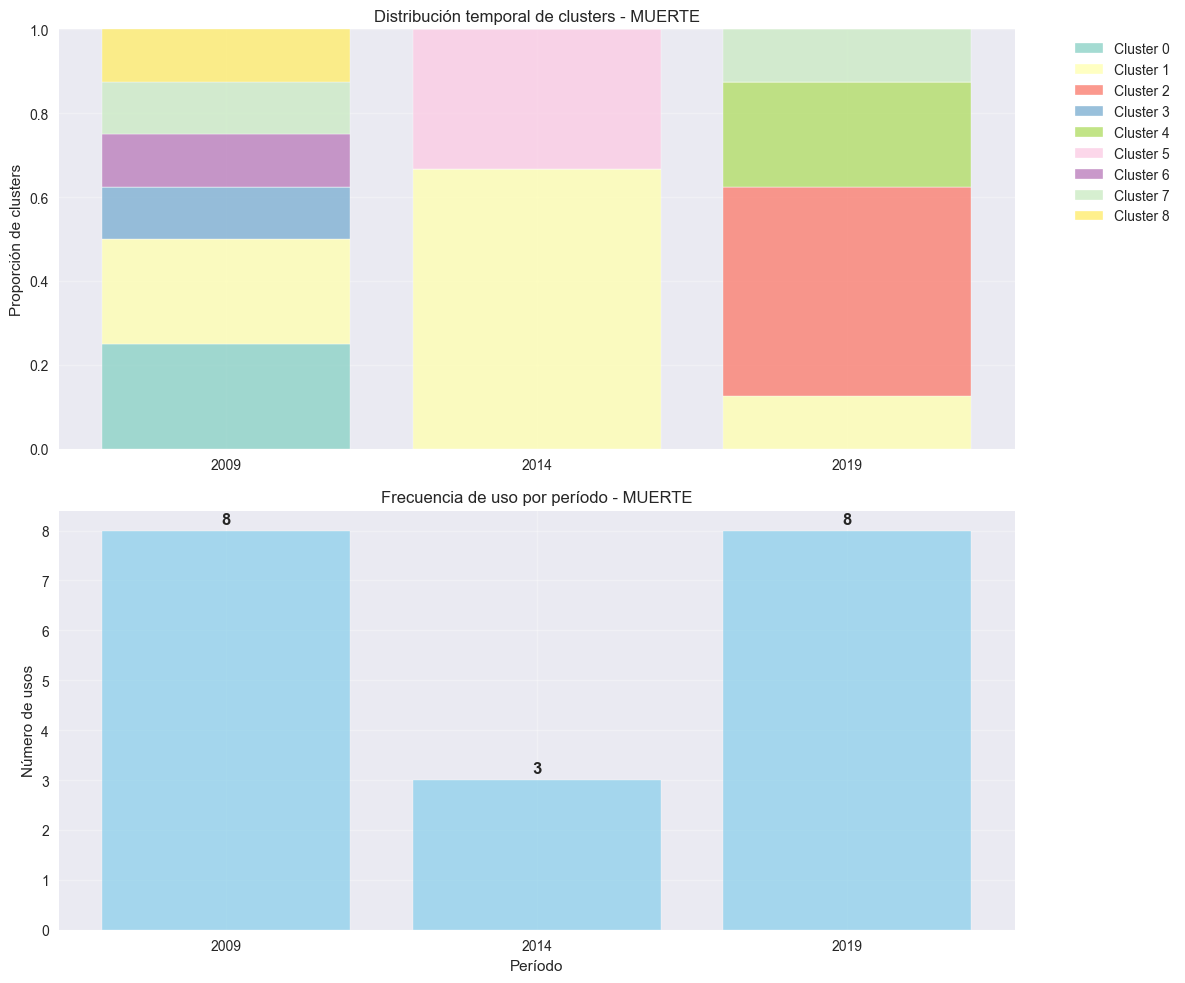

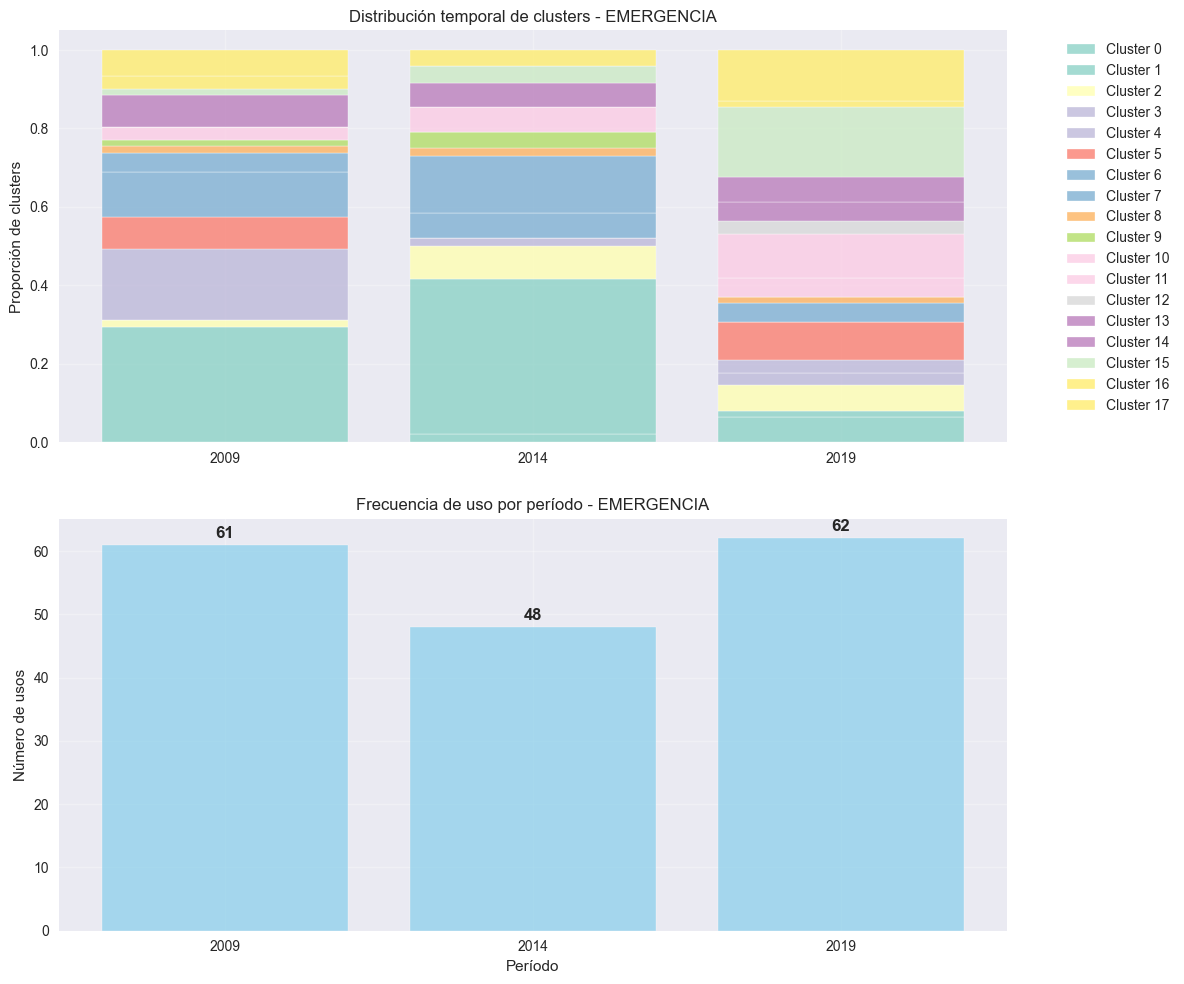

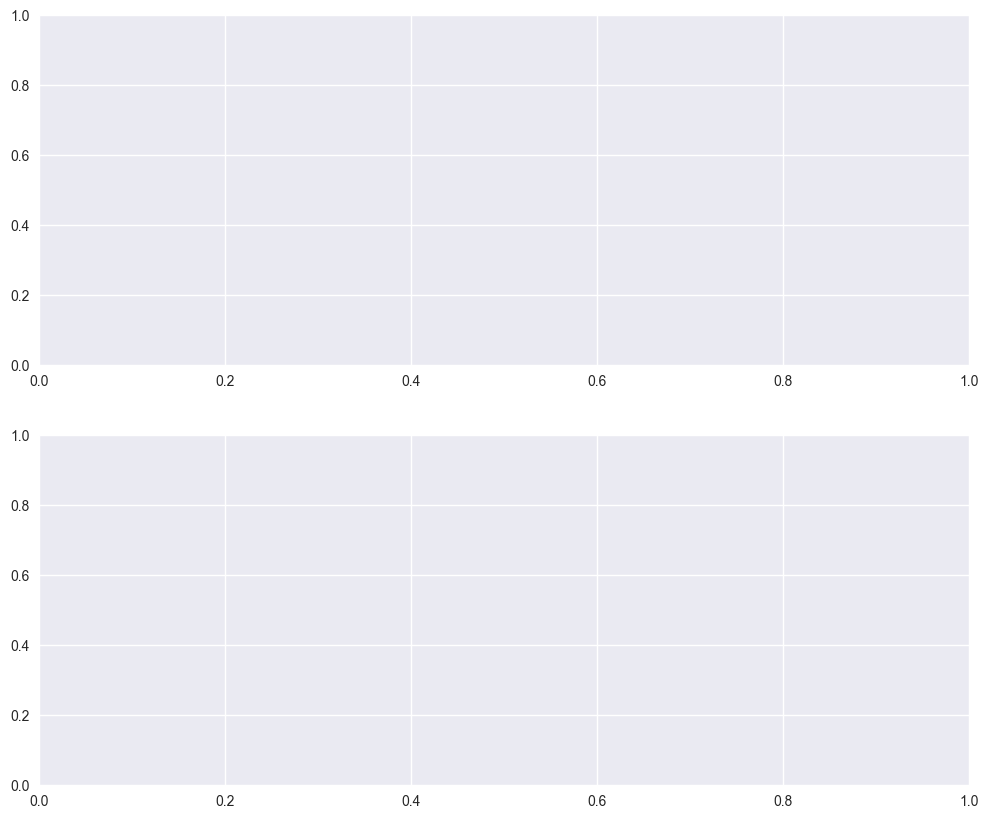

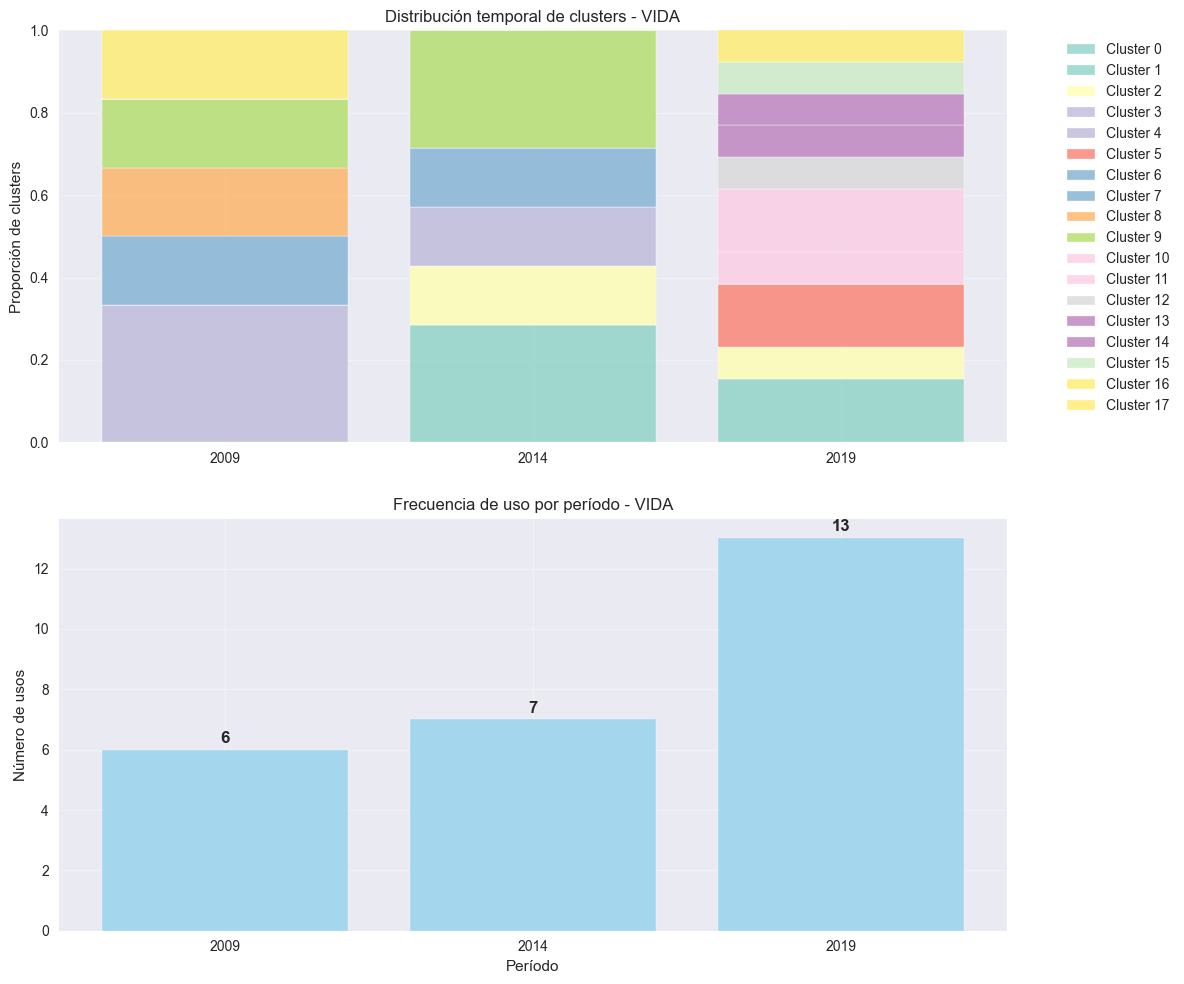

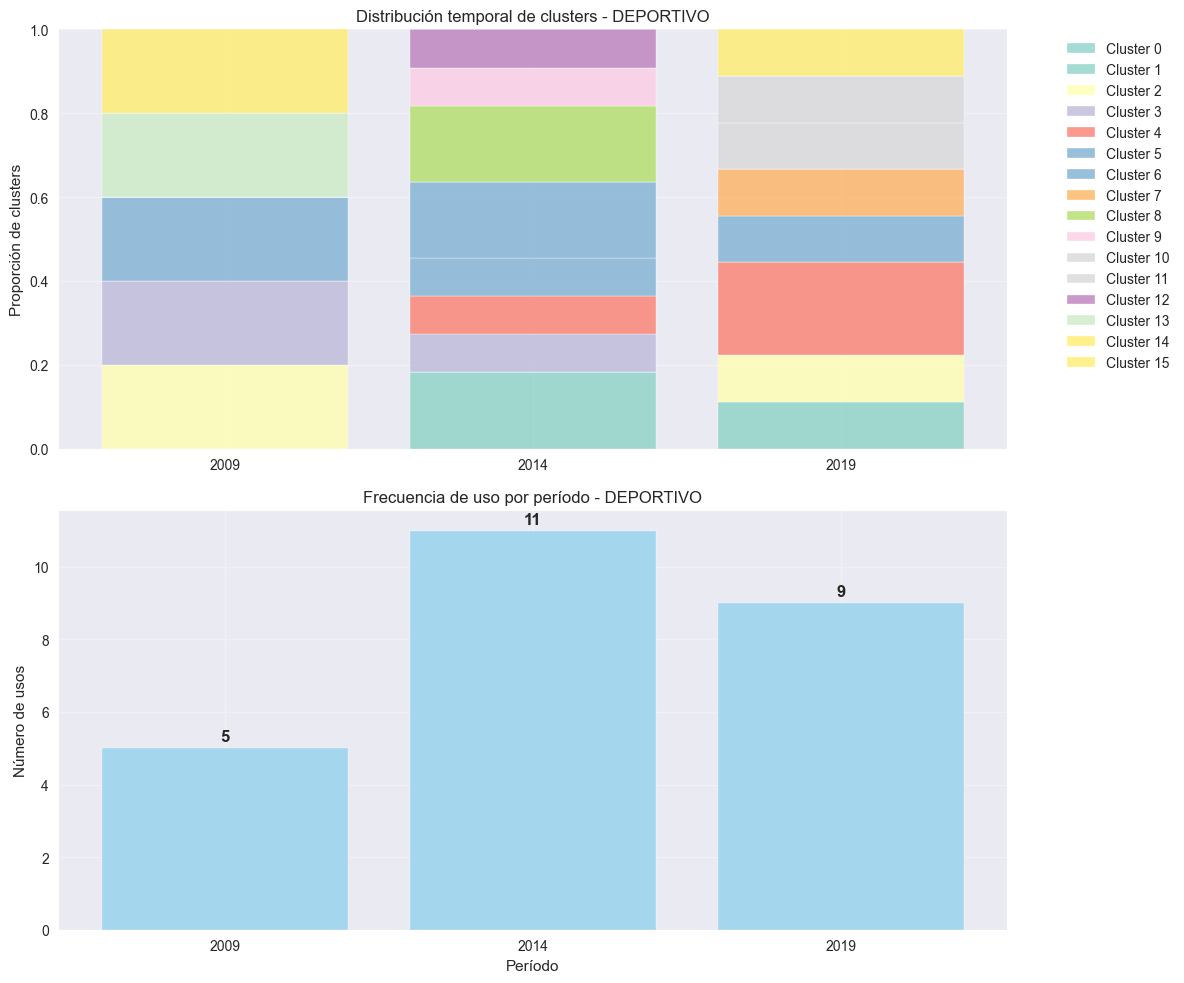

Generando visualizaciones t-SNE...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5600\1240730977.py:149: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_5600\1240730977.py:149: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_5600\1240730977.py:149: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Generando heatmaps de cambio semántico...
Generando visualizaciones interactivas...

=== RESULTADOS DEL ANÁLISIS DE CAMBIO SEMÁNTICO ===

=== ANÁLISIS CUALITATIVO ===

Análisis para 'muerte':
  Clusters globales: 9 (silhouette: 0.431)
  Período 2009: 8 usos
    Distribución: ['0.25', '0.25', '0.00', '0.12', '0.00', '0.00', '0.12', '0.12', '0.12']
  Período 2014: 3 usos
    Distribución: ['0.00', '0.67', '0.00', '0.00', '0.00', '0.33', '0.00', '0.00', '0.00']
  Período 2019: 8 usos
    Distribución: ['0.00', '0.12', '0.50', '0.00', '0.25', '0.00', '0.00', '0.12', '0.00']

Análisis para 'emergencia':
  Clusters globales: 18 (silhouette: 0.292)
  Período 2009: 61 usos
    Distribución: ['0.00', '0.30', '0.02', '0.00', '0.18', '0.08', '0.11', '0.05', '0.02', '0.02', '0.03', '0.00', '0.00', '0.00', '0.08', '0.02', '0.03', '0.07']
  Período 2014: 48 usos
    Distribución: ['0.02', '0.40', '0.08', '0.02', '0.00', '0.00', '0.06', '0.15', '0.02', '0.04', '0.00', '0.06', '0.00', '0.00', '0.06', 

In [116]:
for par_periodo, resultado_ec in enfContexto_resultado.items():
    print(par_periodo)
    metricas_dic = resultado_ec['metricas_dic']
    clustering_resultados = resultado_ec['clustering_resultados']
    per = str(
        par_periodo[0])+'_'+str(par_periodo[1])
    file_nombre = 'EMBEDDINGCONTEX_'+per
    df = pd.read_csv(RESULTADOS_DIR+'/archivos_out/'+file_nombre+'.csv')
    
    if (par_periodo == (2009,2019)):
        periodo_lista = periodosComp_lista
        palabrasEtiqueta_list = list(palabras_comunes_all.intersection(set(ms_palabras)))
    else:
        periodo_lista = [par_periodo[0], par_periodo[1]]
        palabrasEtiqueta_list =  list(set(resultados[par_periodo]['palabras_comunes']).intersection(set(ms_palabras)))

    display(df[df['palabra'].isin(palabrasEtiqueta_list)])
    file_nombre = 'EMBEDDINGCONTEX_MUERTE_SUBITA_'+per
    df[df['palabra'].isin(palabrasEtiqueta_list)].to_csv(RESULTADOS_DIR+'/archivos_out/'+file_nombre+'.csv', index=False)
    
    visualize_clustering_results(clustering_resultados, metricas_dic, palabrasEtiqueta_list, periodo_lista)
    nombre_archivo = '_Clustering_muerteSubita'+str(par_periodo[0])+'_'+str(par_periodo[1])+'.csv'
    analisis_cualitativo_maxPalabra(metricas_dic, clustering_resultados, palabrasEtiqueta_list, periodo_lista,nombre_archivo)


* Para el par período 2009-2014: deportivo con posible cambio semantico. 12 clusters silhouette: 0.450
deportivo(0.60), muerte(0.42), vida (0.22), emergencia (0.09)
* Para el par período 2014-2019: vida con posible cambio semantico, moderados. 13 clusters. silhouette: 0.405
vida (0.62),  muerte(0.52), deportivo(0.43), emergencia (0.30)
* Para todos períodos : deportivo con posible cambio semantico, moderados. 13 clusters. silhouette: 0.461



In [43]:
#enfContexto_resultado[(2014,2019)]['clustering_resultados']['dispositivo']
len(enfContexto_resultado[(2014, 2019)]['matrices_usos']['dispositivo'][2014]) + len(enfContexto_resultado[(2014, 2019)]['matrices_usos']['dispositivo'][2019])


9

In [109]:
df_DSJ2009 = pd.read_csv(RESULTADOS_DIR+"archivos_out/EMBEDDINGCONTEX_2009_2014.csv")
display(df_DSJ2009.describe())
df_DSJ2014 = pd.read_csv(RESULTADOS_DIR+"archivos_out/EMBEDDINGCONTEX_2014_2019.csv")
display(df_DSJ2014.describe())


,JS divergence,APD_cosine,APD_canberra,APD_euclidean,cantidad_1,cantidad_2
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000
mean,0.380695,0.116007,327.495022,117.117154,13.233333,15.644444
std,0.175055,0.030194,43.585640,19.027666,20.056454,24.479706
min,0.001795,0.033402,170.545428,55.704953,1.000000,1.000000
25%,0.256309,0.101487,312.299029,109.740137,4.000000,5.000000
50%,0.378453,0.117013,335.161725,120.089585,7.000000,8.000000
75%,0.504528,0.133317,354.916085,128.623413,14.000000,15.000000
max,0.693147,0.220327,414.110013,168.414257,187.000000,256.000000


,JS divergence,APD_cosine,APD_canberra,APD_euclidean,cantidad_1,cantidad_2
count,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000
mean,0.411919,0.119091,332.123011,119.401700,14.856140,15.814035
std,0.181186,0.029551,46.994651,19.755856,24.041125,29.323184
min,0.000000,0.030991,126.445742,47.650328,1.000000,1.000000
25%,0.274358,0.102546,316.643335,110.539206,5.000000,4.000000
50%,0.422810,0.122590,345.219297,124.235034,8.000000,8.000000
75%,0.539446,0.139402,361.468636,132.355057,15.000000,14.000000
max,0.693147,0.204015,413.618914,162.107700,256.000000,336.000000


In [110]:
df_concat = pd.concat([df_DSJ2009, df_DSJ2014], ignore_index=True)
df_concat.head(3)

,palabra,periodo,JS divergence,APD_cosine,APD_canberra,APD_euclidean,cluster_distribucion_1,cluster_distribucion_2,cantidad_1,cantidad_2
0,virus,2009-2014,0.693147,0.118080,336.759887,125.974595,"[0.1, 0.2, 0.2, 0.0, 0.0, 0.2, 0.0, 0.0, 0.1, 0.1, 0.1]","[0.0, 0.0, 0.0, 0.2, 0.2, 0.0, 0.4, 0.2, 0.0, 0.0, 0.0]",10,5
1,recurso,2009-2014,0.693147,0.120307,354.586469,125.645982,"[0.2857142857142857, 0.14285714285714285, 0.2857142857142857, 0.0, 0.2857142857142857]","[0.0, 0.0, 0.0, 1.0, 0.0]",7,2
2,publica,2009-2014,0.693147,0.187057,381.439220,158.141677,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.18181818181818182, 0.09090909090909091, 0.0, 0.18181818181818182, 0.18181818181818182, 0.09090909090909091, 0.18181818181818182, 0.09090909090909091]",1,11


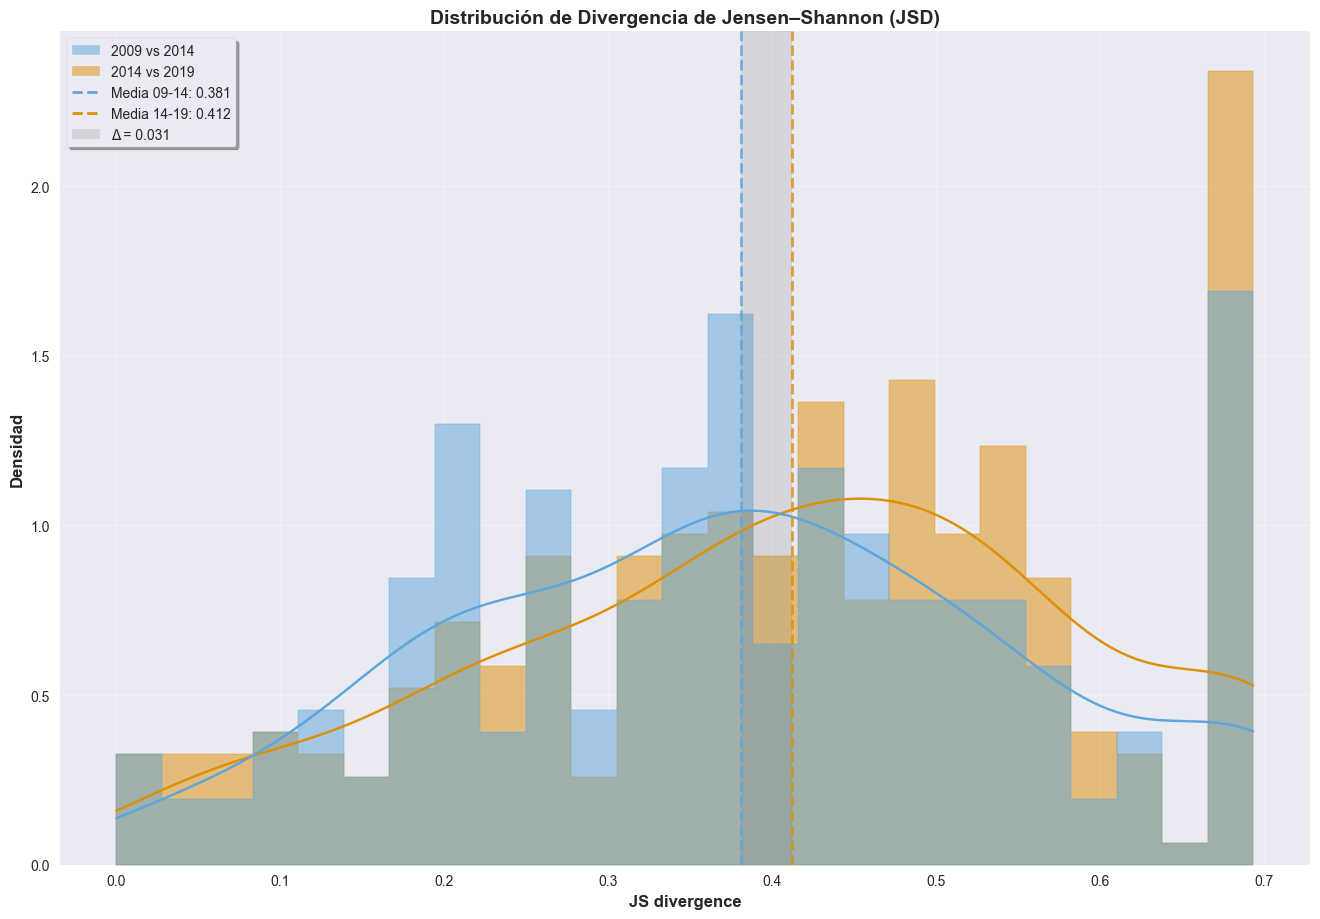

In [112]:
# Leyenda unificada y clara
import seaborn as sns
from matplotlib.patches import Patch

# Paleta optimizada para similitud score
PALETA_score = {
    '2009-2014': '#5DA5DA',  # Azul - tu color de proyectos de salud
    '2014-2019': '#DE8F05'   # Naranja - tu color de tokens
}


plt.figure(figsize=(14, 10))
# Gráfico principal
sns.histplot(data=df_concat, x='JS divergence', hue='periodo', 
             palette=PALETA_score,
             alpha=0.5, 
             bins=25,
             kde=True,
             element='step',
             stat='density')

plt.xlabel('JS divergence', fontsize=12, fontweight='bold')
plt.ylabel('Densidad', fontsize=12, fontweight='bold')
plt.title('Distribución de Divergencia de Jensen–Shannon (JSD)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Calcular medias
media_2009_2014 = df_DSJ2009['JS divergence'].mean()
media_2014_2019 = df_DSJ2014['JS divergence'].mean()
diferencia_medias = abs(media_2009_2014 - media_2014_2019)

# Elementos visuales clave
plt.axvline(media_2009_2014, color=PALETA_score['2009-2014'], linestyle='--', linewidth=2, alpha=0.8)
plt.axvline(media_2014_2019, color=PALETA_score['2014-2019'], linestyle='--', linewidth=2, alpha=0.8)
plt.axvspan(min(media_2009_2014, media_2014_2019), max(media_2009_2014, media_2014_2019), 
            alpha=0.2, color='gray')


legend_elements = [
    Patch(facecolor=PALETA_score['2009-2014'], alpha=0.5, label='2009 vs 2014'),
    Patch(facecolor=PALETA_score['2014-2019'], alpha=0.5, label='2014 vs 2019'),
    plt.Line2D([0], [0], color=PALETA_score['2009-2014'], linestyle='--', linewidth=2, 
               label=f'Media 09-14: {media_2009_2014:.3f}'),
    plt.Line2D([0], [0], color=PALETA_score['2014-2019'], linestyle='--', linewidth=2, 
               label=f'Media 14-19: {media_2014_2019:.3f}'),
    Patch(facecolor='gray', alpha=0.2, label=f'Δ = {diferencia_medias:.3f}')
]

plt.legend(handles=legend_elements, loc='best', title='', frameon=True, shadow=True)

plt.tight_layout(pad=3)
plt.savefig(BASE_DIR+'imagenes/Hist_JSD.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [113]:
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools
from scipy.spatial.distance import cosine
from scipy import stats

score_2009_2014 = df_concat[df_concat['periodo']=='2009-2014']['JS divergence']
score_2014_2019 = df_concat[df_concat['periodo']=='2014-2019']['JS divergence']
# Test estadístico para diferencia de distribuciones
t_stat, p_value = stats.ttest_ind(score_2009_2014, score_2014_2019)

print("ANÁLISIS ESTADÍSTICO DE JS divergence")
print(f"2009 vs 2014: Media = {score_2009_2014.mean():.3f} ± {score_2009_2014.std():.3f}")
print(f"2014 vs 2019: Media = {score_2014_2019.mean():.3f} ± {score_2014_2019.std():.3f}")
print(f"Diferencia: {score_2009_2014.mean() - score_2014_2019.mean():.3f}")
print(f"Test t: t = {t_stat:.3f}, p-value = {p_value:.3f}")
print(f"Significativo (p < 0.05): {'SÍ' if p_value < 0.05 else 'NO'}")

ANÁLISIS ESTADÍSTICO DE JS divergence
2009 vs 2014: Media = 0.381 ± 0.175
2014 vs 2019: Media = 0.412 ± 0.181
Diferencia: -0.031
Test t: t = -2.063, p-value = 0.040
Significativo (p < 0.05): SÍ


Se observa que el lenguaje legislativo cambió más entre 2009 y 2014 que entre 2014 y 2019. Diferencia altamente significativa, el patrón de cambio semántico no es atribuible al azar.

In [108]:
with open(RESULTADOS_DIR+"archivos_out/enfoqueContextual_resultados.pkl", 'rb') as file: 
    enfContexto_resultado = pickle.load(file)
    

In [114]:
# Función mejorada que integra con tu análisis existente
def analisis_resultados_completo2(change_metrics, clustering_results, decades):
    """
    Función completa que realiza el análisis y guarda el CSV solicitado
    """
    print("\n=== RESULTADOS DEL ANÁLISIS DE CAMBIO SEMÁNTICO ===")
    
    # Identificar palabras con mayor cambio (tu código original)
    max_change_words = []
    for word, metrics in change_metrics.items():
        period_changes = []
        for period_pair, values in metrics.items():
            period_changes.append(values['JS divergence'])
        
        if period_changes:
            avg_jsd = np.mean(period_changes)
            max_change_words.append((word, avg_jsd))
    
    # Ordenar por cambio semántico (JSD)
    max_change_words.sort(key=lambda x: x[1], reverse=True)
    
    print("\nPalabras con mayor cambio semántico (JSD promedio entre períodos):")
    registro_calidad = {}
    for word, avg_jsd in max_change_words:  # Mostrar top 10
        registro_calidad[word] = {}
        registro_calidad[word]['JSD'] 
        
        print(f"{word}: JSD promedio = {avg_jsd:.3f}")
        print(f"\nAnálisis para '{word}':")
        print(f" Clusters globales: {clustering_results[word]['global']['k']} "
              f"(silhouette: {clustering_results[word]['global']['silhouette_score']:.3f})")
        
        # Mostrar distribución por período
        for decade in decades:
            if decade in clustering_results[word]:
                dist = clustering_results[word][decade]['distribucion']
                print(f"  Período {decade}: {clustering_results[word][decade]['ocurrencia']} usos")
                print(f"    Distribución: {[f'{p:.2f}' for p in dist]}")
    
    # Guardar el CSV con la estructura solicitada
    print("\n=== GUARDANDO DATAFRAME A CSV ===")
    df = guardar_clusters_por_periodo(change_metrics, clustering_results, decades)
    
    return df, max_change_words



def flatten_record2(word, data):
    record = {"palabra": word}

    # Extraer periodo principal (asumo un único periodo por ahora)
    periodo, valores = [(k, v) for k, v in data.items() if isinstance(v, dict)][0]

    record["periodo"] = periodo
    record["JS_divergence"] = valores.get("JS divergence", None)
    record["APD_cosine"] = valores.get("APD", {}).get("cosine", None)
    record["APD_canberra"] = valores.get("APD", {}).get("canberra", None)
    record["APD_euclidean"] = valores.get("APD", {}).get("euclidean", None)
    record["cluster_distribucion_1"] = valores.get("cluster_distribucion_1", None)
    record["cluster_distribucion_2"] = valores.get("cluster_distribucion_2", None)
    record["cantidad_1"] = valores.get("cantidad_1", None)
    record["cantidad_2"] = valores.get("cantidad_2", None)
    # Nivel superior
    record["silhouette_score"] = data.get("silhouette_score", None)

    return record


In [119]:
registro = []
for par_periodo, resultado_ec in enfContexto_resultado.items():
    print('####################')
    print(par_periodo)
    if par_periodo != (2009, 2019):
        metricas_dic = resultado_ec['metricas_dic']
        clustering_resultados = resultado_ec['clustering_resultados']
        for word, metrics in metricas_dic.items():
            #print(word)
            metrics['silhouette_score']= clustering_resultados[word]['global']['silhouette_score']
            #print(flatten_record2(word, metrics))
            registro.append(flatten_record2(word, metrics))
df = pd.DataFrame(registro)
df.to_csv(RESULTADOS_DIR+"archivos_out/EMBEDDINGCONTEX_ALL.csv")
   

    

####################
(2009, 2014)
####################
(2014, 2019)
####################
(2009, 2019)


In [121]:
df[df['palabra']=='virus']

,palabra,periodo,JS_divergence,APD_cosine,APD_canberra,APD_euclidean,cluster_distribucion_1,cluster_distribucion_2,cantidad_1,cantidad_2,silhouette_score
242,virus,2009-2014,0.693147,0.118080,336.759887,125.974595,"[0.1, 0.2, 0.2, 0.0, 0.0, 0.2, 0.0, 0.0, 0.1, 0.1, 0.1]","[0.0, 0.0, 0.0, 0.2, 0.2, 0.0, 0.4, 0.2, 0.0, 0.0, 0.0]",10,5,0.319347
340,virus,2014-2019,0.512468,0.101787,309.025392,113.021958,"[0.0, 0.4, 0.0, 0.0, 0.2, 0.2, 0.2, 0.0, 0.0]","[0.18181818181818182, 0.18181818181818182, 0.09090909090909091, 0.18181818181818182, 0.0, 0.0, 0.0, 0.18181818181818182, 0.18181818181818182]",5,11,0.473685


#### Control de distribución

In [122]:
df.describe(include='all')

,palabra,periodo,JS_divergence,APD_cosine,APD_canberra,APD_euclidean,cluster_distribucion_1,cluster_distribucion_2,cantidad_1,cantidad_2,silhouette_score
count,555,555,555.000000,555.000000,555.000000,555.000000,555,555,555.000000,555.000000,555.000000
unique,319,2,NaN,NaN,NaN,NaN,555,555,NaN,NaN,NaN
top,ochenta,2014-2019,NaN,NaN,NaN,NaN,"[0.875, 0.125]","[1.0, 0.0]",NaN,NaN,NaN
freq,2,285,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN
mean,NaN,NaN,0.396729,0.117591,329.871557,118.290300,NaN,NaN,14.066667,15.731532,0.448512
std,NaN,NaN,0.178753,0.029878,45.386513,19.421186,NaN,NaN,22.187197,27.051262,0.178527
min,NaN,NaN,0.000000,0.030991,126.445742,47.650328,NaN,NaN,1.000000,1.000000,0.081604
25%,NaN,NaN,0.264038,0.102011,314.452221,109.932495,NaN,NaN,5.000000,5.000000,0.321510
50%,NaN,NaN,0.400243,0.119712,340.983730,121.879492,NaN,NaN,7.000000,8.000000,0.429582
75%,NaN,NaN,0.523987,0.136116,358.111389,130.601085,NaN,NaN,14.000000,15.000000,0.559947


In [123]:
df[(df['palabra'].isin(['virus','recurso','publica','marzo','correspondiente','comunitario','respuesta','ganancia','trasplante','consejo'])) & (df['periodo']=='2009-2014')][['palabra','periodo','JS_divergence','silhouette_score','cantidad_1','cantidad_2']]

,palabra,periodo,JS_divergence,silhouette_score,cantidad_1,cantidad_2
135,marzo,2009-2014,0.693147,0.444444,3,6
140,correspondiente,2009-2014,0.693147,0.456290,5,2
149,consejo,2009-2014,0.693147,0.444444,5,4
153,trasplante,2009-2014,0.693147,0.750000,7,1
171,respuesta,2009-2014,0.693147,0.148970,1,5
194,comunitario,2009-2014,0.693147,0.444444,6,3
222,recurso,2009-2014,0.693147,0.496618,7,2
242,virus,2009-2014,0.693147,0.319347,10,5
255,ganancia,2009-2014,0.693147,0.160863,4,1
260,publica,2009-2014,0.693147,0.434837,1,11


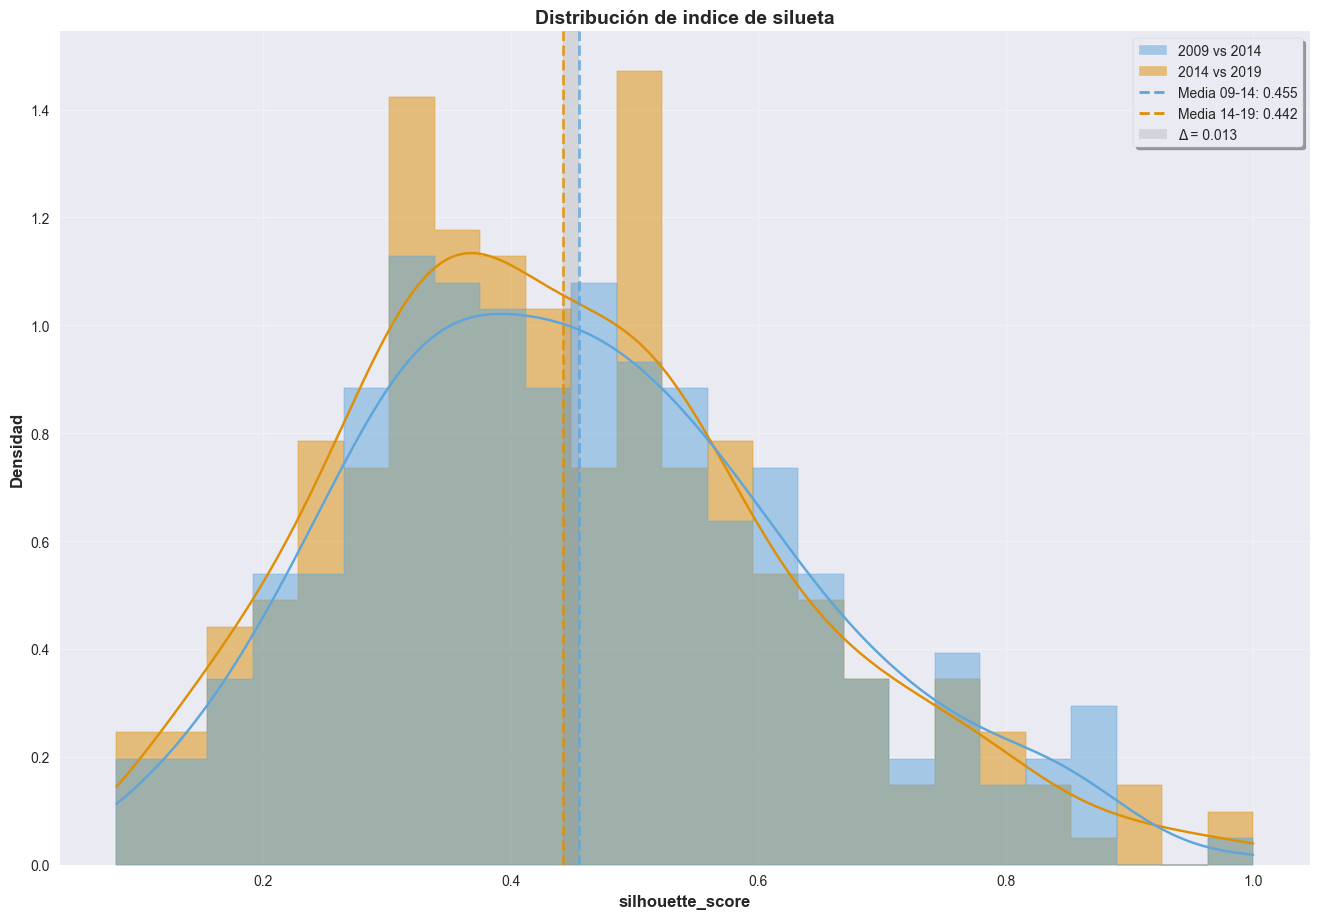

In [126]:
# Leyenda unificada y clara
import seaborn as sns
from matplotlib.patches import Patch

# Paleta optimizada para similitud score
PALETA_score = {
    '2009-2014': '#5DA5DA',  # Azul - tu color de proyectos de salud
    '2014-2019': '#DE8F05'   # Naranja - tu color de tokens
}


plt.figure(figsize=(14, 10))
# Gráfico principal
sns.histplot(data=df, x='silhouette_score', hue='periodo', 
             palette=PALETA_score,
             alpha=0.5, 
             bins=25,
             kde=True,
             element='step',
             stat='density')

plt.xlabel('silhouette_score', fontsize=12, fontweight='bold')
plt.ylabel('Densidad', fontsize=12, fontweight='bold')
plt.title('Distribución de indice de silueta', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Calcular medias
media_2009_2014 = df[df['periodo']=='2009-2014']['silhouette_score'].mean()
media_2014_2019 = df[df['periodo']=='2014-2019']['silhouette_score'].mean()
diferencia_medias = abs(media_2009_2014 - media_2014_2019)

# Elementos visuales clave
plt.axvline(media_2009_2014, color=PALETA_score['2009-2014'], linestyle='--', linewidth=2, alpha=0.8)
plt.axvline(media_2014_2019, color=PALETA_score['2014-2019'], linestyle='--', linewidth=2, alpha=0.8)
plt.axvspan(min(media_2009_2014, media_2014_2019), max(media_2009_2014, media_2014_2019), 
            alpha=0.2, color='gray')


legend_elements = [
    Patch(facecolor=PALETA_score['2009-2014'], alpha=0.5, label='2009 vs 2014'),
    Patch(facecolor=PALETA_score['2014-2019'], alpha=0.5, label='2014 vs 2019'),
    plt.Line2D([0], [0], color=PALETA_score['2009-2014'], linestyle='--', linewidth=2, 
               label=f'Media 09-14: {media_2009_2014:.3f}'),
    plt.Line2D([0], [0], color=PALETA_score['2014-2019'], linestyle='--', linewidth=2, 
               label=f'Media 14-19: {media_2014_2019:.3f}'),
    Patch(facecolor='gray', alpha=0.2, label=f'Δ = {diferencia_medias:.3f}')
]

plt.legend(handles=legend_elements, loc='best', title='', frameon=True, shadow=True)

plt.tight_layout(pad=3)
plt.savefig(BASE_DIR+'imagenes/Hist_silueta.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_5600\2007502923.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




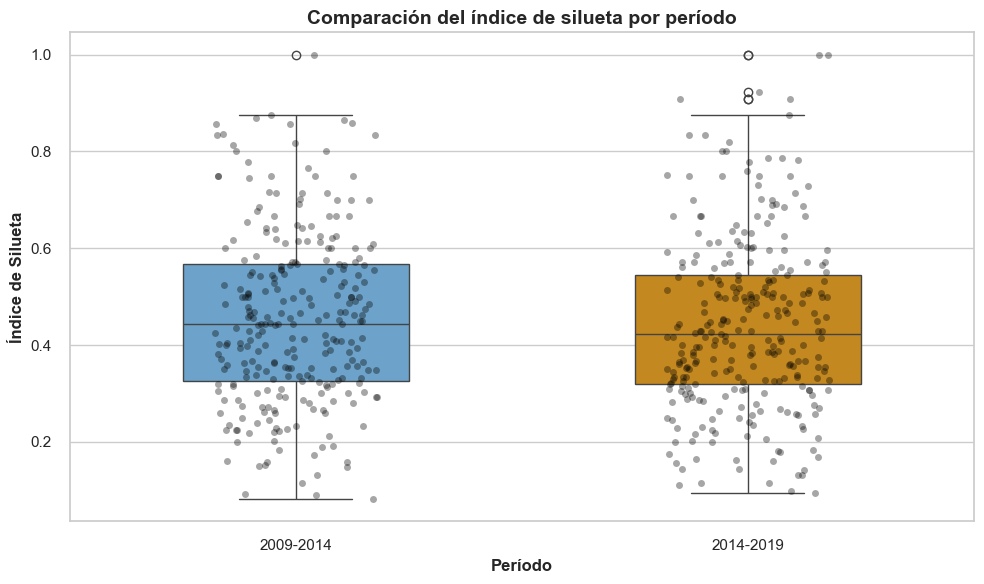

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="periodo",
    y="silhouette_score",
    palette=PALETA_score,
    width=0.5,
    showfliers=True  # Si querés ocultar outliers → False
)

sns.stripplot(
    data=df,
    x="periodo",
    y="silhouette_score",
    color='black',
    alpha=0.35,
    jitter=0.18
)

plt.title("Comparación del índice de silueta por período", fontsize=14, fontweight='bold')
plt.xlabel("Período", fontsize=12, fontweight='bold')
plt.ylabel("Índice de Silueta", fontsize=12, fontweight='bold')
plt.tight_layout()

plt.savefig(BASE_DIR + "imagenes/Boxplot_silueta.png",
            dpi=300, bbox_inches="tight", facecolor='white')

plt.show()


In [74]:
df.groupby('periodo')['silhouette_score'].mean()

periodo
2009-2014    0.453300
2014-2019    0.442279
Name: silhouette_score, dtype: float64